In [1]:
library(data.table)
library(tidyverse)
library(parallel)
library(patchwork)
library(pheatmap)
library(ggplot2)
library(ggridges)
library(ape)
library(ggtree)
library(geiger)
library(taxize)

# library(asreml)
# library(asremlPlus)
library(qqman)
library(topGO)
library(dplyr)
library(PRROC)

── Attaching core tidyverse packages ───────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ─────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()     masks data.table::between()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks data.table::first()
✖ lubridate::hour()    masks data.table::hour()
✖ lubridate::isoweek() masks data.table::isoweek()
✖ dplyr::lag()         masks stats::lag()
✖ dplyr::last()        masks data.table::last()
✖ lubridate::mday()    masks data.table::mday()
✖ lubridate::minute()  masks data.table::minute()
✖ lubridate::month()   masks data.table::month()
✖ lubridate::quarter() masks data.table::quarter()
✖ lubridate::second()  masks data.table::second()
✖ purrr::transpose()   masks da

#
Rscript src/12_runPermulation_perOGModel.R /workdir/sh2246/p_phyloGWAS/output/envData_707Poaceae_20250804.txt /workdir/sh2246/p_phyloGWAS/output/masterDataTable_PAVFill_20250901.txt /workdir/sh2246/p_phyloGWAS/output/phyloK_728Poaceae_astral_20250407.txt /workdir/sh2246/p_phyloGWAS/output/PoaceaeTree_angiosperm353_astral_filtered_20250407.nwk envPC_1 /workdir/sh2246/p_phyloGWAS/output/finalModels TRUE > log/perOGModeling_envPC1.log 2>&1



In [348]:
detach("package:asreml")
detach("package:asremlPlus")

ERROR: Error in detach("package:asreml"): invalid 'name' argument


In [2]:
library(asreml)
library(asremlPlus)

Loading required package: Matrix


Attaching package: ‘Matrix’


The following object is masked from ‘package:S4Vectors’:

    expand


The following object is masked from ‘package:ggtree’:

    expand


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack




Online License checked out Fri Sep 12 11:46:49 2025


Loading ASReml-R version 4.2




In [ ]:
# install.packages("~/asreml_4.2.0.355_R_x86_64-pc-linux-gnu.tar.gz",repos = NULL)

In [ ]:
# ?asreml.license.activate()

In [ ]:
# library(asreml)
# asreml.license.activate(acode = "GHFF-ABBA-EDFE-FCGC")
# asreml.license.status(quiet = FALSE, task = "checkout", json = "")


In [211]:
fit_model_v2 <- function(OG_id, data, Kmat,envDf,metadata,responseVar) {
#   library(asreml)
    gc()
    asreml.options(verbose = FALSE)
    filtered_data <- subset(data, OG == OG_id)
    filtered_data <- filtered_data[,c("assemblyID",responseVar,"scaled.dn.ds","scaledESM", "scaledPlantCAD", "PMS",
                                      "compdup", "queryCov","pacbio")]
    missingTaxa <- setdiff(envDf$assemblyID, filtered_data$assemblyID)
    dfToAdd <- data.frame(assemblyID = missingTaxa,responseVar = envDf[missingTaxa,responseVar],
                          scaled.dn.ds = mean(filtered_data$scaled.dn.ds),
                          scaledScore = mean(filtered_data$scaledESM),
                          scaledScore_DNA = mean(filtered_data$scaledPlantCAD), PMS = 0,
                          compdup = metadata[missingTaxa,]$compdup,queryCov = mean(filtered_data$queryCov),
                          pacbio = metadata[missingTaxa,]$pacbio, PAV = 0)
    dfToAdd = na.omit(dfToAdd)
    filtered_data$PAV = 1
    colnames(dfToAdd) = colnames(filtered_data)
    filtered_data <- rbind(filtered_data,dfToAdd)
    filtered_data$PAV = as.factor(filtered_data$PAV)
    filtered_data$PMS = as.factor(filtered_data$PMS)
    filtered_data$pacbio = as.factor(filtered_data$pacbio)
    tmp = filtered_data
    fullFM = as.formula(paste0(responseVar, "~ PAV + PAV:scaled.dn.ds + PAV:scaledESM + PAV:scaledPlantCAD + PAV:PMS + compdup + PAV:queryCov + pacbio"))
    reducedFM = as.formula(paste0(responseVar, "~ compdup + queryCov + pacbio"))

    model_full <- asreml(fixed = fullFM,
                         random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)
    model_reduced1 <- asreml(fixed = fullFM,
                             ai.sing = F, data = filtered_data)
    filtered_data <- tmp
    model_reduced2 <- asreml(fixed = reducedFM,
                             random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)  
    
    totalVar = var(filtered_data[,responseVar])
    modelSummary <- summary(model_full)
    IC_full = infoCriteria(model_full,IClikelihood = "full")
    IC_reduced = infoCriteria(model_reduced2,IClikelihood = "full")
    logLik_full <- IC_full$loglik
    logLik_reduced <- IC_reduced$loglik
    BIC_full <- IC_full$BIC
    BIC_reduced <- IC_reduced$BIC

    LRT_statistic <- -2 * (logLik_reduced - logLik_full)
    p_value <- pchisq(LRT_statistic, df = 5, lower.tail = FALSE)
    gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
    phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar
  
    modelWald <- wald.asreml(model_full)
    partialCoeff <- model_full$coefficients$fixed[c(3,8,10,12,16)]
    partialPval <- modelWald[c(2,5:8),4]

#     return(model_full)
    out = c(OG_id,BIC_full,BIC_reduced,LRT_statistic,p_value,gene_explained,phylo_explained,totalVar,partialCoeff,partialPval)
    names(out) = c("OG","BIC_full","BIC_reduced","LR","p","geneVAE","phyloVAE","totalVar",
                   paste("partialCoeff",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"),
                   paste("partialP",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"))
    if(model_full$converge) return(out)
    else return(NULL)
}

In [4]:
fit_model_v3 <- function(OG_id, data, Kmat,responseVar) {
#   library(asreml)
    gc()
    asreml.options(verbose = FALSE)
    filtered_data <- subset(data, OG == OG_id)
    filtered_data <- filtered_data[,c("assemblyID",responseVar,"PAV","scaled.dn.ds","scaledESM", "scaledPlantCAD", "PMS",
                                      "compdup", "queryCov","pacbio")]
    tmp = filtered_data
    if (length(unique(filtered_data$PAV))==2){
        fullFM = as.formula(paste0(responseVar, "~ PAV + PAV:scaled.dn.ds + PAV:scaledESM + PAV:scaledPlantCAD + PAV:PMS + compdup + PAV:queryCov + pacbio"))
        reducedFM = as.formula(paste0(responseVar, "~ compdup + queryCov + pacbio"))

        model_full <- asreml(fixed = fullFM,
                             random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)
        model_reduced1 <- asreml(fixed = fullFM,
                                 ai.sing = F, data = filtered_data)
        filtered_data <- tmp
        model_reduced2 <- asreml(fixed = reducedFM,
                                 random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)  

        totalVar = var(filtered_data[,responseVar])
        modelSummary <- summary(model_full)
        IC_full = infoCriteria(model_full,IClikelihood = "full")
        IC_reduced = infoCriteria(model_reduced2,IClikelihood = "full")
        logLik_full <- IC_full$loglik
        logLik_reduced <- IC_reduced$loglik
        BIC_full <- IC_full$BIC
        BIC_reduced <- IC_reduced$BIC

        LRT_statistic <- -2 * (logLik_reduced - logLik_full)
        p_value <- pchisq(LRT_statistic, df = 5, lower.tail = FALSE)
        gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
        phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar

        modelWald <- wald.asreml(model_full)
        partialCoeff <- model_full$coefficients$fixed[c(3,8,10,12,16)]
        partialPval <- modelWald[c(2,5:8),4]
        out = c(OG_id,BIC_full,BIC_reduced,LRT_statistic,p_value,gene_explained,phylo_explained,totalVar,partialCoeff,partialPval)
        names(out) = c("OG","BIC_full","BIC_reduced","LR","p","geneVAE","phyloVAE","totalVar",
                   paste("partialCoeff",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"),
                   paste("partialP",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"))

    } else {
        fullFM = as.formula(paste0(responseVar, "~ scaled.dn.ds + scaledESM + scaledPlantCAD + PMS + compdup + queryCov + pacbio"))
        reducedFM = as.formula(paste0(responseVar, "~ compdup + queryCov + pacbio"))

        model_full <- asreml(fixed = fullFM,
                             random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)
        model_reduced1 <- asreml(fixed = fullFM,
                                 ai.sing = F, data = filtered_data)
        filtered_data <- tmp
        model_reduced2 <- asreml(fixed = reducedFM,
                                 random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)  

        totalVar = var(filtered_data[,responseVar])
        modelSummary <- summary(model_full)
        IC_full = infoCriteria(model_full,IClikelihood = "full")
        IC_reduced = infoCriteria(model_reduced2,IClikelihood = "full")
        logLik_full <- IC_full$loglik
        logLik_reduced <- IC_reduced$loglik
        BIC_full <- IC_full$BIC
        BIC_reduced <- IC_reduced$BIC

        LRT_statistic <- -2 * (logLik_reduced - logLik_full)
        p_value <- pchisq(LRT_statistic, df = 5, lower.tail = FALSE)
        gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
        phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar

        modelWald <- wald.asreml(model_full)
        partialCoeff <- model_full$coefficients$fixed[c(2:4,6)]
        partialPval <- modelWald[c(2:5),4]
        out = c(OG_id,BIC_full,BIC_reduced,LRT_statistic,p_value,gene_explained,phylo_explained,totalVar,
                NA,partialCoeff,NA,partialPval)
        names(out) = c("OG","BIC_full","BIC_reduced","LR","p","geneVAE","phyloVAE","totalVar",
                   paste("partialCoeff",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"),
                   paste("partialP",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"))
    }
    

    return(model_full)
#     if(model_full$converge) return(out)
#     else return(NULL)
}

In [233]:
fit_model_v5 <- function(OG_id, data, tre,responseVar) {
#   library(asreml)
    gc()
    filtered_data <- subset(data, OG == OG_id)
    filtered_data <- filtered_data[,c("assemblyID",responseVar,"PAV","scaled.dn.ds","scaledESM", "scaledPlantCAD", "PMS",
                                      "compdup", "queryCov","pacbio")]
    tmp = filtered_data
    if (length(unique(filtered_data$PAV))==2){
        fullFM = as.formula(paste0(responseVar, "~ PAV + scaled.dn.ds + scaledESM + scaledPlantCAD + PMS + compdup + queryCov + pacbio"))
        reducedFM = as.formula(paste0(responseVar, "~ compdup + queryCov + pacbio"))
        fm = nlme::gls(model = envPC_1~compdup+pacbio,data = dat,correlation = corBrownian(value = 1,phy = spTre.rooted.resolved,form = ~assemblyID))
        model_full <- nlme::gls(model = fullFM,data = filtered_data,
                                correlation = corBrownian(value = 1,phy = tre,form = ~assemblyID))
        model_reduced <- nlme::gls(model = reducedFM,data = filtered_data,
                                correlation = corBrownian(value = 1,phy = tre,form = ~assemblyID))
        
        logLik_full <- model_full$logLik
        logLik_reduced <- model_reduced$logLik
        BIC_full <- summary(model_full)$BIC
        BIC_reduced <- summary(model_reduced)$BIC

        LRT_statistic <- -2 * (logLik_reduced - logLik_full)
        p_value <- pchisq(LRT_statistic, df = 5, lower.tail = FALSE)
#         gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
#         phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar

        modelANOVA <- anova(model_full)
        partialCoeff <- model_full$coefficients[2:6]
        partialPval <- modelANOVA[2:6,3]
        out = c(OG_id,BIC_full,BIC_reduced,LRT_statistic,p_value,partialCoeff,partialPval)

    } else {
        fullFM = as.formula(paste0(responseVar, "~ scaled.dn.ds + scaledESM + scaledPlantCAD + PMS + compdup + queryCov + pacbio"))
        reducedFM = as.formula(paste0(responseVar, "~ compdup + queryCov + pacbio"))
        fm = nlme::gls(model = envPC_1~compdup+pacbio,data = dat,correlation = corBrownian(value = 1,phy = spTre.rooted.resolved,form = ~assemblyID))
        model_full <- nlme::gls(model = fullFM,data = filtered_data,
                                correlation = corBrownian(value = 1,phy = tre,form = ~assemblyID))
        model_reduced <- nlme::gls(model = reducedFM,data = filtered_data,
                                correlation = corBrownian(value = 1,phy = tre,form = ~assemblyID))
        
        logLik_full <- model_full$loglik
        logLik_reduced <- model_reduced$loglik
        BIC_full <- model_full$BIC
        BIC_reduced <- model_reduced$BIC

        LRT_statistic <- -2 * (logLik_reduced - logLik_full)
        p_value <- pchisq(LRT_statistic, df = 5, lower.tail = FALSE)
#         gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
#         phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar

        modelANOVA <- anova(model_full)
        partialCoeff <- model_full$coefficients[2:5]
        partialPval <- modelANOVA[2:5,3]
        out = c(OG_id,BIC_full,BIC_reduced,LRT_statistic,p_value,
                NA,partialCoeff,NA,partialPval)
    }
    names(out) = c("OG","BIC_full","BIC_reduced","LR","p",
                   paste("partialCoeff",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"),
                   paste("partialP",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"))

#     return(model_full)
    return(out)
}

In [245]:
fit_model_v4 <- function(OG_id, data, Kmat,traitVec) {
#   library(asreml)
    gc()
    asreml.options(verbose = FALSE)
    filtered_data <- subset(data, OG == OG_id)
    filtered_data <- filtered_data[,c("assemblyID","PAV","scaled.dn.ds","scaledESM", "scaledPlantCAD", "PMS",
                                      "compdup", "queryCov","pacbio")]
    filtered_data = merge(filtered_data,traitVec,by = "assemblyID")
    tmp = filtered_data
    if (length(unique(filtered_data$PAV))==2){
        fullFM = as.formula(paste0(colnames(traitVec)[2], "~ PAV + PAV:scaled.dn.ds + PAV:scaledESM + PAV:scaledPlantCAD + PAV:PMS + compdup + PAV:queryCov + pacbio"))
        reducedFM = as.formula(paste0(colnames(traitVec)[2], "~ compdup + queryCov + pacbio"))

        model_full <- asreml(fixed = fullFM,
                             random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)
        model_reduced1 <- asreml(fixed = fullFM,
                                 ai.sing = F, data = filtered_data)
        filtered_data <- tmp
        model_reduced2 <- asreml(fixed = reducedFM,
                                 random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)  

        totalVar = var(filtered_data[,ncol(filtered_data)])
        modelSummary <- summary(model_full)
        IC_full = infoCriteria(model_full,IClikelihood = "full")
        IC_reduced = infoCriteria(model_reduced2,IClikelihood = "full")
        logLik_full <- IC_full$loglik
        logLik_reduced <- IC_reduced$loglik
        BIC_full <- IC_full$BIC
        BIC_reduced <- IC_reduced$BIC

        LRT_statistic <- -2 * (logLik_reduced - logLik_full)
        p_value <- pchisq(LRT_statistic, df = 5, lower.tail = FALSE)
        gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
        phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar

        modelWald <- wald.asreml(model_full)
        partialCoeff <- model_full$coefficients$fixed[c(3,8,10,12,16)]
        partialPval <- modelWald[c(2,5:8),4]
        out = c(OG_id,BIC_full,BIC_reduced,LRT_statistic,p_value,gene_explained,phylo_explained,totalVar,partialCoeff,partialPval)
        names(out) = c("OG","BIC_full","BIC_reduced","LR","p","geneVAE","phyloVAE","totalVar",
                   paste("partialCoeff",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"),
                   paste("partialP",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"))

    } else {
        fullFM = as.formula(paste0(colnames(traitVec)[2], "~ scaled.dn.ds + scaledESM + scaledPlantCAD + PMS + compdup + queryCov + pacbio"))
        reducedFM = as.formula(paste0(colnames(traitVec)[2], "~ compdup + queryCov + pacbio"))

        model_full <- asreml(fixed = fullFM,
                             random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)
        model_reduced1 <- asreml(fixed = fullFM,
                                 ai.sing = F, data = filtered_data)
        filtered_data <- tmp
        model_reduced2 <- asreml(fixed = reducedFM,
                                 random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)  

        totalVar = var(filtered_data[,ncol(filtered_data)])
        modelSummary <- summary(model_full)
        IC_full = infoCriteria(model_full,IClikelihood = "full")
        IC_reduced = infoCriteria(model_reduced2,IClikelihood = "full")
        logLik_full <- IC_full$loglik
        logLik_reduced <- IC_reduced$loglik
        BIC_full <- IC_full$BIC
        BIC_reduced <- IC_reduced$BIC

        LRT_statistic <- -2 * (logLik_reduced - logLik_full)
        p_value <- pchisq(LRT_statistic, df = 5, lower.tail = FALSE)
        gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
        phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar

        modelWald <- wald.asreml(model_full)
        partialCoeff <- model_full$coefficients$fixed[c(2:4,6)]
        partialPval <- modelWald[c(2:5),4]
        out = c(OG_id,BIC_full,BIC_reduced,LRT_statistic,p_value,gene_explained,phylo_explained,totalVar,
                NA,partialCoeff,NA,partialPval)
        names(out) = c("OG","BIC_full","BIC_reduced","LR","p","geneVAE","phyloVAE","totalVar",
                   paste("partialCoeff",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"),
                   paste("partialP",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"))
    }
    

#     return(model_full)
    if(model_full$converge) return(out)
    else return(NULL)
}

In [4]:
fit_model_glm <- function(OG_id, data, responseVar) {
#   library(asreml)
    gc()
    asreml.options(verbose = FALSE)
    filtered_data <- subset(data, OG == OG_id)
    filtered_data <- filtered_data[,c("assemblyID",responseVar,"PAV","scaled.dn.ds","scaledESM", "scaledPlantCAD", "PMS",
                                      "compdup", "queryCov","pacbio")]
    tmp = filtered_data
    if (length(unique(filtered_data$PAV))==2){
        fullFM = as.formula(paste0(responseVar, "~ PAV + PAV:scaled.dn.ds + PAV:scaledESM + PAV:scaledPlantCAD + PAV:PMS + compdup + PAV:queryCov + pacbio"))
        reducedFM = as.formula(paste0(responseVar, "~ compdup + queryCov + pacbio"))

        model_full <- asreml(fixed = fullFM,
                             ai.sing = F, data = filtered_data)
        model_reduced1 <- asreml(fixed = reducedFM,
                                 ai.sing = F, data = filtered_data)
#         filtered_data <- tmp
#         model_reduced2 <- asreml(fixed = reducedFM,
#                                  random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)  

        totalVar = var(filtered_data[,responseVar])
        modelSummary <- summary(model_full)
        IC_full = infoCriteria(model_full,IClikelihood = "full")
        IC_reduced = infoCriteria(model_reduced1,IClikelihood = "full")
        logLik_full <- IC_full$loglik
        logLik_reduced <- IC_reduced$loglik
        BIC_full <- IC_full$BIC
        BIC_reduced <- IC_reduced$BIC

        LRT_statistic <- -2 * (logLik_reduced - logLik_full)
        p_value <- pchisq(LRT_statistic, df = 5, lower.tail = FALSE)
#         gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
#         phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar

        modelWald <- wald.asreml(model_full)
        partialCoeff <- model_full$coefficients$fixed[c(3,8,10,12,16)]
        partialPval <- modelWald[c(2,5:8),4]
        out = c(OG_id,BIC_full,BIC_reduced,LRT_statistic,p_value,partialCoeff,partialPval)
        names(out) = c("OG","BIC_full","BIC_reduced","LR","p",
                   paste("partialCoeff",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"),
                   paste("partialP",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"))

    } else {
        fullFM = as.formula(paste0(responseVar, "~ scaled.dn.ds + scaledESM + scaledPlantCAD + PMS + compdup + queryCov + pacbio"))
        reducedFM = as.formula(paste0(responseVar, "~ compdup + queryCov + pacbio"))

        model_full <- asreml(fixed = fullFM,
                             ai.sing = F, data = filtered_data)
        model_reduced1 <- asreml(fixed = fullFM,
                                 ai.sing = F, data = filtered_data)
#         filtered_data <- tmp
#         model_reduced2 <- asreml(fixed = reducedFM,
#                                  random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)  

        totalVar = var(filtered_data[,responseVar])
        modelSummary <- summary(model_full)
        IC_full = infoCriteria(model_full,IClikelihood = "full")
        IC_reduced = infoCriteria(model_reduced2,IClikelihood = "full")
        logLik_full <- IC_full$loglik
        logLik_reduced <- IC_reduced$loglik
        BIC_full <- IC_full$BIC
        BIC_reduced <- IC_reduced$BIC

        LRT_statistic <- -2 * (logLik_reduced - logLik_full)
        p_value <- pchisq(LRT_statistic, df = 5, lower.tail = FALSE)
#         gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
#         phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar

        modelWald <- wald.asreml(model_full)
        partialCoeff <- model_full$coefficients$fixed[c(2:4,6)]
        partialPval <- modelWald[c(2:5),4]
        out = c(OG_id,BIC_full,BIC_reduced,LRT_statistic,p_value,
                NA,partialCoeff,NA,partialPval)
        names(out) = c("OG","BIC_full","BIC_reduced","LR","p",
                   paste("partialCoeff",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"),
                   paste("partialP",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"))
    }
    

#     return(model_full)
    if(model_full$converge) return(out)
    else return(NULL)
}

In [5]:
metadata = read.delim("/workdir/sh2246/p_phyloGWAS/data/Poaceae_metadata_filtered_2025.08.28.tsv",header = T)

rhizomeDat = data.table::fread("/workdir/sh2246/p_phyloGWAS/data/grassBase_cleaned_rhizome.txt",header = T,data.table = F)

rhizomeDat = rhizomeDat[,c(2,1102)]

metadata = merge(metadata,rhizomeDat,by = "assemblyID",all.x = T)
metadata$compdup = metadata$complete+metadata$duplicated
metadata$pacbio = grepl("pacbio",metadata$technology,ignore.case = T)
rownames(metadata) = metadata$assemblyID

phyloKMat <- read.table('/workdir/sh2246/p_phyloGWAS/output/phyloK_728Poaceae_astral_20250407.txt')
colnames(phyloKMat) <- rownames(phyloKMat)
phyloKMat2 <- read.table('/workdir/sh2246/p_phyloGWAS/output/phyloK_728Poaceae_astral_20250416.txt')
colnames(phyloKMat2) <- rownames(phyloKMat2)

In [6]:
envData = read.table("/workdir/sh2246/p_phyloGWAS/output/envData_707Poaceae_20250804.txt")

ePCIdx = grep("PC",colnames(envData))

envDf = cbind(rownames(envData),envData[ePCIdx])
colnames(envDf)[1] = "assemblyID"

In [7]:
testData_merged = data.table::fread("/workdir/sh2246/p_phyloGWAS/output/masterDataTable_PAVFill_20250901.txt",header = T,data.table = F,nThread = 20)

testData_merged$PMS = as.factor(testData_merged$PMS)
testData_merged$PAV = as.factor(testData_merged$PAV)
testData_merged$assemblyID = as.factor(testData_merged$assemblyID)
testData_merged$pacbio = as.factor(testData_merged$pacbio)
testData_merged$groups2 = as.factor(testData_merged$groups2)

# permulation

In [4]:
# load tree
spTre = read.tree("/workdir/sh2246/p_phyloGWAS/output/PoaceaeTree_angiosperm353_astral_filtered_20250407.nwk")
spTre = keep.tip(spTre,rownames(envDf))
spTre.rooted = root(spTre,"ASM1935983v1")
spTre.rooted$edge.length[is.na(spTre.rooted$edge.length)] = 0.1 # to fill tip branch length

spTre.rooted.resolved = ape::multi2di(spTre.rooted)

#permulate first 10 envPCs
trait_permulated = c()
trait_simulated = c()
set.seed(123)
for (i in 2:11){
    # trait vector
    trait_test = envDf[,i]
    names(trait_test) = rownames(envDf)

    # rate estimates and simulation
    rate_test = ratematrix(spTre.rooted.resolved, trait_test)
    trait_sim = sim.char(spTre.rooted.resolved,rate_test,nsim = 1)
    trait_simulated = cbind(trait_simulated,trait_sim[,,1])
    trait_permulated = cbind(trait_permulated,sort(trait_test)[rank(trait_sim[,,1])])
}

In [5]:
rownames(trait_permulated) = rownames(envDf)
rownames(trait_simulated) = rownames(envDf)

In [6]:
trait_permulated = cbind(rownames(trait_permulated),trait_permulated)
colnames(trait_permulated) = c("assemblyID",paste0("perm_envPC",1:10))

In [7]:
trait_simulated = cbind(rownames(trait_simulated),trait_simulated)
colnames(trait_simulated) = c("assemblyID",paste0("sim_envPC",1:10))

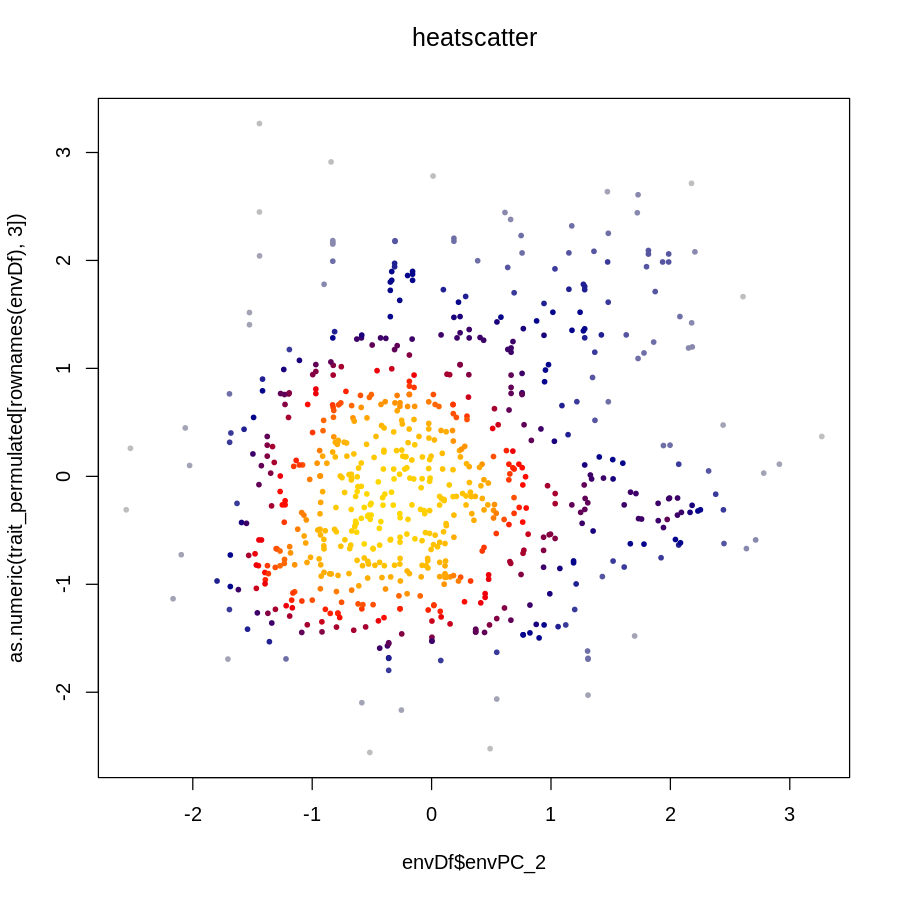

In [57]:
LSD::heatscatter(envDf$envPC_2,as.numeric(trait_permulated[rownames(envDf),3]))

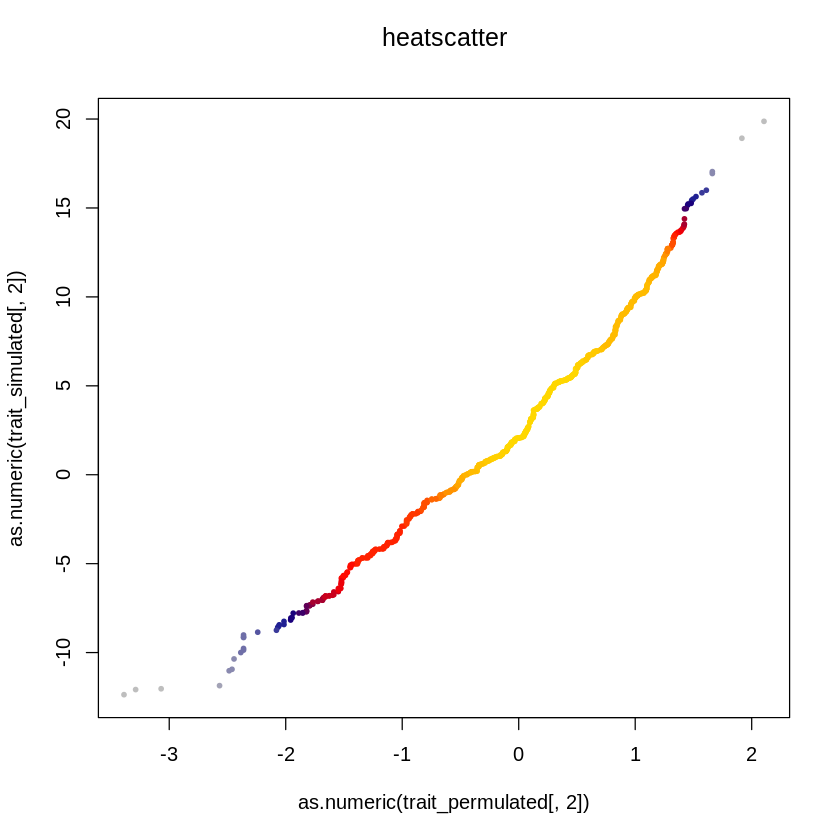

In [14]:
LSD::heatscatter(as.numeric(trait_permulated[,2]),as.numeric(trait_simulated[,2]))

In [367]:
x = c(20,52,90,65,60,22)
y = c(36,10,12,20,25,15)
z = c(90,20,22,60,65,52)
cbind(sort(x)[rank(y)],z)

,z
90,90
20,20
22,22
60,60
65,65
52,52


In [368]:
dim(trait_permulated)

[1] 707  11

In [369]:
dim(testData_merged)

[1] 16906514      379

In [370]:
testData_merged = merge(testData_merged,trait_permulated,by = "assemblyID")

In [371]:
dim(testData_merged)

[1] 16906514      389

In [372]:
data.table::fwrite(testData_merged,"/workdir/sh2246/p_phyloGWAS/output/masterDataTable_PAVFill_20250814.txt",sep = "\t")

In [184]:
testData_merged = data.table::fread("/workdir/sh2246/p_phyloGWAS/output/masterDataTable_PAVFill_20250814.txt",header = T,data.table = F,nThread = 20)

testData_merged$PMS = as.factor(testData_merged$PMS)
testData_merged$PAV = as.factor(testData_merged$PAV)
testData_merged$assemblyID = as.factor(testData_merged$assemblyID)
testData_merged$pacbio = as.factor(testData_merged$pacbio)
testData_merged$groups2 = as.factor(testData_merged$groups2)

# variance explained by phylogeny

In [15]:
trait_permulated = as.data.frame(trait_permulated)
for (i in 2:11){
    trait_permulated[,i] = as.numeric(trait_permulated[,i])
}

In [137]:
trait_permulated = sapply(envPC1_perm[1:100],function(x) x[,2])
colnames(trait_permulated) = paste0("trait_",1:100)

In [138]:
trait_permulated = cbind(envPC1_perm[[1]][,1],as.data.frame(trait_permulated))
colnames(trait_permulated)[1] = "assemblyID"

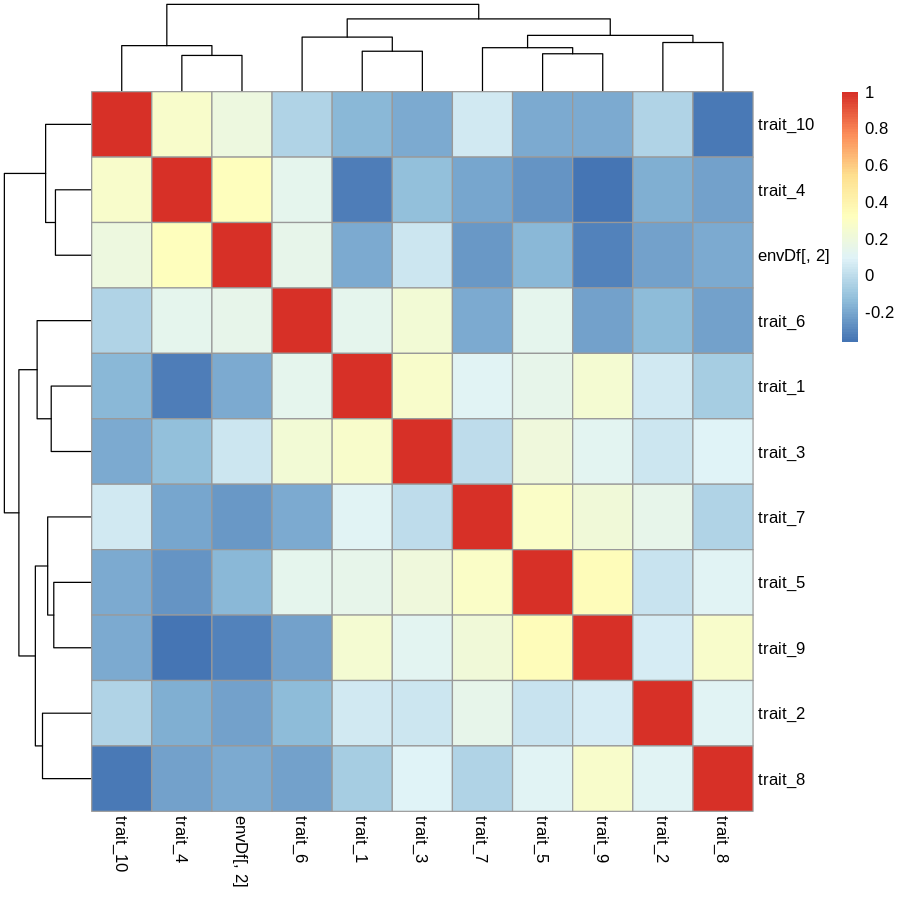

In [283]:
pheatmap(cor(cbind(trait_permulated[,-1],envDf[,2]),method = "spearman"))

In [139]:
dat = merge(envDf,metadata,by = "assemblyID")
dat = merge(dat,as.data.frame(trait_permulated),by = "assemblyID")
dat$compdup = dat$complete + dat$duplicated
rownames(dat) = dat$assemblyID
dat$pacbio = as.factor(grepl("pacbio",dat$technology,ignore.case = T))
dat$assemblyID = as.factor(dat$assemblyID)

In [130]:
head(dat)

,assemblyID,envPC_1,envPC_2,envPC_3,envPC_4,envPC_5,envPC_6,envPC_7,envPC_8,envPC_9,⋯,trait_91,trait_92,trait_93,trait_94,trait_95,trait_96,trait_97,trait_98,trait_99,trait_100
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10wheat_assembly_jagger,10wheat_assembly_jagger,-1.52170,1.28238,-0.35554,0.50279,-0.39494,0.70373,-0.49723,-0.35207,1.32033,⋯,-0.13015,-1.25377,-2.01505,1.31414,1.12069,0.74718,-1.44370,1.18221,0.83047,1.05877
10wheat_assembly_lancer,10wheat_assembly_lancer,-1.52170,1.28238,-0.35554,0.50279,-0.39494,0.70373,-0.49723,-0.35207,1.32033,⋯,-0.09710,-1.25377,-1.85042,1.28118,1.09448,0.73846,-1.62508,1.18355,0.83094,1.10574
10wheat_assembly_stanley,10wheat_assembly_stanley,-1.52170,1.28238,-0.35554,0.50279,-0.39494,0.70373,-0.49723,-0.35207,1.32033,⋯,-0.25455,-0.90917,-2.01505,1.27748,1.11597,0.77392,-1.52170,1.15568,0.87223,1.13752
A17,A17,-1.25377,0.66588,0.57274,1.01012,-0.03058,-0.02155,-1.98184,0.77267,-0.18752,⋯,-1.15057,-1.54890,-3.28833,1.32346,1.24512,1.23535,-2.56798,1.10065,1.22917,-1.29538
A42,A42,-1.25377,0.66588,0.57274,1.01012,-0.03058,-0.02155,-1.98184,0.77267,-0.18752,⋯,-1.47333,-2.01505,-2.38558,1.19921,0.99266,0.75443,-2.38558,1.23399,1.33645,1.61066
AANG_UGA4,AANG_UGA4,0.79987,-0.84360,0.43092,0.53523,-0.59215,-1.30357,-0.04736,0.28831,-0.83248,⋯,1.39204,1.30584,-0.53629,1.32147,1.32147,-0.40416,0.47525,1.66205,1.27748,-0.48844


In [131]:
R2phylo_perm = c()
for (i in 1:100){
    myF1 = as.formula(paste0("trait_", i, "~ compdup + pacbio"))
    myF2 = as.formula(paste0("trait_", i, "~ 1"))
    model_Covariate <- asreml(fixed = myF1,random = ~ vm(assemblyID, phyloKMat),
                              ai.sing = F, data = dat)
    R2phylo_perm = c(R2phylo_perm,summary(model_Covariate)$varcomp$component[1]/sum(summary(model_Covariate)$varcomp$component)) 
}

ASReml Version 4.2 09/09/2025 15:57:11
          LogLik        Sigma2     DF     wall
 1     -146.8388     0.5140962    704   15:57:11
 2     -73.84525     0.4055757    704   15:57:11
 3      24.24417     0.2861656    704   15:57:11
 4      115.2307     0.1935418    704   15:57:11
 5      173.8566     0.1334874    704   15:57:12
 6      191.4315     0.1060227    704   15:57:12
 7      193.7788    0.09599299    704   15:57:12
 8      193.8496    0.09414945    704   15:57:12
 9      193.8498    0.09405385    704   15:57:12
ASReml Version 4.2 09/09/2025 15:57:12
          LogLik        Sigma2     DF     wall
 1     -153.3904     0.5237544    704   15:57:12
 2     -103.8846     0.4445947    704   15:57:12
 3     -39.38466     0.3511901    704   15:57:12
 4      22.91895     0.2661140    704   15:57:13
 5      70.50649     0.1963167    704   15:57:13
 6      90.54189     0.1557817    704   15:57:13
 7      95.83864     0.1354433    704   15:57:13
 8      96.53446     0.1278944    704   15:5

In [103]:
summary(model_Covariate)

$call
asreml(fixed = myF1, random = ~vm(assemblyID, phyloKMat), data = dat, 
    ai.sing = F)

$loglik
[1] 98.59517

$nedf
[1] 704

$sigma
[1] 0.341131

$varcomp
                          component   std.error   z.ratio bound %ch
vm(assemblyID, phyloKMat) 1.7068180 0.198612515  8.593708     P 0.1
units!R                   0.1163704 0.009241224 12.592528     P 0.0

$bic
[1] -184.0768
attr(,"parameters")
[1] 2

$aic
[1] -193.1903
attr(,"parameters")
[1] 2

attr(,"class")
[1] "summary.asreml"

In [432]:
infoCriteria(model_Covariate)

fixedDF,varDF,NBound,AIC,BIC,loglik
<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>
0,2,0,114.3878,123.507,-55.19391


In [104]:
rownames(trait_permulated) = trait_permulated[,1]

In [134]:
names(R2phylo_perm) = paste0("perm",1:100)

In [135]:
sort(R2phylo_perm)

perm91    perm40   perm100    perm21    perm85     perm5    perm83    perm58 
0.8311332 0.8432116 0.8447549 0.8524511 0.8532800 0.8559738 0.8581248 0.8585850 
   perm92    perm15    perm57    perm44    perm23    perm89    perm67    perm31 
0.8594140 0.8631634 0.8657876 0.8679039 0.8726852 0.8759306 0.8778422 0.8780181 
   perm42     perm8    perm52    perm36    perm17     perm3    perm55    perm88 
0.8784877 0.8793330 0.8794708 0.8815590 0.8829290 0.8829313 0.8838203 0.8848573 
   perm18    perm37    perm65     perm7    perm71    perm66    perm68    perm35 
0.8853386 0.8867053 0.8872816 0.8877234 0.8879984 0.8880283 0.8885206 0.8885599 
   perm13    perm33    perm93    perm50    perm59    perm84    perm26    perm22 
0.8901719 0.8908622 0.8915589 0.8928507 0.8940274 0.8946458 0.8954014 0.8957804 
   perm90    perm75    perm32    perm28    perm80    perm34    perm74    perm78 
0.8957990 0.8967189 0.8968009 0.8994803 0.8996930 0.9000576 0.9002897 0.9025192 
   perm82    perm73    perm70    perm47    perm39    perm38    perm60    perm94 
0.9025525 0.9030647 0.9034811 0.9036257 0.9036871 0.9041391 0.9045376 0.9046461 
   perm53    perm46    perm62    perm12    perm76    perm51    perm45    perm61 
0.9047183 0.9051106 0.9062443 0.9062450 0.9074862 0.9081808 0.9085150 0.9092675 
   perm86     perm4    perm25    perm64    perm30    perm19    perm43    perm87 
0.9118764 0.9123269 0.9127077 0.9150958 0.9155862 0.9156776 0.9168149 0.9186454 
   perm81    perm48     perm6    perm99    perm41    perm29    perm79     perm2 
0.9188510 0.9189530 0.9191139 0.9209914 0.9210132 0.9213489 0.9222848 0.9229132 
   perm77     perm1    perm16    perm11    perm14    perm69    perm95    perm97 
0.9237203 0.9256570 0.9259664 0.9262737 0.9267740 0.9296111 0.9299179 0.9299337 
   perm56    perm98    perm72    perm54    perm49     perm9    perm10    perm24 
0.9313144 0.9313862 0.9314871 0.9328869 0.9331300 0.9353462 0.9361721 0.9376643 
   perm96    perm20    perm63    perm27 
0.9395918 0.9441257 0.9449478 0.9452810

In [433]:
realTrait = envDf[,2]
names(realTrait) = rownames(envDf)

In [434]:
permTrait = lapply(envPC1_perm[1:10],function(x) {
    tmp = x[,2]
    names(tmp) = x[,1]
    return(tmp)
})

In [435]:
library(ggnewscale)

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the ex

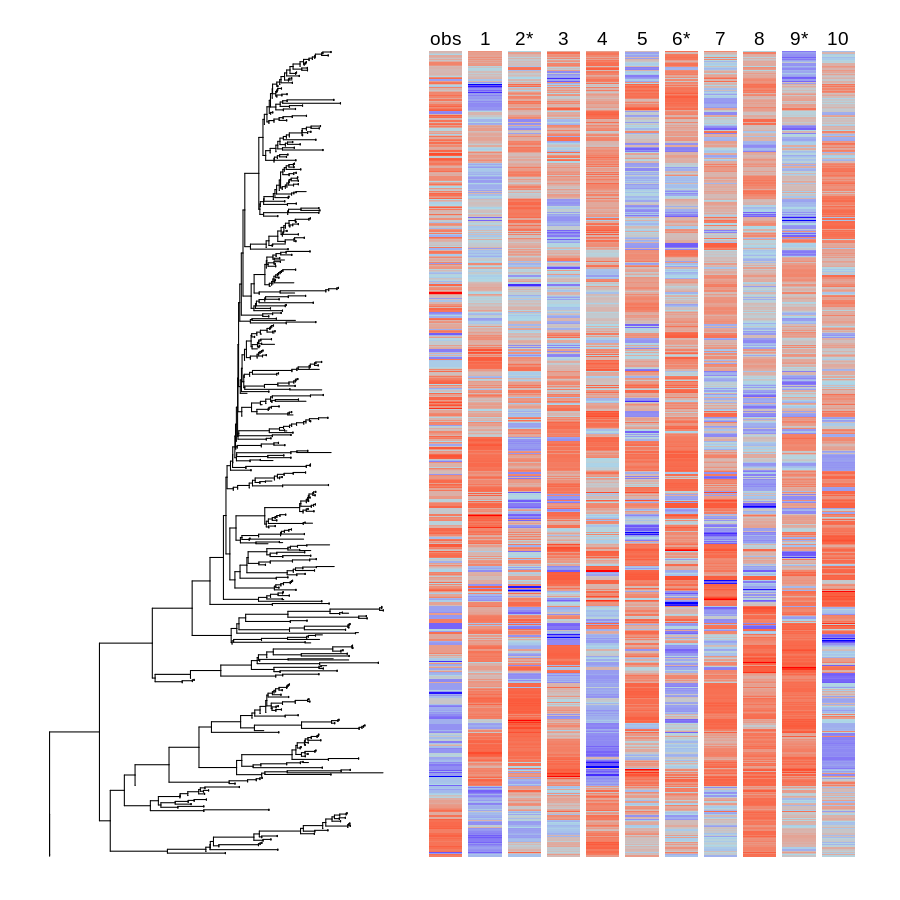

In [460]:
p <- ggtree(spTre.rooted,layout = "rectangular", ladderize = T,size = .3)
p1 <- p+ new_scale_fill()
p1 <- gheatmap(p1, data.frame(obs = realTrait) , offset=1.7, width=0.1,colnames = T,color = NA,
               colnames_position = "top",colnames_offset_y = 10) +
    scale_x_ggtree() + 
    scale_y_continuous(expand=c(0, 0.3))+
    scale_fill_gradientn(colours = c('blue',"lightblue",'red'),name = "envPC1")
for(i in 1:10){
    p1 <- p1+ new_scale_fill()
    tmp = data.frame(trait = permTrait[[i]])
    colnames(tmp) = i
    p1 <- gheatmap(p1,  tmp, offset=1.7 + i*2.3, width=0.1,colnames = T,color = NA,custom_column_labels = ifelse(i%in%c(2,6,9),paste0(i,"*"),i),
                   colnames_position = "top",colnames_offset_y = 10) +
        scale_y_continuous(expand=c(0, 30))+
        scale_fill_gradientn(colours = c('blue',"lightblue",'red'),name = i)+
        theme(axis.text=element_text(size=5),legend.position = "none",
              plot.margin = margin(t= 1, r= 1,b = 1,l = 1, unit='mm'))

}
p1

In [474]:
anova(lm(envDf[,2]~metadata[trait_permulated[,1],]$subfamily))
for( i in 1:10){
    print(anova(lm(trait_permulated[,1+i]~metadata[trait_permulated[,1],]$subfamily))[1,4])
}


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
"metadata[trait_permulated[, 1], ]$subfamily",7,215.8927,30.8418139,43.89778,1.852667e-51
Residuals,698,490.4026,0.7025826,NA,NA


[1] 39.13616
[1] 19.95237
[1] 7.722868
[1] 93.7165
[1] 7.649266
[1] 13.87903
[1] 19.9809
[1] 47.41483
[1] 37.6579
[1] 28.78089


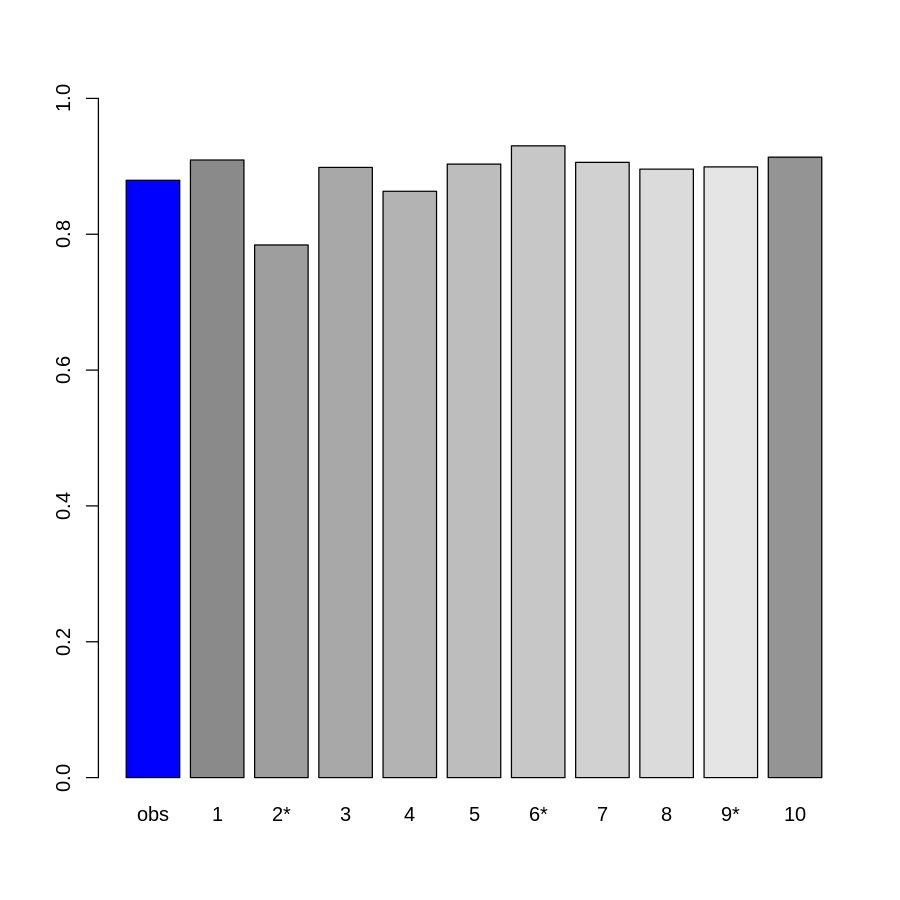

In [487]:
barplot(c(R2phylo[1],R2phylo_perm),col = c("blue",paste0("grey",50+c(1,3:10,2)*4)),
        names.arg = c("obs",paste0(1:10,ifelse(1:10%in%c(2,6,9),"*",""))),ylim = c(0,1))

In [480]:
c(R2phylo[1],R2phylo_perm)

[1] 0.8794022 0.9093152 0.7842376 0.8984147 0.8632756 0.9032913 0.9301566
 [8] 0.9058284 0.8958494 0.8991421 0.9134907

In [475]:
R2phylo = c()
for (i in 1:5){
    myF1 = as.formula(paste0("envPC_", i, "~ compdup + pacbio"))
    myF2 = as.formula(paste0("envPC_", i, "~ 1"))
    model_Covariate <- asreml(fixed = myF2,random = ~ vm(assemblyID, phyloKMat),
                              ai.sing = F, data = dat)
    R2phylo = c(R2phylo,summary(model_Covariate)$varcomp$component[1]/sum(summary(model_Covariate)$varcomp$component)) 
}
R2phylo_perm = c()
for (i in 1:5){
    myF1 = as.formula(paste0("perm_envPC", i, "~ compdup + pacbio"))
    myF2 = as.formula(paste0("perm_envPC", i, "~ 1"))
    model_Covariate <- asreml(fixed = myF2,random = ~ vm(assemblyID, phyloKMat),
                              ai.sing = F, data = dat)
    R2phylo_perm = c(R2phylo_perm,summary(model_Covariate)$varcomp$component[1]/sum(summary(model_Covariate)$varcomp$component)) 
}

ASReml Version 4.2 08/09/2025 15:24:02
          LogLik        Sigma2     DF     wall
 1     -223.8705     0.6604753    706   15:24:02
 2     -206.1005     0.6164146    706   15:24:02
 3     -178.4923     0.5451694    706   15:24:02
 4     -146.6205     0.4565161    706   15:24:02
 5     -120.8881     0.3696999    706   15:24:02
 6     -110.6513     0.3162182    706   15:24:03
 7     -107.9983     0.2884755    706   15:24:03
 8     -107.5545     0.2767749    706   15:24:03
 9     -107.5033     0.2727256    706   15:24:03
10     -107.4986     0.2714823    706   15:24:03
11     -107.4982     0.2711188    706   15:24:03
ASReml Version 4.2 08/09/2025 15:24:03
          LogLik        Sigma2     DF     wall
 1     -308.5687     0.8395769    706   15:24:03
 2     -291.9610     0.7811140    706   15:24:03
 3     -268.0478     0.6921597    706   15:24:04
 4     -246.6122     0.5991829    706   15:24:04
 5     -233.6146     0.5176577    706   15:24:04
 6     -230.4203     0.4753482    706   15:2

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'as.matrix': object 'perm_envPC1' not found


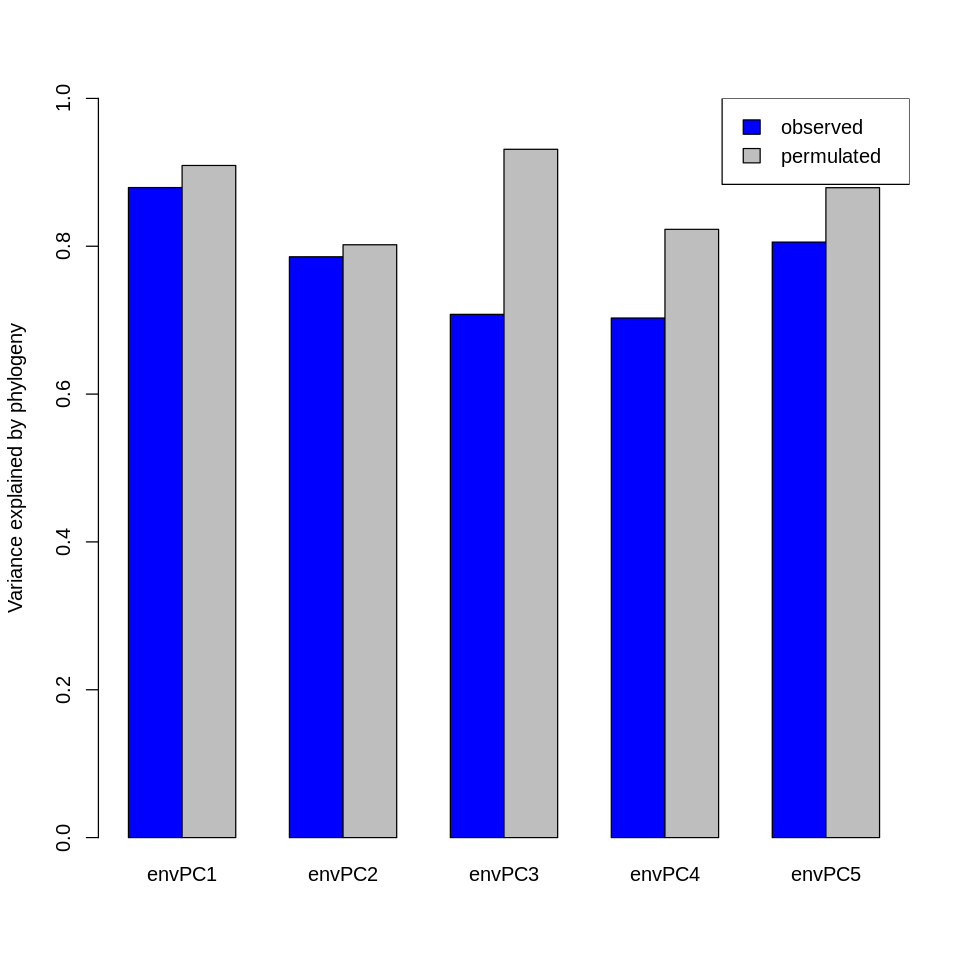

In [18]:
options(repr.plot.width = 8, repr.plot.height = 8)
barplot(t(cbind(R2phylo,R2phylo_perm)),beside = T,ylim = c(0,1),ylab = "Variance explained by phylogeny",
        col = c("blue","grey"),names.arg = paste0("envPC",1:5))
legend("topright",fill = c("blue","grey"), legend = c("observed","permulated"))

# modeling 

In [8]:
OG_list = unique(testData_merged$OG)

In [9]:
mappingFile = read.table("/workdir/sh2246/p_phyloGWAS_archived/output/OGToPv_mapping_v2.txt")
mappingFile2 = read.table("/workdir/sh2246/p_phyloGWAS_archived/output/OGToZm_mapping_v2.txt")

colnames(mappingFile) = c("PvID","OG")
colnames(mappingFile2) = c("ZmID","OG")

mappingFileMerged = merge(mappingFile,mappingFile2,by = "OG",all = T)

head(mappingFileMerged)

,OG,PvID,ZmID
,<chr>,<chr>,<chr>
1,OG0000062,Pavag10G051000.1,Zm00001eb181730_T001
2,OG0000098,Pavag07G174700.1,Zm00001eb313690_T001
3,OG0000106,Pavag06G183800.1,Zm00001eb429540_T001
4,OG0000124,Pavag09G171600.1,Zm00001eb428040_T001
5,OG0000150,Pavag03G414300.1,Zm00001eb267280_T001
6,OG0000152,Pavag03G317400.1,Zm00001eb352080_T002


In [13]:
asreml.options(maxit = 30,verbose = F)
test = fit_model_v3("OG0003466",data = testData_merged,phyloKMat,"envPC_1")

ASReml Version 4.2 12/09/2025 12:34:36
          LogLik        Sigma2     DF     wall
 1     -224.6888     0.5982395    749   12:34:37
 2     -206.8632     0.5586010    749   12:34:37
 3     -178.4088     0.4928409    749   12:34:37
 4     -146.3483     0.4131336    749   12:34:37
 5     -120.1693     0.3352712    749   12:34:37
 6     -108.3881     0.2845941    749   12:34:37
 7     -104.5268     0.2556581    749   12:34:37
 8     -103.5824     0.2411850    749   12:34:37
 9     -103.4004     0.2347619    749   12:34:38
10     -103.3704     0.2321351    749   12:34:38
11     -103.3658     0.2311061    749   12:34:38
12     -103.3651     0.2307107    749   12:34:38
ASReml Version 4.2 12/09/2025 12:34:38
          LogLik        Sigma2     DF     wall
 1     -294.3572     0.7471217    749   12:34:38
ASReml Version 4.2 12/09/2025 12:34:38
          LogLik        Sigma2     DF     wall
 1     -232.2300     0.6279878    754   12:34:38
 2     -213.4814     0.5865387    754   12:34:38
 3     

In [38]:
as.data.frame(test$coefficients$fixed)[paste0("PAV_1",c("",":scaled.dn.ds",":scaledESM",":scaledPlantCAD",":PMS_1")),]

[1]  0.10802545  0.06105676  0.00637944  0.09275652 -0.45767168

In [34]:
as.data.frame(wald(test))[paste0("PAV",c("",":scaled.dn.ds",":scaledESM",":scaledPlantCAD",":PMS1")),4]

[1] 0.395836728 0.082408273 0.122894385          NA 0.007576897

In [23]:
rownames(test$coefficients$fixed)

[1] "(Intercept)"          "PAV_0"                "PAV_1"               
 [4] "compdup"              "pacbio_FALSE"         "pacbio_TRUE"         
 [7] "PAV_0:scaled.dn.ds"   "PAV_1:scaled.dn.ds"   "PAV_0:scaledESM"     
[10] "PAV_1:scaledESM"      "PAV_0:scaledPlantCAD" "PAV_1:scaledPlantCAD"
[13] "PAV_0:PMS_0"          "PAV_0:PMS_1"          "PAV_1:PMS_0"         
[16] "PAV_1:PMS_1"          "PAV_0:queryCov"       "PAV_1:queryCov"

In [20]:
paste0("PAV_1:",c("","scaled.dn.ds","scaledESM","scaledPlantCAD","PMS_1"))

[1] "PAV_1:"               "PAV_1:scaled.dn.ds"   "PAV_1:scaledESM"     
[4] "PAV_1:scaledPlantCAD" "PAV_1:PMS_1"

In [8]:
# asreml.options(maxit = 40,verbose = F)
# testRes_envPC1_v2 = mclapply(OG_list,function(x) try(fit_model_v3(x,testData_merged,phyloKMat,"envPC_1"),
#                                                      silent = T),mc.cores = 10)
# testRes_envPC1_v2 = t(simplify2array(testRes_envPC1_v2[sapply(testRes_envPC1_v2,length)==length(test)]))
# testRes_envPC1_v2 = as.data.frame(testRes_envPC1_v2)
# testRes_envPC1_v2 = merge(testRes_envPC1_v2,mappingFileMerged,by = "OG",all.x = T)
# write.table(testRes_envPC1_v2,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1_20250811.txt",quote = F,sep = "\t",row.names = F)
testRes_envPC1_v2 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1_20250811.txt",header =T)

In [63]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC2_v2 = mclapply(OG_list,function(x) try(fit_model_v3(x,testData_merged,phyloKMat,"envPC_2"),
                                                     silent = T),mc.cores = 10)
testRes_envPC2_v2 = t(simplify2array(testRes_envPC2_v2[sapply(testRes_envPC2_v2,length)==length(test)]))
testRes_envPC2_v2 = as.data.frame(testRes_envPC2_v2)
testRes_envPC2_v2 = merge(testRes_envPC2_v2,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_envPC2_v2,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC2_20250811.txt",quote = F,sep = "\t",row.names = F)
testRes_envPC2_v2 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC2_20250811.txt",header =T)

In [78]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC3_v2 = mclapply(OG_list,function(x) try(fit_model_v3(x,testData_merged,phyloKMat,"envPC_3"),
                                                     silent = T),mc.cores = 20)
testRes_envPC3_v2 = t(simplify2array(testRes_envPC3_v2[sapply(testRes_envPC3_v2,length)==length(test)]))
testRes_envPC3_v2 = as.data.frame(testRes_envPC3_v2)
testRes_envPC3_v2 = merge(testRes_envPC3_v2,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_envPC3_v2,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC3_20250811.txt",quote = F,sep = "\t",row.names = F)
testRes_envPC3_v2 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC3_20250811.txt",header =T)

In [23]:
asreml.options(maxit = 40,verbose = F)
set.seed(1234)
testRes_envPC1_perm = mclapply(OG_list,function(x) try(fit_model_v3(x,testData_merged,phyloKMat,"perm_envPC1"),
                                                     silent = T),mc.cores = 20)
testRes_envPC1_perm = t(simplify2array(testRes_envPC1_perm[sapply(testRes_envPC1_perm,length)==length(test)]))
testRes_envPC1_perm = as.data.frame(testRes_envPC1_perm)
testRes_envPC1_perm = merge(testRes_envPC1_perm,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_envPC1_perm,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_perm_envPC1_20250814.txt",quote = F,sep = "\t",row.names = F)
testRes_envPC1_perm = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_perm_envPC1_20250814.txt",header =T)

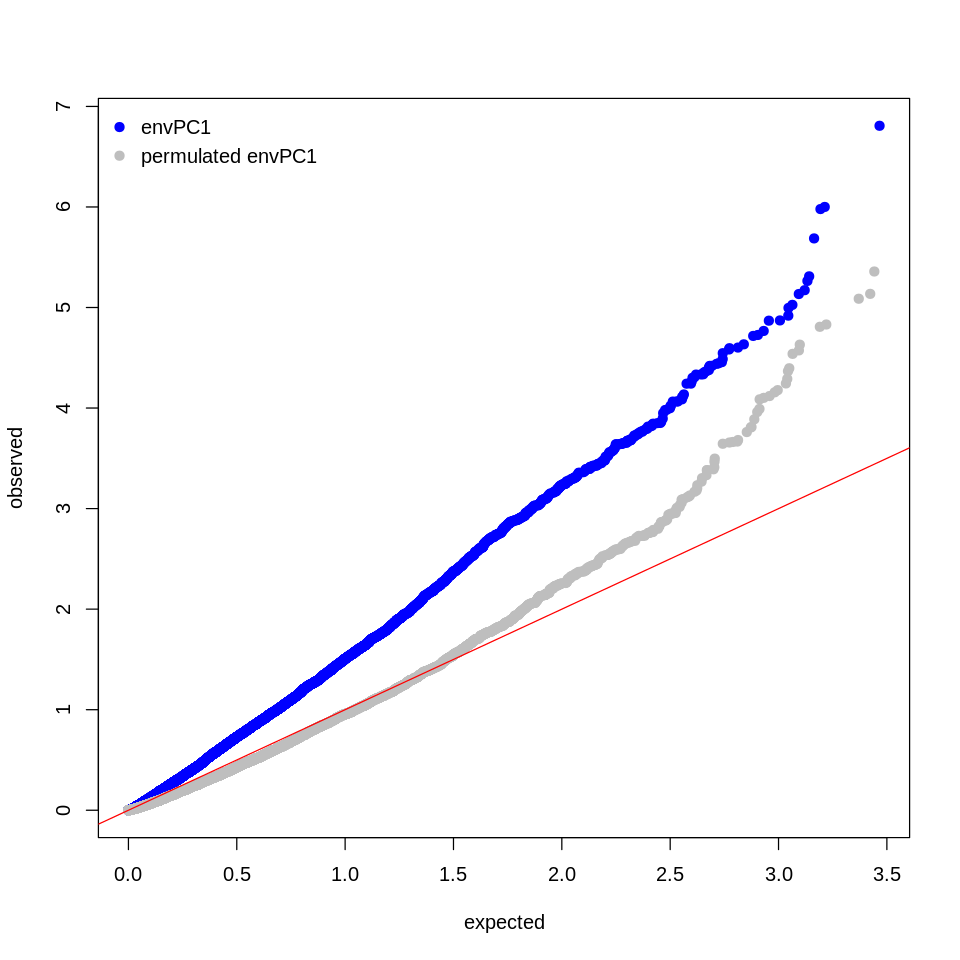

In [35]:
set.seed(1234)
plot(sort(-log10(runif(0,1,n = nrow(testRes_envPC1_v2)))),
     sort(-log10(as.numeric(testRes_envPC1_v2$p))),
     pch = 19,xlab = "expected",ylab = "observed",col = "blue")
points(sort(-log10(runif(0,1,n = nrow(testRes_envPC1_perm)))),
       sort(-log10(as.numeric(testRes_envPC1_perm$p))),pch = 19,col ="grey")
abline (a = 0,b= 1,col ="red")
legend("topleft",legend = c("envPC1","permulated envPC1"),pch = 19, col = c("blue","grey"),bty = 'n')

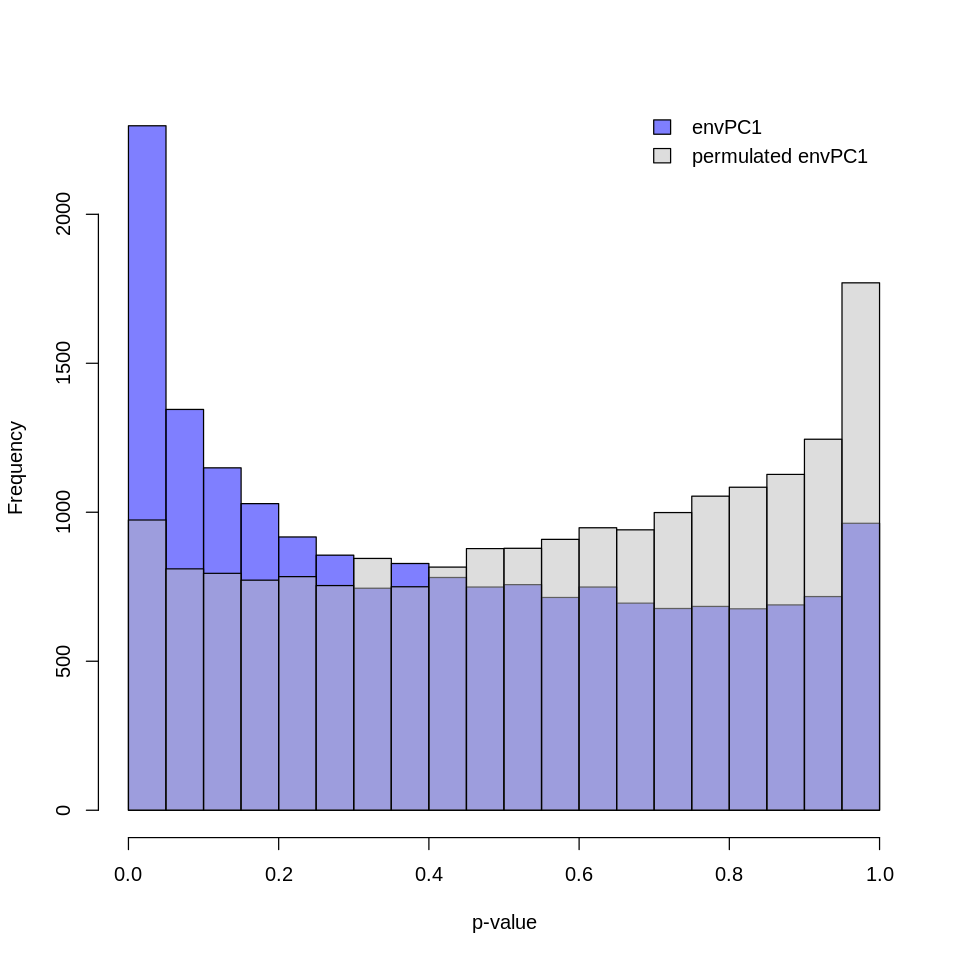

In [27]:
hist(testRes_envPC1_v2$p, col = alpha("blue",.5), xlab = "p-value",main = "")
hist(as.numeric(testRes_envPC1_perm$p),col = alpha("grey",.5),add = T)
legend("topright",legend = c("envPC1","permulated envPC1"),fill = alpha(c("blue","grey"),.5),bty = 'n')

In [42]:
asreml.options(maxit = 40,verbose = F)
set.seed(1234)
testRes_envPC2_perm = mclapply(OG_list,function(x) try(fit_model_v3(x,testData_merged,phyloKMat,"perm_envPC2"),
                                                     silent = T),mc.cores = 20)
testRes_envPC2_perm = t(simplify2array(testRes_envPC2_perm[sapply(testRes_envPC2_perm,length)==length(test)]))
testRes_envPC2_perm = as.data.frame(testRes_envPC2_perm)
testRes_envPC2_perm = merge(testRes_envPC2_perm,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_envPC2_perm,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_perm_envPC2_20250814.txt",quote = F,sep = "\t",row.names = F)
testRes_envPC2_perm = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_perm_envPC2_20250814.txt",header =T)

In [131]:
sum(testRes_envPC1_v2$p<.05)

[1] 2297

In [79]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC4_v2 = mclapply(OG_list,function(x) try(fit_model_v3(x,testData_merged,phyloKMat,"envPC_4"),
                                                     silent = T),mc.cores = 20)
testRes_envPC4_v2 = t(simplify2array(testRes_envPC4_v2[sapply(testRes_envPC4_v2,length)==length(test)]))
testRes_envPC4_v2 = as.data.frame(testRes_envPC4_v2)
testRes_envPC4_v2 = merge(testRes_envPC4_v2,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_envPC4_v2,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC4_20250811.txt",quote = F,sep = "\t",row.names = F)
testRes_envPC4_v2 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC4_20250811.txt",header =T)

Warning message in mclapply(OG_list, function(x) try(fit_model_v3(x, testData_merged, :
“all scheduled cores encountered errors in user code”


ERROR: Error in fix.by(by.x, x): 'by' must specify a uniquely valid column


In [ ]:
testRes_envPC4_v2[[1]]

In [ ]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC5_v2 = mclapply(OG_list,function(x) try(fit_model_v3(x,testData_merged,phyloKMat,"envPC_5"),
                                                     silent = T),mc.cores = 20)
testRes_envPC5_v2 = t(simplify2array(testRes_envPC5_v2[sapply(testRes_envPC5_v2,length)==length(test)]))
testRes_envPC5_v2 = as.data.frame(testRes_envPC5_v2)
testRes_envPC5_v2 = merge(testRes_envPC5_v2,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_envPC5_v2,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC5_20250811.txt",quote = F,sep = "\t",row.names = F)
testRes_envPC5_v2 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC5_20250811.txt",header =T)

In [73]:
testRes_envPC5_v2[[1]]

ERROR: Error in .subset2(x, i, exact = exact): subscript out of bounds


In [155]:
head(dat)

,assemblyID,envPC_1,envPC_2,envPC_3,envPC_4,envPC_5,envPC_6,envPC_7,envPC_8,envPC_9,⋯,trait_91,trait_92,trait_93,trait_94,trait_95,trait_96,trait_97,trait_98,trait_99,trait_100
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
10wheat_assembly_jagger,10wheat_assembly_jagger,-1.52170,1.28238,-0.35554,0.50279,-0.39494,0.70373,-0.49723,-0.35207,1.32033,⋯,-0.13015,-1.25377,-2.01505,1.31414,1.12069,0.74718,-1.44370,1.18221,0.83047,1.05877
10wheat_assembly_lancer,10wheat_assembly_lancer,-1.52170,1.28238,-0.35554,0.50279,-0.39494,0.70373,-0.49723,-0.35207,1.32033,⋯,-0.09710,-1.25377,-1.85042,1.28118,1.09448,0.73846,-1.62508,1.18355,0.83094,1.10574
10wheat_assembly_stanley,10wheat_assembly_stanley,-1.52170,1.28238,-0.35554,0.50279,-0.39494,0.70373,-0.49723,-0.35207,1.32033,⋯,-0.25455,-0.90917,-2.01505,1.27748,1.11597,0.77392,-1.52170,1.15568,0.87223,1.13752
A17,A17,-1.25377,0.66588,0.57274,1.01012,-0.03058,-0.02155,-1.98184,0.77267,-0.18752,⋯,-1.15057,-1.54890,-3.28833,1.32346,1.24512,1.23535,-2.56798,1.10065,1.22917,-1.29538
A42,A42,-1.25377,0.66588,0.57274,1.01012,-0.03058,-0.02155,-1.98184,0.77267,-0.18752,⋯,-1.47333,-2.01505,-2.38558,1.19921,0.99266,0.75443,-2.38558,1.23399,1.33645,1.61066
AANG_UGA4,AANG_UGA4,0.79987,-0.84360,0.43092,0.53523,-0.59215,-1.30357,-0.04736,0.28831,-0.83248,⋯,1.39204,1.30584,-0.53629,1.32147,1.32147,-0.40416,0.47525,1.66205,1.27748,-0.48844


In [175]:
fm = nlme::gls(model = envPC_1~compdup+pacbio,data = dat,correlation = corBrownian(value = 1,phy = spTre.rooted.resolved,form = ~assemblyID))
fm2 = nlme::gls(model = envPC_1~compdup+pacbio,data = dat)

In [181]:
anova(fm)

,numDF,F-value,p-value
,<int>,<dbl>,<dbl>
(Intercept),1,0.1145397,0.7351347
compdup,1,0.2177660,0.6408918
pacbio,1,2.0774765,0.1499318


In [146]:
?ape::corBrownian


In [ ]:
## more permualation

In [9]:
envPC1_perm = list()
set.seed(123)
for (i in 1:1000){
    # trait vector
    trait_test = envDf[,2]
    names(trait_test) = rownames(envDf)

    # rate estimates and simulation
    rate_test = ratematrix(spTre.rooted.resolved, trait_test)
    trait_sim = sim.char(spTre.rooted.resolved,rate_test,nsim = 1)
#     trait_simulated = cbind(trait_simulated,trait_sim[,,1])
    envPC1_perm[[i]] = data.frame("assemblyID"=rownames(envDf),"trait" = sort(trait_test)[rank(trait_sim[,,1])])
    
}

In [10]:
testRes_envPC1_permList = mclapply(list.files("/workdir/sh2246/p_phyloGWAS/output/permulation/envPC1/",full.names = T),
                       function(x) read.table(x,header = T))

In [11]:
list.files("/workdir/sh2246/p_phyloGWAS/output/permulation/envPC1/",full.names = T)

[1] "/workdir/sh2246/p_phyloGWAS/output/permulation/envPC1//ASREML_res_perm_1.txt" 
 [2] "/workdir/sh2246/p_phyloGWAS/output/permulation/envPC1//ASREML_res_perm_10.txt"
 [3] "/workdir/sh2246/p_phyloGWAS/output/permulation/envPC1//ASREML_res_perm_2.txt" 
 [4] "/workdir/sh2246/p_phyloGWAS/output/permulation/envPC1//ASREML_res_perm_3.txt" 
 [5] "/workdir/sh2246/p_phyloGWAS/output/permulation/envPC1//ASREML_res_perm_4.txt" 
 [6] "/workdir/sh2246/p_phyloGWAS/output/permulation/envPC1//ASREML_res_perm_5.txt" 
 [7] "/workdir/sh2246/p_phyloGWAS/output/permulation/envPC1//ASREML_res_perm_6.txt" 
 [8] "/workdir/sh2246/p_phyloGWAS/output/permulation/envPC1//ASREML_res_perm_7.txt" 
 [9] "/workdir/sh2246/p_phyloGWAS/output/permulation/envPC1//ASREML_res_perm_8.txt" 
[10] "/workdir/sh2246/p_phyloGWAS/output/permulation/envPC1//ASREML_res_perm_9.txt"

In [12]:
mergedPval_envPC1 = merge(data.frame(OG = testRes_envPC1_v2$OG),testRes_envPC1_v2[,c(1,5)],by = "OG",all.x = T)
for(i in 1:10){
    mergedPval_envPC1 = merge(mergedPval_envPC1,testRes_envPC1_permList[[i]][,c(1,5)],by = "OG",all.x = T)
}

colnames(mergedPval_envPC1)[-1] = c("p",paste0("perm_p_",1:10))

Warning message in merge.data.frame(mergedPval_envPC1, testRes_envPC1_permList[[i]][, :
“column names ‘p.x’, ‘p.y’ are duplicated in the result”
Warning message in merge.data.frame(mergedPval_envPC1, testRes_envPC1_permList[[i]][, :
“column names ‘p.x’, ‘p.y’ are duplicated in the result”
Warning message in merge.data.frame(mergedPval_envPC1, testRes_envPC1_permList[[i]][, :
“column names ‘p.x’, ‘p.y’, ‘p.x’, ‘p.y’ are duplicated in the result”
Warning message in merge.data.frame(mergedPval_envPC1, testRes_envPC1_permList[[i]][, :
“column names ‘p.x’, ‘p.y’, ‘p.x’, ‘p.y’ are duplicated in the result”
Warning message in merge.data.frame(mergedPval_envPC1, testRes_envPC1_permList[[i]][, :
“column names ‘p.x’, ‘p.y’, ‘p.x’, ‘p.y’, ‘p.x’, ‘p.y’ are duplicated in the result”
Warning message in merge.data.frame(mergedPval_envPC1, testRes_envPC1_permList[[i]][, :
“column names ‘p.x’, ‘p.y’, ‘p.x’, ‘p.y’, ‘p.x’, ‘p.y’ are duplicated in the result”
Warning message in merge.data.frame(mergedPval

In [421]:
head(testRes_envPC1_v2)
head(testRes_envPC1_permList[[7]])

,OG,BIC_full,BIC_reduced,LR,p,geneVAE,phyloVAE,totalVar,partialCoeff_PAV,partialCoeff_dNdS,⋯,partialCoeff_plantCad,partialCoeff_PMS,partialP_PAV,partialP_dNdS,partialP_ESM2,partialP_plantCad,partialP_PMS,PvID,ZmID,corrected_p
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
1,OG0000164,69.41927,42.66650,7.225757,0.2043846,-0.0004261929,0.6649486,1.071273,0.04200226,-0.03986103,⋯,0.005116204,0.013538709,0.1084321,0.06031772,0.60581257,0.8403946,0.8893458,Pavag01G121200.1,Zm00001eb134090_T001,0.20438463
2,OG0000246,251.88889,224.37904,5.455369,0.3628647,-0.0018828156,0.6449023,1.001453,-0.46429542,-0.03138601,⋯,-0.024773197,-0.124559938,0.1046337,0.97822532,0.20828356,0.9296722,0.4393540,Pavag05G225500.1,Zm00001eb127360_T001,0.36286468
3,OG0000272,92.95480,71.95700,6.286623,0.2793197,-0.0034840768,0.6945210,1.101711,NA,0.04064547,⋯,0.032106467,0.132811038,NA,0.69851129,0.02448222,0.3552495,0.3722782,Pavag05G135100.1,Zm00001eb169970_T004,0.17874120
4,OG0000306,144.47601,113.25993,2.597566,0.7617351,-0.0020085911,0.7479452,1.053615,-0.14791631,-0.01999056,⋯,-0.006346904,0.071426017,0.3067204,0.93956435,0.33265840,0.9706556,0.8025366,Pavag02G045500.2,Zm00001eb205990_T002,0.76173511
5,OG0000314,39.80568,12.35362,6.793274,0.2364744,0.0022842843,0.7496391,1.025004,-0.63604068,-0.06372888,⋯,0.021692879,0.074563141,0.3396926,0.18249953,0.29518026,0.4097306,0.2878763,PavagK222800.1,Zm00001eb164750_T001,0.23647437
6,OG0000315,85.89221,66.91125,8.250782,0.1429454,-0.0002302686,0.6967066,1.110812,NA,-0.07778325,⋯,-0.005508206,0.004715015,NA,0.01728642,0.08940670,0.9957337,0.8893713,Pavag01G255000.1,Zm00001eb026530_T001,0.08281185


,OG,BIC_full,BIC_reduced,LR,p,geneVAE,phyloVAE,totalVar,partialCoeff_PAV,partialCoeff_dNdS,partialCoeff_ESM2,partialCoeff_plantCad,partialCoeff_PMS,partialP_PAV,partialP_dNdS,partialP_ESM2,partialP_plantCad,partialP_PMS,corrected_p
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,OG0000164,69.11478,38.81119,3.674936,0.5970982,-0.0021234530,0.7768483,0.9624739,-0.14049116,-0.0004705866,0.0029098838,0.02353439,0.06537349,0.1141412,0.5288227,0.8943339,0.38494152,0.5704594,0.5970982
2,OG0000185,-42.37719,-69.17291,7.631831,0.1777275,-0.0006771773,0.8302932,0.9126661,-0.03388156,0.0127762036,-0.0436001811,-0.05857018,-0.21846626,0.4402980,0.2316707,0.2269042,0.06864745,0.3044683,0.1777275
3,OG0000202,-147.01382,-176.38148,5.448287,0.3636498,-0.0008213596,0.8946161,1.0081956,-2.96208915,-0.0208682188,0.0003022049,-0.02293195,-0.09735442,0.2017735,0.4936610,0.3712150,0.16905618,0.4871889,0.3636498
4,OG0000209,-69.56619,-94.03945,3.295361,0.6545519,-0.0040675132,0.8503141,1.0074971,NA,-0.0222828481,0.0009619346,0.03772766,0.02473655,NA,0.8713999,0.4109622,0.16308795,0.5629603,0.5096675
5,OG0000246,240.84215,209.38094,1.504017,0.9126058,-0.0029445472,0.7403593,1.0008193,0.10473485,0.0316364260,-0.0527209844,0.01399472,-0.16039267,0.6061907,0.5444197,0.6614643,0.79190045,0.4092328,0.9126058
6,OG0000272,49.11595,26.02527,4.193751,0.5218712,0.0011401838,0.7891872,0.9930304,NA,-0.0140687077,-0.0109984149,-0.04795500,-0.13466132,NA,0.7652833,0.6905699,0.04888045,0.4702411,0.3804191


In [13]:
mergedVAE_envPC1 = merge(data.frame(OG = testRes_envPC1_v2$OG),testRes_envPC1_v2[,c(1,7)],by = "OG",all.x = T)
for(i in 1:10){
    mergedVAE_envPC1 = merge(mergedVAE_envPC1,testRes_envPC1_permList[[i]][,c(1,7)],by = "OG",all.x = T)
}

colnames(mergedVAE_envPC1)[-1] = c("VAE",paste0("VAE",1:10))

Warning message in merge.data.frame(mergedVAE_envPC1, testRes_envPC1_permList[[i]][, :
“column names ‘phyloVAE.x’, ‘phyloVAE.y’ are duplicated in the result”
Warning message in merge.data.frame(mergedVAE_envPC1, testRes_envPC1_permList[[i]][, :
“column names ‘phyloVAE.x’, ‘phyloVAE.y’ are duplicated in the result”
Warning message in merge.data.frame(mergedVAE_envPC1, testRes_envPC1_permList[[i]][, :
“column names ‘phyloVAE.x’, ‘phyloVAE.y’, ‘phyloVAE.x’, ‘phyloVAE.y’ are duplicated in the result”
Warning message in merge.data.frame(mergedVAE_envPC1, testRes_envPC1_permList[[i]][, :
“column names ‘phyloVAE.x’, ‘phyloVAE.y’, ‘phyloVAE.x’, ‘phyloVAE.y’ are duplicated in the result”
Warning message in merge.data.frame(mergedVAE_envPC1, testRes_envPC1_permList[[i]][, :
“column names ‘phyloVAE.x’, ‘phyloVAE.y’, ‘phyloVAE.x’, ‘phyloVAE.y’, ‘phyloVAE.x’, ‘phyloVAE.y’ are duplicated in the result”
Warning message in merge.data.frame(mergedVAE_envPC1, testRes_envPC1_permList[[i]][, :
“column nam

In [223]:
head(mergedPval_envPC1)

,OG,p,perm_p_1,perm_p_2,perm_p_3,perm_p_4,perm_p_5,perm_p_6,perm_p_7,perm_p_8,perm_p_9,perm_p_10
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,OG0000164,0.2043846,0.19210622,0.42307716,0.02290206,0.069961274,0.2534872,0.3685644,0.5970982,0.18242525,0.1731716,0.0007587574
2,OG0000246,0.3628647,0.70939640,0.53829935,0.99832688,0.172764744,0.8059484,0.9994032,0.9126058,0.05142928,0.2382714,0.1580178704
3,OG0000272,0.2793197,0.75802224,0.96201878,0.31364541,0.857875990,0.4145590,0.9960153,0.5218712,0.35800946,0.9396061,0.0005344926
4,OG0000306,0.7617351,0.49988098,0.26082829,0.00742670,0.001225311,0.2550943,0.8448044,0.9800933,0.60943771,0.4601028,0.0051018035
5,OG0000314,0.2364744,0.25108056,0.01760241,0.07974010,0.777138528,0.9310940,0.5897075,0.8446008,0.05634880,0.7736372,0.5338163047
6,OG0000315,0.1429454,0.09864477,0.89184385,0.46225919,0.565950660,0.6043170,0.9395009,0.8139089,0.88626637,0.7879868,0.4011290917


In [224]:
FDR_mlm = c()
sigCount_mlm = c()
for(j in 1:10){
    tmp1 = c()
    tmp2 = c()
    for(i in 10^seq(-4,0,1)){
        tmp1 = c(tmp1,sum(mergedPval_envPC1$p<i,na.rm =T))
        tmp2 = c(tmp2,sum(mergedPval_envPC1[,j+2]<i,na.rm =T)/sum(mergedPval_envPC1$p<i,na.rm =T)*sum(!is.na(mergedPval_envPC1$p))/sum(!is.na(mergedPval_envPC1[,j+2])))
    }
    sigCount_mlm = rbind(sigCount_mlm,tmp1)
    FDR_mlm = rbind(FDR_mlm,tmp2)
}


In [225]:
paste(round(FDR_mlm[,1],3),collapse = " ")

[1] "0.32 0.08 4.78 0.28 0.52 0.58 3.48 0.46 0 15.04"

In [226]:
FDR_mlm_avg = apply(FDR_mlm,2,function(x) median(x))
FDR_mlm_sd = apply(FDR_mlm,2,function(x) sd(x))

In [227]:
FDR_mlm_avg_noOL = apply(FDR_mlm,2,function(x) median(x[x<1]))
FDR_mlm_sd_noOL = apply(FDR_mlm,2,function(x) sd(x[x<1]))

In [228]:
FDR_mlm_sd

[1] 4.677806e+00 2.190546e+00 1.280123e+00 6.192887e-01 8.043615e-05

Warning message in arrows(x0 = 10^seq(-4, 0, 1), x1 = 10^seq(-4, 0, 1), y0 = FDR_mlm_avg - :
“zero-length arrow is of indeterminate angle and so skipped”
Warning message in arrows(x0 = 10^seq(-4, 0, 1), x1 = 10^seq(-4, 0, 1), y0 = FDR_mlm_avg_noOL - :
“zero-length arrow is of indeterminate angle and so skipped”


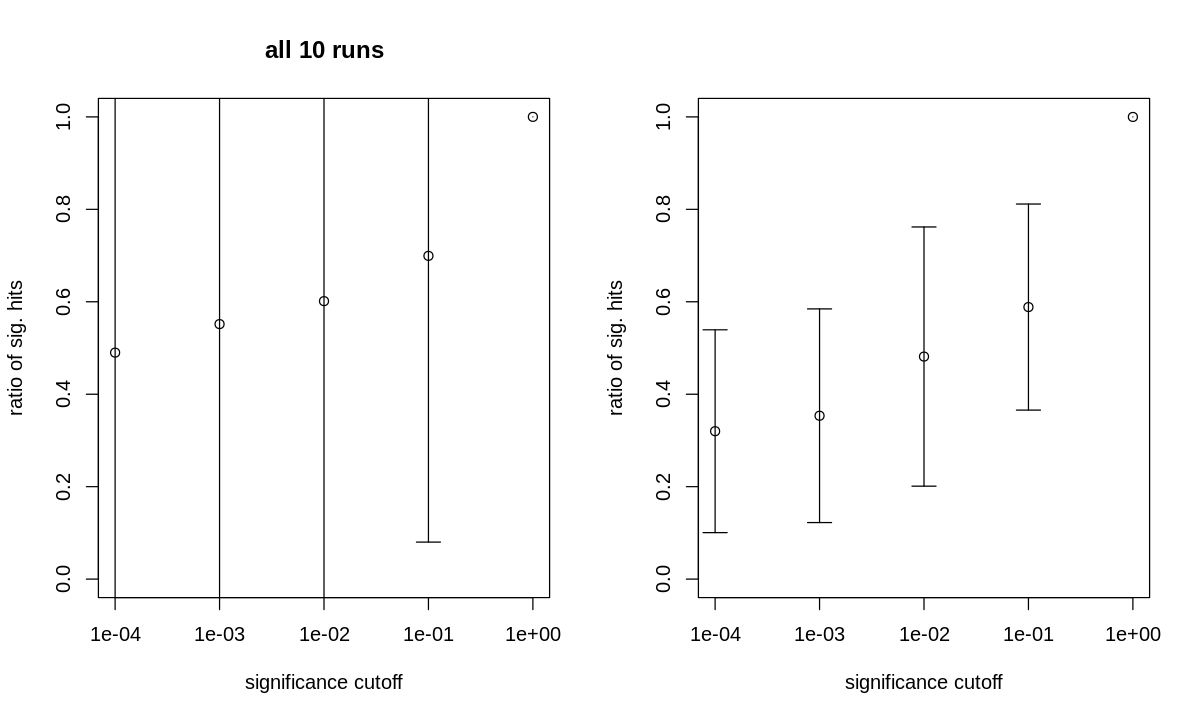

In [229]:
options(repr.plot.width = 10, repr.plot.height = 6)
par(mfrow = c(1,2))
plot(10^seq(-4,0,1),FDR_mlm_avg,ylim = c(0,1),log = 'x',
     xlab = "significance cutoff",ylab = "ratio of sig. hits",main = "all 10 runs")
arrows(x0 = 10^seq(-4,0,1),x1 = 10^seq(-4,0,1),
       y0 = FDR_mlm_avg - FDR_mlm_sd,y1 = FDR_mlm_avg + FDR_mlm_sd,
       angle = 90,length = .1,code = 3)
plot(10^seq(-4,0,1),FDR_mlm_avg_noOL,ylim = c(0,1),log = 'x',
     xlab = "significance cutoff",ylab = "ratio of sig. hits",main ="")
arrows(x0 = 10^seq(-4,0,1),x1 = 10^seq(-4,0,1),
       y0 = FDR_mlm_avg_noOL - FDR_mlm_sd_noOL,y1 = FDR_mlm_avg_noOL + FDR_mlm_sd_noOL,
       angle = 90,length = .1,code = 3)

In [423]:
dim(mergedPval_envPC1)

[1] 18017    12

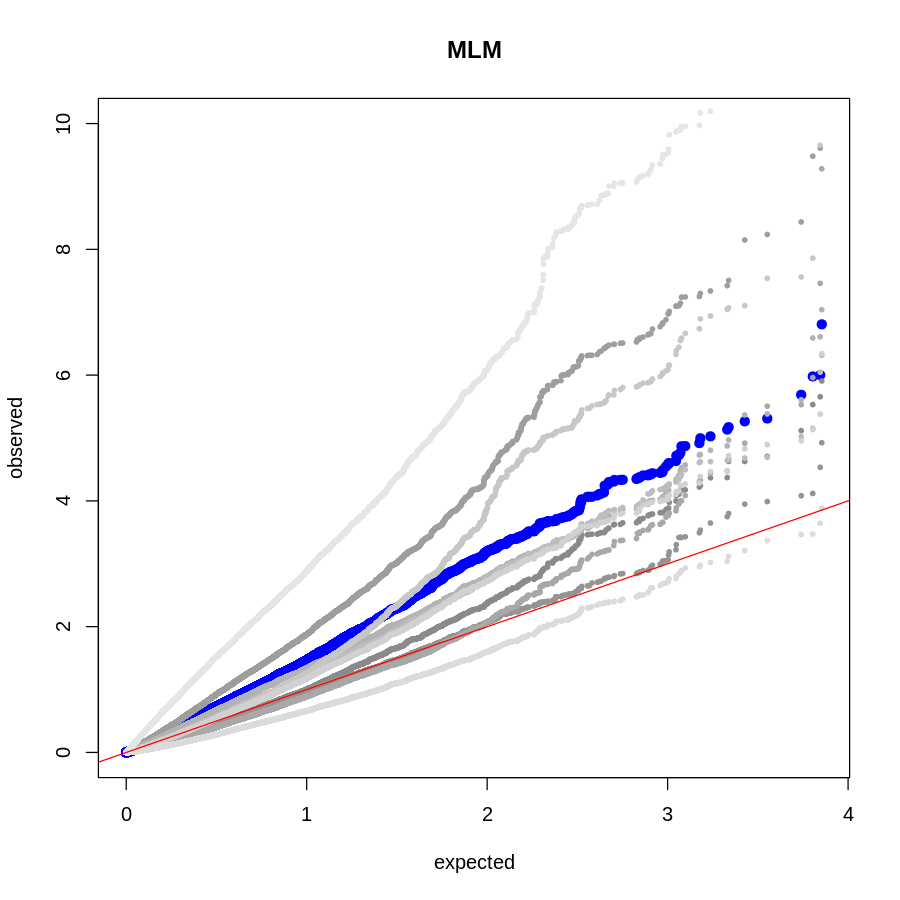

In [337]:
options(repr.plot.width = 7.5, repr.plot.height = 7.5)
set.seed(77777)
rExpectation = sort(-log10(runif(0,1,n = nrow(mergedPval_envPC1))))
sortedlogP = sort(-log10(mergedPval_envPC1$p))
sortedP = sort(mergedPval_envPC1$p)
plot(rExpectation,sort(-log10(mergedPval_envPC1$p)),
     pch = 19,xlab = "expected",ylab = "observed",col = "blue", main = "MLM",ylim = c(0,10))
for(i in 1:10){
    points(rExpectation,sort(-log10(mergedPval_envPC1[,i+2])),pch = 19,col =paste0("grey",50+i*4),cex =.5)
    sortedlogP = cbind(sortedlogP,sort(-log10(mergedPval_envPC1[,i+2])))
    sortedP = cbind(sortedP,sort(mergedPval_envPC1[,i+2]))
}

abline (a = 0,b= 1,col ="red")

In [309]:
logP_avg = apply(sortedlogP[,-1],1,median)
logP_se = apply(sortedlogP[,-1],1,sd)/sqrt(ncol(sortedlogP))

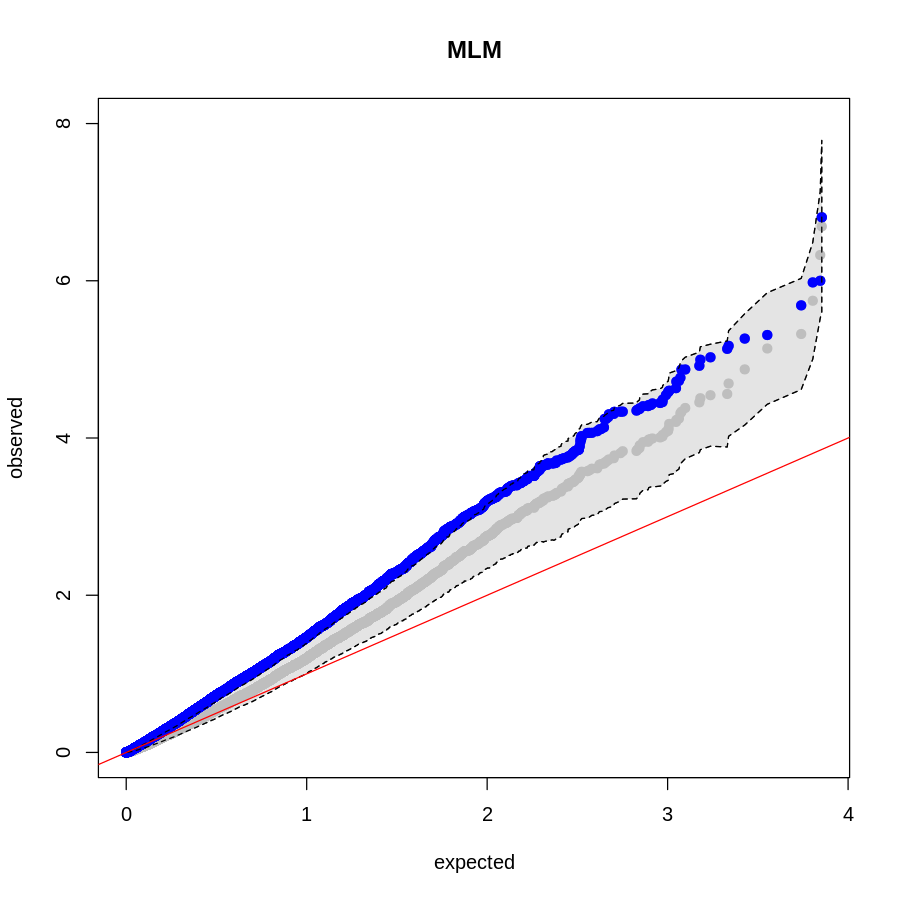

In [336]:
set.seed(77777)
rExpectation = sort(-log10(runif(0,1,n = nrow(mergedPval_envPC1))))

plot(rExpectation,sort(-log10(mergedPval_envPC1$p)),ylim = c(0,8),
     pch = 19,xlab = "expected",ylab = "observed",col = "blue", main = "MLM")
polygon(x = c(rExpectation,rev(rExpectation)),
        y =c(logP_avg+logP_se,rev(logP_avg-logP_se)),
        border = "grey30",col = alpha("grey80",.5),lty =2)
points(rExpectation,logP_avg,col = "grey", pch = 19)
points(rExpectation,sort(-log10(mergedPval_envPC1$p)),col = "blue",pch = 19)
polygon(x = c(rExpectation,rev(rExpectation)),
        y =c(logP_avg+logP_se,rev(logP_avg-logP_se)),
        border = "black",col = NA,lty =2)
abline(a = 0, b= 1, col = "red")


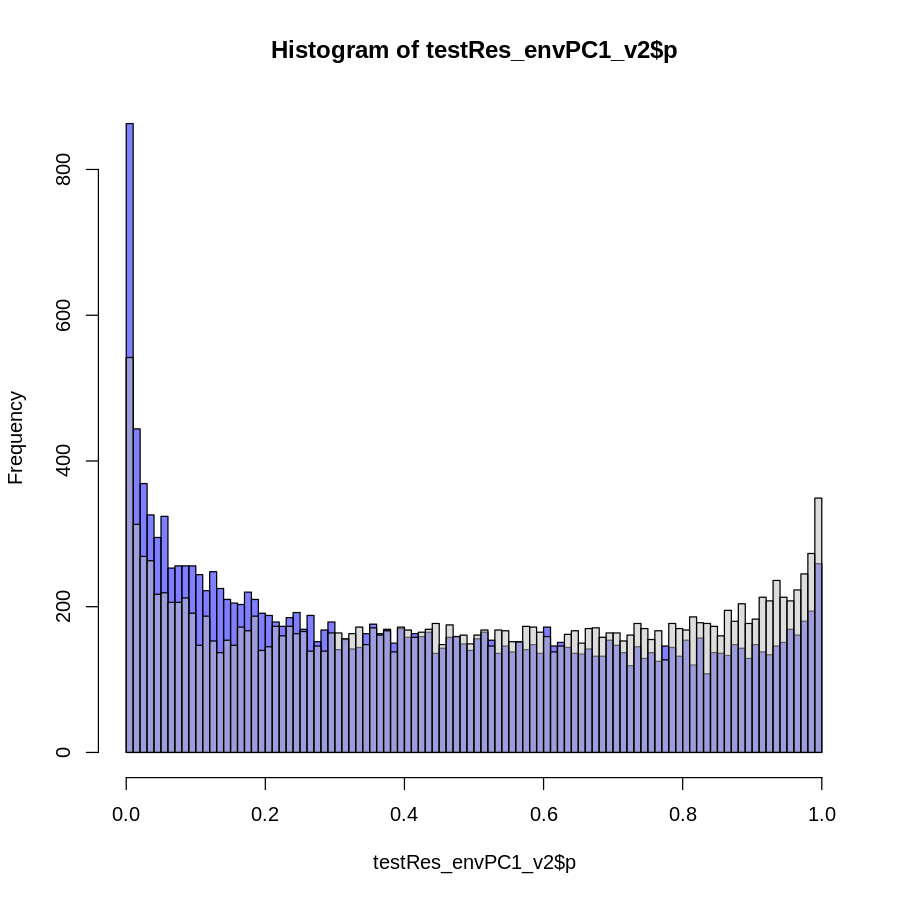

In [346]:
hist(testRes_envPC1_v2$p, col = alpha("blue",.5),breaks = seq(0,1,0.01))
hist(apply(sortedP,1,median), col = alpha("grey",.5),add = T,breaks = seq(0,1,0.01))

In [244]:
p_cut = apply(mergedPval_envPC1[,-1],2,function(x) table(cut(x,breaks = c(0,1e-5,1e-4,5e-4,1e-3,5e-3,1e-2,1))))

In [340]:
avg_count = apply(p_cut[,-1],1,median)
sd_count = apply(p_cut[,-1],1,sd)/sqrt(10)

In [341]:
avg_count

(0,1e-05]  (1e-05,0.0001] (0.0001,0.0005]  (0.0005,0.001]   (0.001,0.005] 
            4.5            20.0            50.5            51.5           208.5 
   (0.005,0.01]        (0.01,1] 
          176.5         17498.0

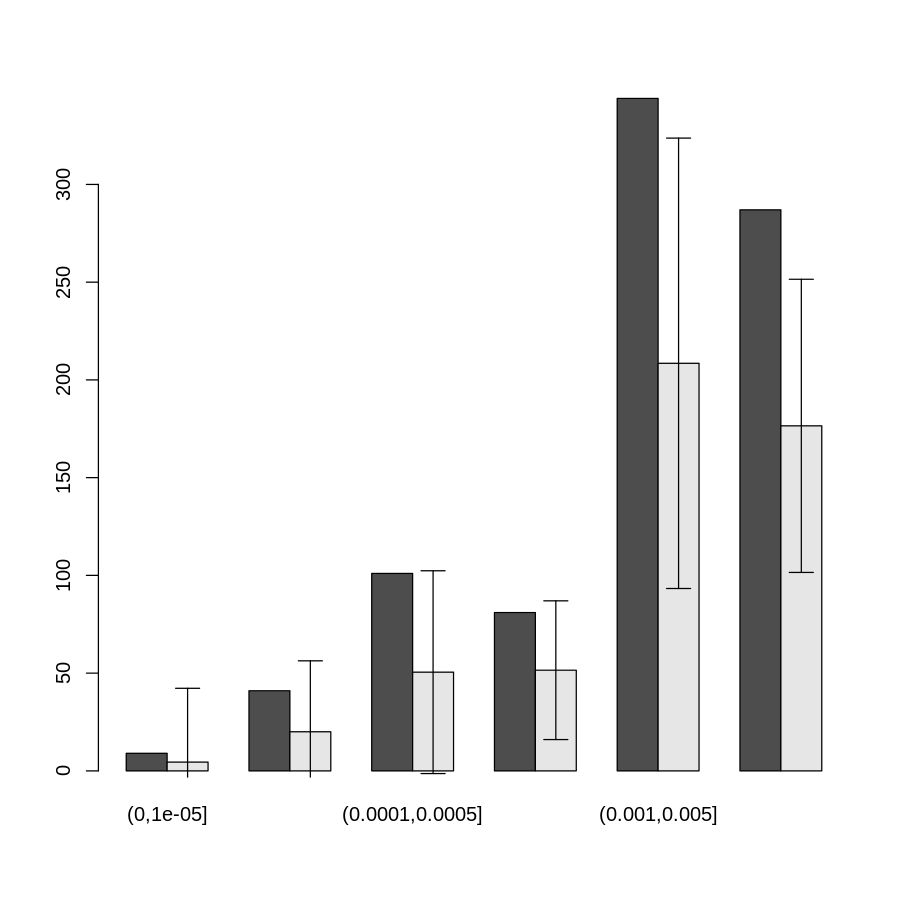

In [342]:
bp = barplot(rbind(p_cut[1:6,1],avg_count[1:6]),beside = T)
arrows(x0 = bp[2,],x1 = bp[2,],y0 = avg_count[1:6]-sd_count[1:6],y1 = avg_count[1:6]+sd_count[1:6],
       code = 3, length = .1, angle = 90)

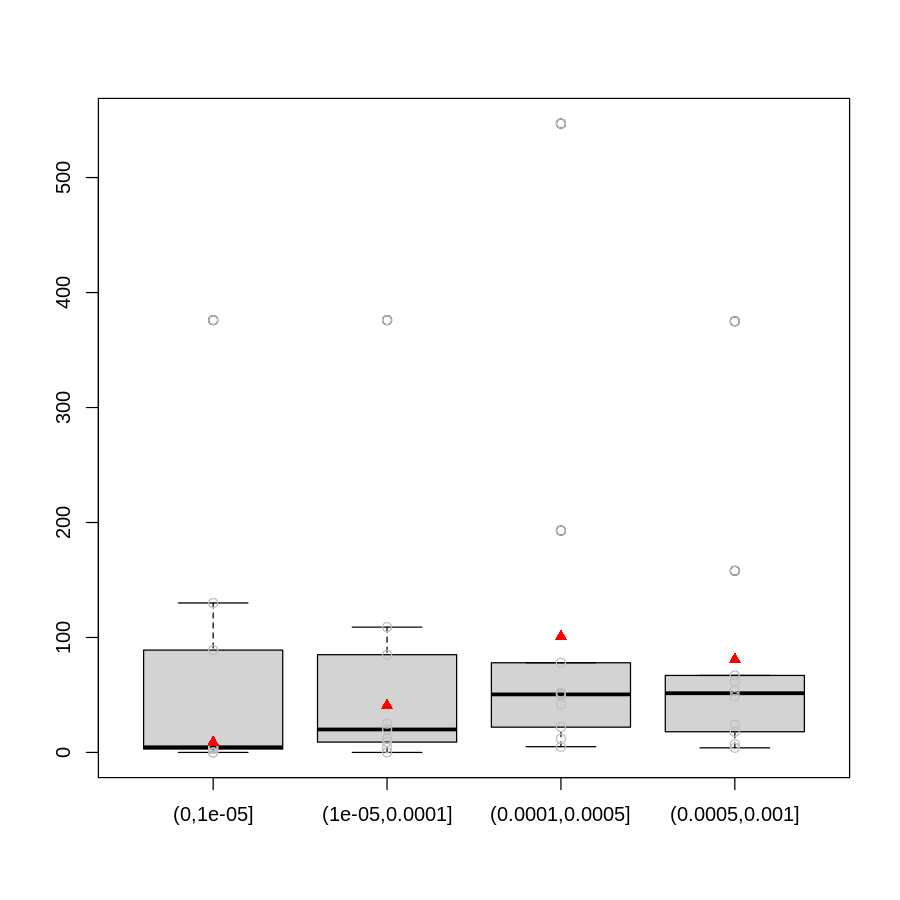

In [322]:
boxplot(t(p_cut[1:4,-1]))
points(rep(1:4,10),p_cut[1:4,-1],pch = 1,col = "grey")
points(1:4,p_cut[1:4,1],pch = 17,col = "red")

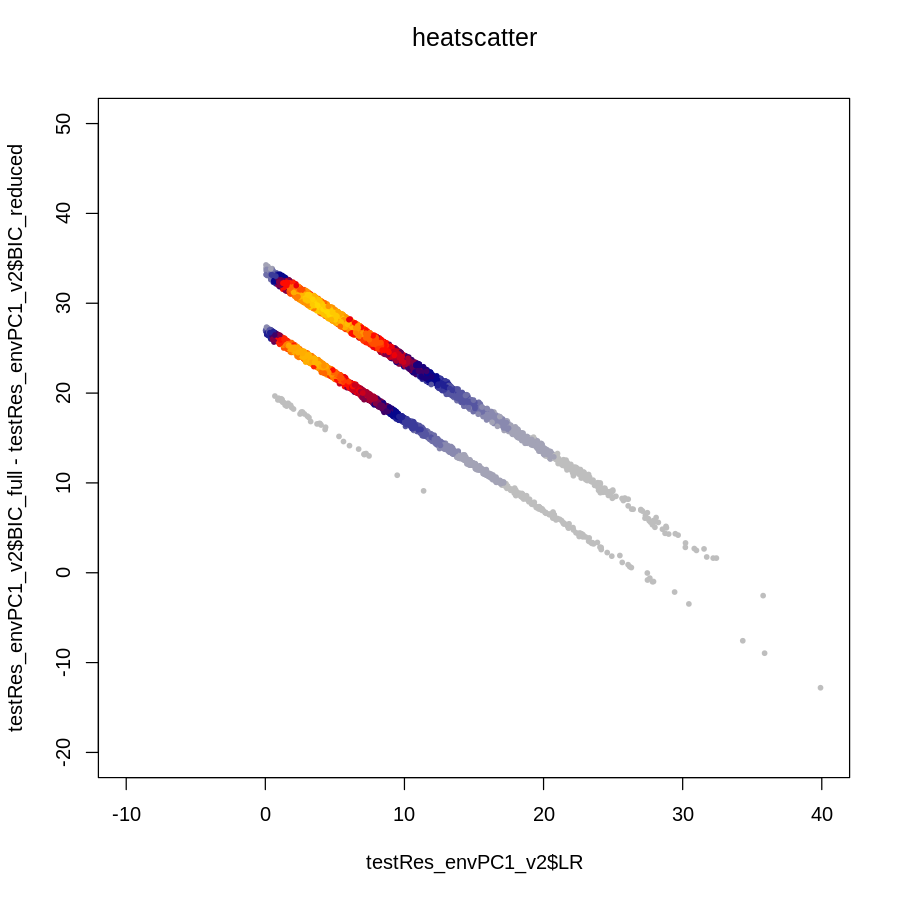

In [349]:
LSD::heatscatter(testRes_envPC1_v2$LR,testRes_envPC1_v2$BIC_full-testRes_envPC1_v2$BIC_reduced,xlim = c(-10,40),ylim = c(-20,50))

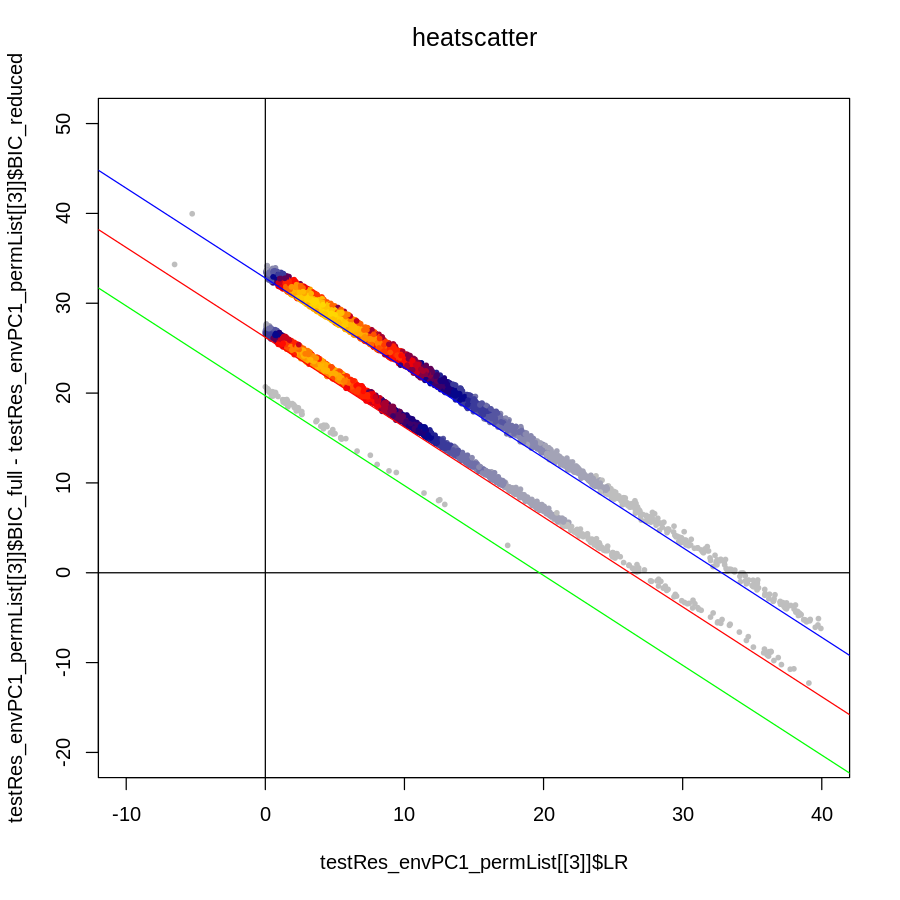

In [375]:
LSD::heatscatter(testRes_envPC1_permList[[3]]$LR,
                 testRes_envPC1_permList[[3]]$BIC_full-testRes_envPC1_permList[[3]]$BIC_reduced,
                 xlim = c(-10,40),ylim = c(-20,50))
abline(h = 0, v =0)
abline(a =32.8, b= -1,col = "blue")
abline(a =26.2, b= -1,col = "red")
abline(a =19.7, b= -1,col = "green")

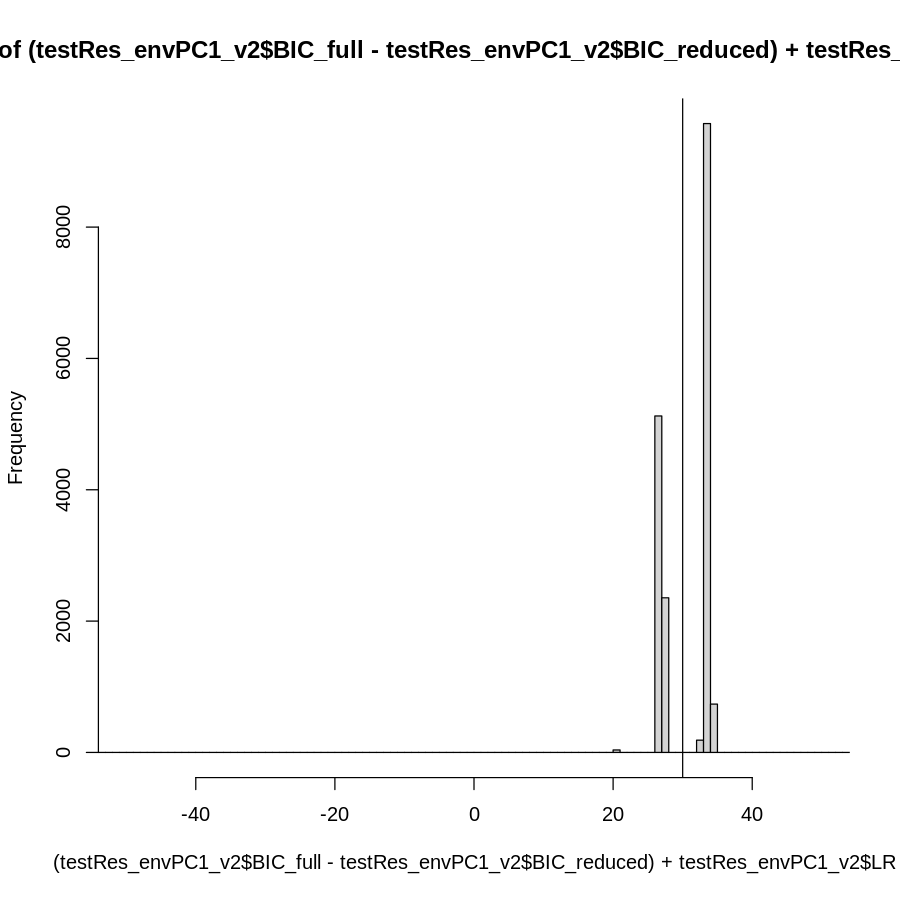

In [370]:
hist((testRes_envPC1_v2$BIC_full-testRes_envPC1_v2$BIC_reduced)+testRes_envPC1_v2$LR,
     breaks = seq(-500,5000,1),xlim = c(-50,50))
abline(v = 30)

In [383]:
obs_group = cut((testRes_envPC1_v2$BIC_full-testRes_envPC1_v2$BIC_reduced)+testRes_envPC1_v2$LR,breaks = c(0,24,30,100),labels = 3:5)


In [387]:
as.numeric(as.character(obs_group))

[1] 5 5 4 5 5 4 4 5 5 4 5 5 4 5 4 5 5 5 5 4 4 5 5 5 5 5 4 5 4 5 5 5 5 5 5 5
   [37] 5 4 5 5 5 4 5 5 5 5 5 5 5 4 4 5 5 5 5 4 5 5 4 5 5 4 5 5 5 4 4 4 4 5 4 5
   [73] 4 4 5 4 4 4 5 5 4 5 5 5 4 5 5 5 5 5 5 4 5 4 4 4 4 5 5 5 4 4 5 5 5 5 5 4
  [109] 5 5 4 5 4 5 4 4 4 5 5 5 5 5 4 5 5 5 5 5 5 4 5 5 5 5 5 4 4 5 4 5 5 5 5 4
  [145] 4 4 5 5 5 4 4 4 5 5 4 4 5 5 5 5 5 5 5 5 5 5 4 4 4 5 5 5 5 5 4 5 4 4 5 4
  [181] 5 5 4 4 5 4 5 5 5 5 5 5 4 4 5 5 4 4 4 5 4 4 5 5 4 5 5 4 4 5 5 5 5 4 4 5
  [217] 5 4 4 4 5 5 5 4 5 5 5 5 5 5 4 5 4 4 5 5 5 5 4 4 5 5 5 5 4 5 5 5 4 4 5 4
  [253] 4 5 5 5 5 5 5 5 5 4 5 5 4 5 5 4 4 4 5 5 5 5 4 5 4 4 4 4 5 5 4 5 5 4 5 4
  [289] 5 4 4 4 5 5 4 5 5 4 5 5 5 5 5 4 5 5 5 5 5 4 4 4 5 5 4 5 4 5 4 4 5 4 5 4
  [325] 5 5 4 4 4 4 5 4 4 4 5 5 5 5 5 4 4 4 5 4 4 4 4 5 4 4 4 4 5 5 4 5 5 4 5 4
  [361] 5 5 5 5 5 5 5 5 4 5 4 4 4 4 5 4 4 4 4 4 5 5 4 4 4 5 4 5 5 4 5 4 4 4 5 5
  [397] 4 4 4 5 4 5 4 4 5 4 4 4 5 5 4 5 5 5 5 4 5 5 4 5 5 5 5 4 4 4 4 5 5 5 5 4
  [433] 4 4 5 4 4 4 5 5 5 4 5 4 4 5 4 5 4 4 4 4 5 4 5 5 5 5 4 5 4 5 5 5 4 5 4 4
  [469] 4 5 5 5 5 5 4 4 5 5 5 4 4 4 5 4 4 5 4 4 4 4 4 5 4 5 4 5 4 4 4 5 4 4 4 4
  [505] 4 5 4 5 5 5 5 5 4 4 4 4 5 5 4 5 5 5 5 5 4 4 5 4 5 4 5 4 4 4 5 5 5 4 5 4
  [541] 4 5 4 4 5 4 5 5 4 4 5 4 4 4 5 4 5 5 5 5 4 4 4 5 5 4 5 4 5 5 4 5 5 3 5 5
  [577] 5 5 4 5 5 4 5 4 5 5 5 4 5 5 4 4 5 4 4 4 5 4 4 5 5 5 5 5 4 4 5 5 4 5 5 5
  [613] 4 5 4 5 5 5 5 4 5 5 4 5 5 4 4 4 5 5 5 5 5 5 5 5 4 4 5 5 4 4 4 5 4 4 5 4
  [649] 5 4 4 5 4 5 5 5 4 4 4 4 5 5 5 4 4 5 5 5 5 4 4 5 5 4 4 5 4 4 4 4 4 4 5 5
  [685] 4 4 4 5 4 4 4 5 4 4 5 5 5 4 5 5 4 5 5 4 4 4 4 4 5 5 4 4 5 4 5 5 5 4 4 5
  [721] 4 5 5 5 4 4 5 5 5 4 5 5 5 4 5 5 4 5 4 5 5 5 5 5 4 5 4 4 5 4 4 4 5 5 4 4
  [757] 5 5 4 5 5 4 5 4 4 5 5 4 4 4 4 4 4 5 5 4 4 4 4 5 4 5 4 4 5 4 4 4 4 4 4 4
  [793] 4 4 5 4 5 4 4 4 5 4 5 4 4 4 5 5 5 5 4 4 5 4 4 4 4 4 4 5 4 5 4 4 4 5 5 4
  [829] 5 4 4 5 4 4 4 4 4 4 5 4 4 5 5 4 4 4 5 5 5 4 4 4 4 4 5 4 4 5 4 4 4 4 5 5
  [865] 4 4 5 5 4 4 5 4 4 4 5 4 4 4 4 5 4 5 4 5 5 4 4 5 5 5 5 4 4 4 4 4 4 5 5 4
  [901] 4 4 5 5 4 5 5 4 5 5 4 4 5 4 5 4 4 4 4 5 5 4 4 5 5 4 4 5 5 4 4 4 4 4 4 4
  [937] 4 4 5 4 5 4 4 4 4 4 5 5 4 4 5 5 5 4 5 5 4 4 4 5 4 5 4 4 4 4 5 4 4 4 5 4
  [973] 4 5 5 4 4 4 4 5 4 5 5 4 5 4 4 4 4 5 5 4 4 4 4 4 5 4 5 4 5 4 4 5 4 4 4 5
 [1009] 5 4 4 4 4 4 4 5 4 4 4 4 4 4 4 4 4 5 5 4 5 4 5 5 5 4 5 4 4 5 5 5 5 4 5 4
 [1045] 4 4 4 5 4 4 4 4 5 4 4 4 5 4 4 4 4 4 5 5 4 4 4 4 4 5 4 5 5 5 4 4 4 4 5 5
 [1081] 4 5 5 5 4 4 5 4 5 4 4 5 4 4 5 4 4 4 5 4 5 4 4 4 5 4 5 5 5 5 5 5 5 5 5 5
 [1117] 4 5 4 4 4 4 4 4 5 4 5 4 4 4 5 4 4 5 4 5 4 5 5 5 4 4 4 4 4 4 5 4 4 5 4 5
 [1153] 4 4 4 5 4 4 4 4 4 4 4 4 3 4 5 5 5 4 4 4 4 4 4 4 5 4 4 4 4 5 4 5 5 5 4 4
 [1189] 4 4 4 4 5 4 4 5 4 5 4 4 4 4 5 4 4 5 5 5 5 4 4 4 4 4 4 4 5 4 4 4 5 4 4 4
 [1225] 4 4 4 4 4 4 4 5 4 4 5 4 4 4 4 4 4 4 5 4 4 5 5 4 4 5 5 5 4 5 4 5 4 4 5 4
 [1261] 5 5 4 5 5 4 4 5 4 4 4 5 4 4 5 4 4 4 5 4 4 5 5 5 5 5 4 5 4 4 5 5 4 4 4 5
 [1297] 4 4 4 5 5 4 5 5 4 4 5 5 5 4 4 4 5 4 4 4 4 5 4 4 5 4 5 4 5 5 5 4 4 4 4 4
 [1333] 5 4 4 4 5 5 4 4 4 5 4 4 4 4 5 5 4 4 5 4 4 5 4 4 5 5 4 4 5 4 4 5 4 4 4 5
 [1369] 5 4 4 5 4 4 5 5 4 4 5 4 5 5 4 4 5 4 5 4 4 4 4 4 4 4 4 4 4 4 5 4 4 4 4 4
 [1405] 5 5 4 4 5 5 4 5 4 4 5 5 4 5 4 4 4 4 5 4 4 4 5 4 4 4 5 4 5 4 4 4 5 5 4 5
 [1441] 5 5 4 4 5 4 4 5 5 4 5 5 5 4 5 4 4 4 5 5 4 5 5 4 5 5 4 4 4 4 5 5 4 5 5 5
 [1477] 5 5 5 4 4 5 5 4 5 5 5 5 4 4 4 4 5 4 4 4 4 5 4 4 4 4 4 5 5 5 4 5 4 5 4 4
 [1513] 5 5 4 4 4 4 4 4 4 5 3 4 4 5 4 4 4 4 4 4 5 5 4 5 5 5 4 5 5 4 4 5 4 5 4 5
 [1549] 4 4 5 4 5 5 5 4 4 4 4 5 5 4 5 5 4 4 4 4 4 4 4 5 5 4 4 4 5 5 5 5 4 4 5 4
 [1585] 5 5 3 4 4 4 5 4 4 5 4 5 4 4 5 4 5 5 4 4 4 4 5 4 4 4 4 4 4 4 5 4 4 4 5 4
 [1621] 4 4 4 4 5 4 4 5 5 4 4 4 5 5 5 4 4 4 4 4 4 5 4 4 5 4 5 5 4 4 5 5 4 4 4 5
 [1657] 4 4 5 5 4 4 4 5 5 5 4 5 4 4 4 4 5 5 4 4 4 4 5 5 4 4 5 4 4 4 5 4 5 5 4 5
 [1693] 4 4 4 4 4 4 5 5 5 4 5 4 5 4 4 5 4 5 5 4 5 5 4 4 4 4 4 4 4 4 4 4 4 5 5 5
 [1729] 5 5 4 5 5 4 5 4 5 4 4 5 5 4 5 5 4 5 4 5 5 5 5 4 5 5 4 4 4 4 5 5 4 5 4 5
 [1765] 4 4 4 5 4 4 4 4 4 4 4 4 4 5 4 5 5 5 4 4 4 4 4 5 5 4 4 5 4 4 5 4 4 5 5 4
 [18

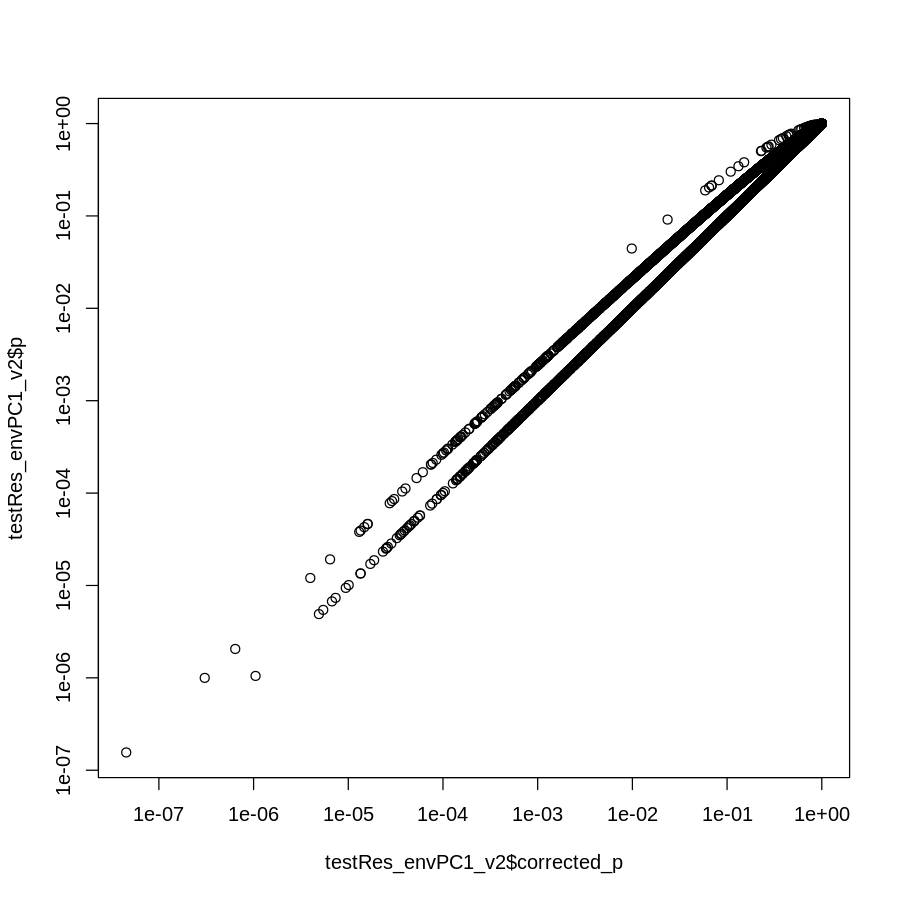

In [392]:
testRes_envPC1_v2$corrected_p = pchisq(testRes_envPC1_v2$LR, df = as.numeric(as.character(obs_group)), lower.tail = FALSE)
plot(testRes_envPC1_v2$corrected_p,testRes_envPC1_v2$p,log = 'xy')

In [395]:
for(i in 1:10){
    tmp_group = cut((testRes_envPC1_permList[[i]]$BIC_full-testRes_envPC1_permList[[i]]$BIC_reduced)+testRes_envPC1_permList[[i]]$LR,breaks = c(0,24,30,100),labels = 3:5)
    testRes_envPC1_permList[[i]]$corrected_p = pchisq(testRes_envPC1_permList[[i]]$LR, df = as.numeric(as.character(tmp_group)), lower.tail = FALSE)
}

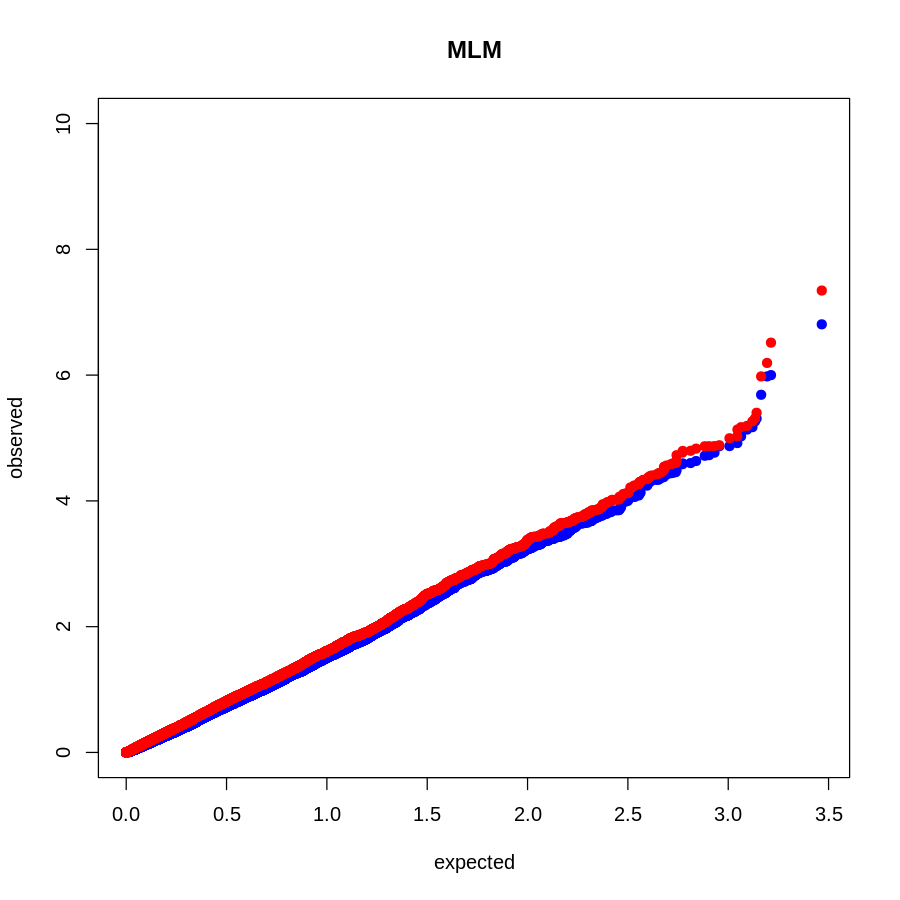

In [398]:
set.seed(1234)
plot(sort(-log10(runif(0,1,n = nrow(testRes_envPC1_v2)))),
     sort(-log10(as.numeric(testRes_envPC1_v2$p))),
     pch = 19,xlab = "expected",ylab = "observed",col = "blue", main = "MLM",ylim = c(0,10))
set.seed(1234)
points(sort(-log10(runif(0,1,n = nrow(testRes_envPC1_v2)))),
       sort(-log10(as.numeric(testRes_envPC1_v2$corrected_p))),
       pch = 19,col = 'red')


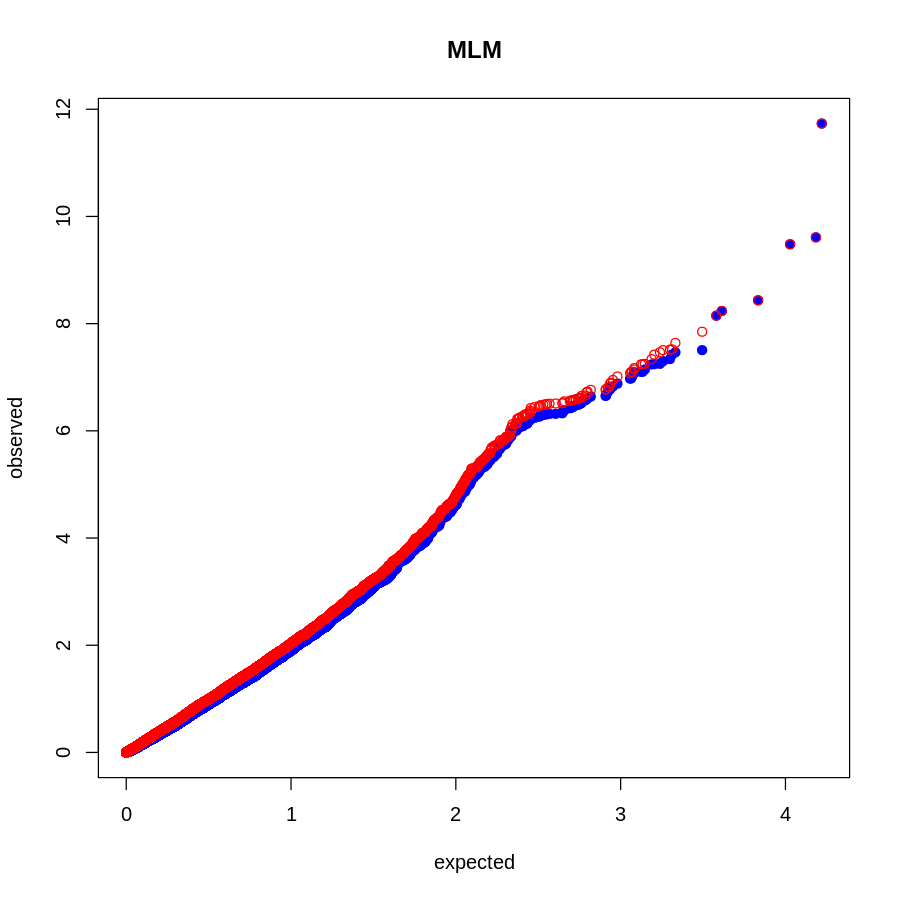

In [399]:
i = 3
set.seed(123)
plot(sort(-log10(runif(0,1,n = nrow(testRes_envPC1_permList[[i]])))),
     sort(-log10(as.numeric(testRes_envPC1_permList[[i]]$p))),
     pch = 19,xlab = "expected",ylab = "observed",col = "blue", main = "MLM")
set.seed(123)
points(sort(-log10(runif(0,1,n = nrow(testRes_envPC1_permList[[i]])))),
       sort(-log10(as.numeric(testRes_envPC1_permList[[i]]$corrected_p))),
       pch = 1,col = 'red')


In [382]:
table(cut((testRes_envPC1_permList[[10]]$BIC_full-testRes_envPC1_permList[[10]]$BIC_reduced)+testRes_envPC1_permList[[10]]$LR,breaks = c(0,24,30,100),labels = 3:5))



    3     4     5 
   62  7810 10776 

In [373]:
5*log(707)
4*log(707)
3*log(707)

[1] 32.80515

[1] 26.24412

[1] 19.68309

In [233]:
apply(mergedPval_envPC1[,-1],2,min,na.rm =T)

p     perm_p_1     perm_p_2     perm_p_3     perm_p_4     perm_p_5 
1.557523e-07 1.238910e-06 1.188639e-05 1.850850e-12 5.238488e-10 9.100882e-08 
    perm_p_6     perm_p_7     perm_p_8     perm_p_9    perm_p_10 
4.854247e-07 2.103592e-12 4.541554e-07 1.302619e-04 5.589194e-16

In [268]:
which(list.files("/workdir/sh2246/p_phyloGWAS/output/permulation/perOG/")=='ASREML_res_perm_2.txt')
which(list.files("/workdir/sh2246/p_phyloGWAS/output/permulation/perOG/")=='ASREML_res_perm_6.txt')
which(list.files("/workdir/sh2246/p_phyloGWAS/output/permulation/perOG/")=='ASREML_res_perm_9.txt')

[1] 113

[1] 557

[1] 890

In [14]:
testRes_envPC1PeOG_permList = mclapply(list.files("/workdir/sh2246/p_phyloGWAS/output/permulation/perOG/",full.names = T),
                       function(x) read.table(x,header = T),mc.cores = 20)

testRes_envPC1PeOG_permMat = sapply(testRes_envPC1PeOG_permList,function(x){
    tmp = x
    rownames(tmp) = tmp$OG
    tmp = tmp[testRes_envPC1_v2$OG[testRes_envPC1_v2$p < 0.001],]
    return(tmp[,5])
})

rownames(testRes_envPC1PeOG_permMat) = testRes_envPC1_v2$OG[testRes_envPC1_v2$p < 0.001]

testRes_envPC1PeOG_permMat = cbind(testRes_envPC1_v2$p[testRes_envPC1_v2$p < 0.001],
                                   testRes_envPC1PeOG_permMat[testRes_envPC1_v2$OG[testRes_envPC1_v2$p < 0.001],])

In [15]:
dim(testRes_envPC1PeOG_permMat)

[1]  232 1001

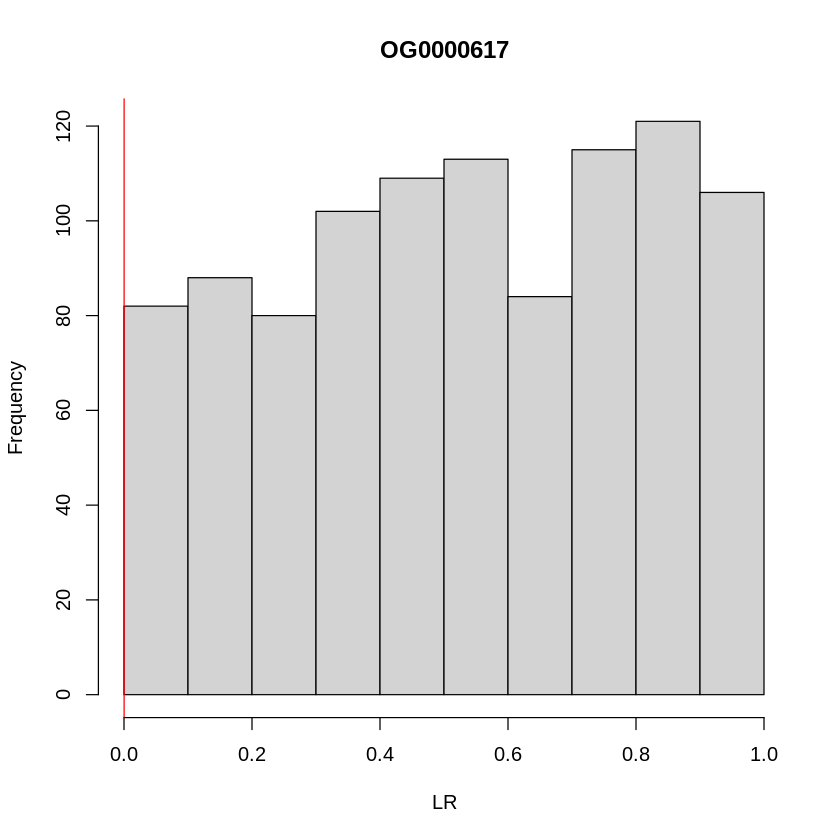

In [9]:
hist(testRes_envPC1PeOG_permMat[3,-1],xlab = "LR", main = rownames(testRes_envPC1PeOG_permMat)[3])
abline(v = testRes_envPC1PeOG_permMat[3,1],col ="red")

In [16]:
emp_p = apply(testRes_envPC1PeOG_permMat,1,function(x) sum(x[-1]<x[1],na.rm = T))/ncol(testRes_envPC1PeOG_permMat)

In [17]:
length(emp_p)

[1] 232

In [182]:
# emp_p[emp_p==0] = 1e-4

In [18]:
table(cut(emp_p,breaks = c(1,.05,.01,.005,.001,0),right = F),
      cut(testRes_envPC1PeOG_permMat[,1],breaks = c(1e-3,5e-4,1e-4,0),right = F))

               
                [0,0.0001) [0.0001,0.0005) [0.0005,0.001)
  [0,0.001)             37              41             15
  [0.001,0.005)          9              31             31
  [0.005,0.01)           2              13             14
  [0.01,0.05)            2              12             16
  [0.05,1)               0               4              5

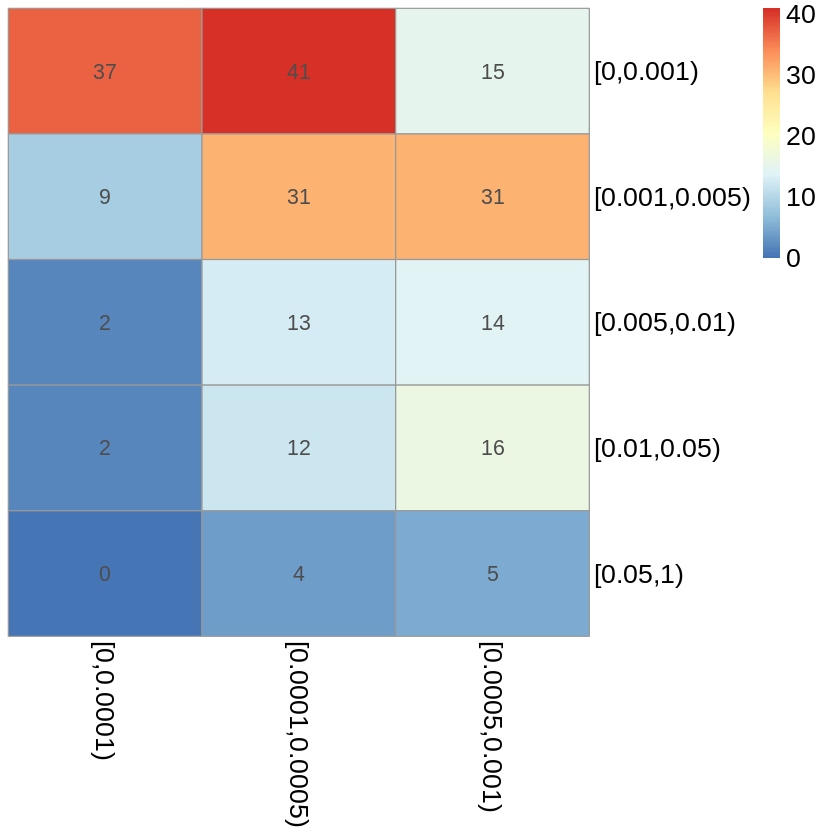

In [216]:
pheatmap(table(cut(emp_p,breaks = c(1,.05,.01,.005,.001,0),right = F),
               cut(testRes_envPC1PeOG_permMat[,1],breaks = c(1e-3,5e-4,1e-4,0),right = F)),
         cluster_row = F,cluster_col = F,display_number =T,number_format = "%1d",fontsize = 16)

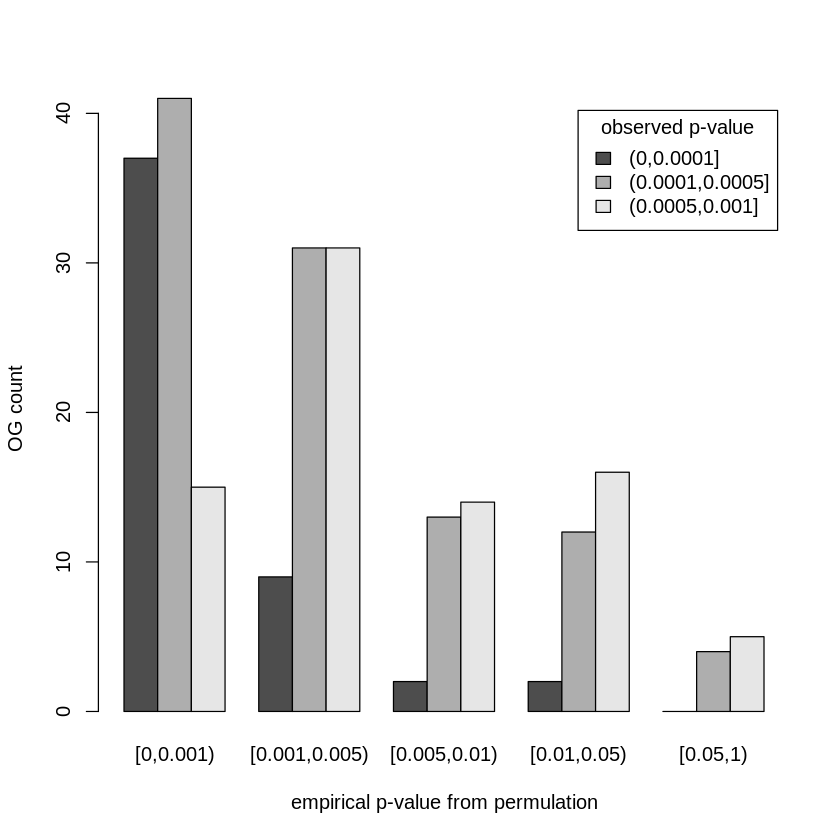

In [219]:
barplot(t(table(cut(emp_p,breaks = c(1,.05,.01,.005,.001,0),right = F),
                cut(testRes_envPC1PeOG_permMat[,1],breaks = c(1e-3,5e-4,1e-4,0),right = F))),
        beside = T,legend.text = names(table(cut(testRes_envPC1PeOG_permMat[,1],breaks = c(1e-3,5e-4,1e-4,0)))),
        args.legend = list(title = "observed p-value"),
        xlab = "empirical p-value from permulation", ylab = "OG count")

[1] 354

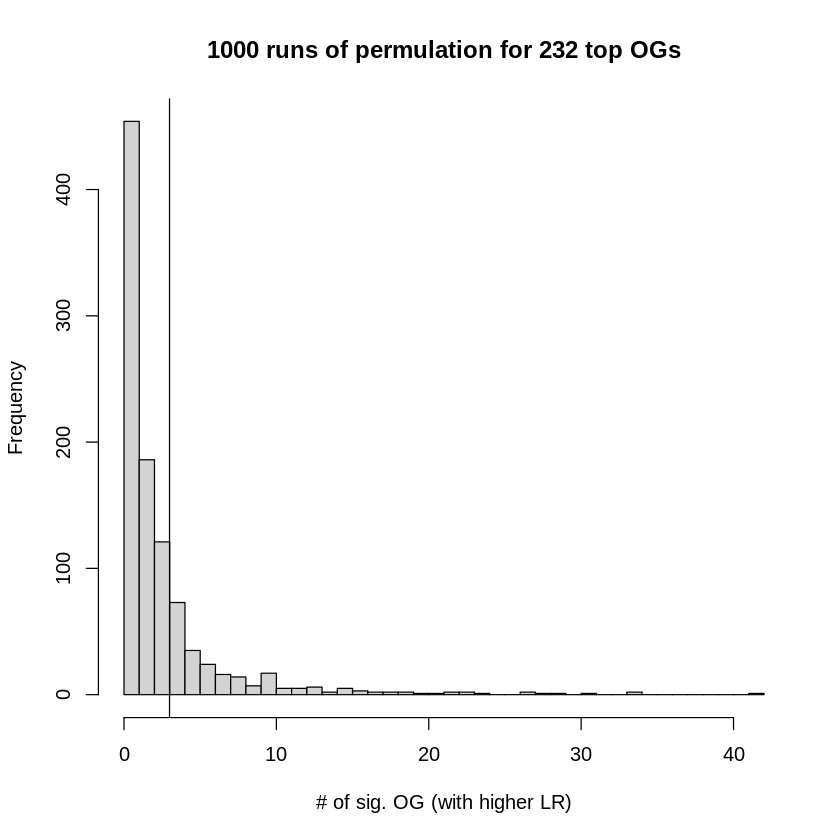

In [13]:
hist(apply(testRes_envPC1PeOG_permMat[,-1],2,function(x) sum(x<0.001)),
     xlab = "# of sig. OG (with higher LR)",main = "1000 runs of permulation for 232 top OGs",
     breaks = seq(0,42,1))
abline(v = 232/nrow(testRes_envPC1_v2)*232)
text(232/nrow(testRes_envPC1_v2)*232,800,pos = 4,"Random expectation")
sum(apply(testRes_envPC1PeOG_permMat[,-1],2,function(x) sum(x<0.001))>232/nrow(testRes_envPC1_v2)*232,na.rm = T)

In [19]:
colnames(testRes_envPC1PeOG_permMat) = c("obs",gsub(".txt","",limma::strsplit2(list.files("/workdir/sh2246/p_phyloGWAS/output/permulation/perOG/"),"_")[,4]))

In [20]:
head(testRes_envPC1PeOG_permMat)

,obs,1,10,100,1000,101,102,103,104,105,⋯,990,991,992,993,994,995,996,997,998,999
OG0000452,0.0008085743,0.2986125,0.5280809,0.3318918,0.04347742,0.9050223,0.956126032,0.2693193,0.8799569,0.281621166,⋯,0.3304181,0.7110215,0.8335940,0.78587316,0.08354412,0.8681785,0.5779152,0.5498553,0.5403857,0.2444856
OG0000535,0.0003530774,0.7204954,0.4249780,0.2329619,0.18792052,0.3329960,0.007267165,0.2200001,0.1938445,0.011598882,⋯,0.5969396,0.5116130,0.1399278,0.01861715,0.43532805,0.3770068,0.6695536,0.8014301,0.9181915,0.7591479
OG0000617,0.0001621073,0.6640254,0.7157665,0.5833582,0.85351610,0.7336062,0.992984940,0.9982691,0.8728550,0.480718201,⋯,0.9699987,0.5961723,0.9010239,0.41496296,0.19718869,0.6092327,0.5981804,0.4443691,0.5874204,0.7179173
OG0001181,0.0001374698,0.9300922,0.9251236,0.2258284,0.48703266,0.2323636,0.024700829,0.4011858,0.6198381,0.006646777,⋯,0.2474673,0.3065565,0.6758299,0.70898096,0.50296520,0.8596942,0.5712583,0.3823072,0.3288729,0.5647973
OG0001226,0.0002102966,0.9288306,0.8497984,0.8933710,0.61872212,0.4702856,0.105847773,0.1601740,0.4911162,0.651060826,⋯,0.6098613,0.4907964,0.0133388,0.39155234,0.89463031,0.2771893,0.8048227,0.5096580,0.2464621,0.4363692
OG0001269,0.0004008169,0.6844123,0.5499696,0.8151963,0.02805831,0.2911668,0.980622727,0.9907432,0.3640716,0.101522805,⋯,0.7103152,0.2442126,0.9685232,0.66289277,0.87214097,0.9651481,0.9436756,0.8746852,0.9105575,0.3561343


In [61]:
list.files("/workdir/sh2246/p_phyloGWAS/output/permulation/perOG/")

[1] "ASREML_res_perm_1.txt"    "ASREML_res_perm_10.txt"  
   [3] "ASREML_res_perm_100.txt"  "ASREML_res_perm_1000.txt"
   [5] "ASREML_res_perm_101.txt"  "ASREML_res_perm_102.txt" 
   [7] "ASREML_res_perm_103.txt"  "ASREML_res_perm_104.txt" 
   [9] "ASREML_res_perm_105.txt"  "ASREML_res_perm_106.txt" 
  [11] "ASREML_res_perm_107.txt"  "ASREML_res_perm_108.txt" 
  [13] "ASREML_res_perm_109.txt"  "ASREML_res_perm_11.txt"  
  [15] "ASREML_res_perm_110.txt"  "ASREML_res_perm_111.txt" 
  [17] "ASREML_res_perm_112.txt"  "ASREML_res_perm_113.txt" 
  [19] "ASREML_res_perm_114.txt"  "ASREML_res_perm_115.txt" 
  [21] "ASREML_res_perm_116.txt"  "ASREML_res_perm_117.txt" 
  [23] "ASREML_res_perm_118.txt"  "ASREML_res_perm_119.txt" 
  [25] "ASREML_res_perm_12.txt"   "ASREML_res_perm_120.txt" 
  [27] "ASREML_res_perm_121.txt"  "ASREML_res_perm_122.txt" 
  [29] "ASREML_res_perm_123.txt"  "ASREML_res_perm_124.txt" 
  [31] "ASREML_res_perm_125.txt"  "ASREML_res_perm_126.txt" 
  [33] "ASREML_res_perm_127.txt"  "ASREML_res_perm_128.txt" 
  [35] "ASREML_res_perm_129.txt"  "ASREML_res_perm_13.txt"  
  [37] "ASREML_res_perm_130.txt"  "ASREML_res_perm_131.txt" 
  [39] "ASREML_res_perm_132.txt"  "ASREML_res_perm_133.txt" 
  [41] "ASREML_res_perm_134.txt"  "ASREML_res_perm_135.txt" 
  [43] "ASREML_res_perm_136.txt"  "ASREML_res_perm_137.txt" 
  [45] "ASREML_res_perm_138.txt"  "ASREML_res_perm_139.txt" 
  [47] "ASREML_res_perm_14.txt"   "ASREML_res_perm_140.txt" 
  [49] "ASREML_res_perm_141.txt"  "ASREML_res_perm_142.txt" 
  [51] "ASREML_res_perm_143.txt"  "ASREML_res_perm_144.txt" 
  [53] "ASREML_res_perm_145.txt"  "ASREML_res_perm_146.txt" 
  [55] "ASREML_res_perm_147.txt"  "ASREML_res_perm_148.txt" 
  [57] "ASREML_res_perm_149.txt"  "ASREML_res_perm_15.txt"  
  [59] "ASREML_res_perm_150.txt"  "ASREML_res_perm_151.txt" 
  [61] "ASREML_res_perm_152.txt"  "ASREML_res_perm_153.txt" 
  [63] "ASREML_res_perm_154.txt"  "ASREML_res_perm_155.txt" 
  [65] "ASREML_res_perm_156.txt"  "ASREML_res_perm_157.txt" 
  [67] "ASREML_res_perm_158.txt"  "ASREML_res_perm_159.txt" 
  [69] "ASREML_res_perm_16.txt"   "ASREML_res_perm_160.txt" 
  [71] "ASREML_res_perm_161.txt"  "ASREML_res_perm_162.txt" 
  [73] "ASREML_res_perm_163.txt"  "ASREML_res_perm_164.txt" 
  [75] "ASREML_res_perm_165.txt"  "ASREML_res_perm_166.txt" 
  [77] "ASREML_res_perm_167.txt"  "ASREML_res_perm_168.txt" 
  [79] "ASREML_res_perm_169.txt"  "ASREML_res_perm_17.txt"  
  [81] "ASREML_res_perm_170.txt"  "ASREML_res_perm_171.txt" 
  [83] "ASREML_res_perm_172.txt"  "ASREML_res_perm_173.txt" 
  [85] "ASREML_res_perm_174.txt"  "ASREML_res_perm_175.txt" 
  [87] "ASREML_res_perm_176.txt"  "ASREML_res_perm_177.txt" 
  [89] "ASREML_res_perm_178.txt"  "ASREML_res_perm_179.txt" 
  [91] "ASREML_res_perm_18.txt"   "ASREML_res_perm_180.txt" 
  [93] "ASREML_res_perm_181.txt"  "ASREML_res_perm_182.txt" 
  [95] "ASREML_res_perm_183.txt"  "ASREML_res_perm_184.txt" 
  [97] "ASREML_res_perm_185.txt"  "ASREML_res_perm_186.txt" 
  [99] "ASREML_res_perm_187.txt"  "ASREML_res_perm_188.txt" 
 [101] "ASREML_res_perm_189.txt"  "ASREML_res_perm_19.txt"  
 [103] "ASREML_res_perm_190.txt"  "ASREML_res_perm_191.txt" 
 [105] "ASREML_res_perm_192.txt"  "ASREML_res_perm_193.txt" 
 [107] "ASREML_res_perm_194.txt"  "ASREML_res_perm_195.txt" 
 [109] "ASREML_res_perm_196.txt"  "ASREML_res_perm_197.txt" 
 [111] "ASREML_res_perm_198.txt"  "ASREML_res_perm_199.txt" 
 [113] "ASREML_res_perm_2.txt"    "ASREML_res_perm_20.txt"  
 [115] "ASREML_res_perm_200.txt"  "ASREML_res_perm_201.txt" 
 [117] "ASREML_res_perm_202.txt"  "ASREML_res_perm_203.txt" 
 [119] "ASREML_res_perm_204.txt"  "ASREML_res_perm_205.txt" 
 [121] "ASREML_res_perm_206.txt"  "ASREML_res_perm_207.txt" 
 [123] "ASREML_res_perm_208.txt"  "ASREML_res_perm_209.txt" 
 [125] "ASREML_res_perm_21.txt"   "ASREML_res_perm_210.txt" 
 [127] "ASREML_res_perm_211.txt"  "ASREML_res_perm_212.txt" 
 [129] "ASREML_res_perm_213.txt"  "ASREML_res_perm_214.txt" 
 [131] "ASREML_res_perm_215.txt"  "ASR

In [33]:
weirdos = which(apply(testRes_envPC1PeOG_permMat[,-1],2,function(x) sum(x<0.001))>232/nrow(testRes_envPC1_v2)*232)+1

In [117]:
weirdoFactors = as.factor(1:100%in%colnames(testRes_envPC1PeOG_permMat)[weirdos][as.numeric(colnames(testRes_envPC1PeOG_permMat)[weirdos])<101])

In [121]:
length(R2phylo_perm)

[1] 10

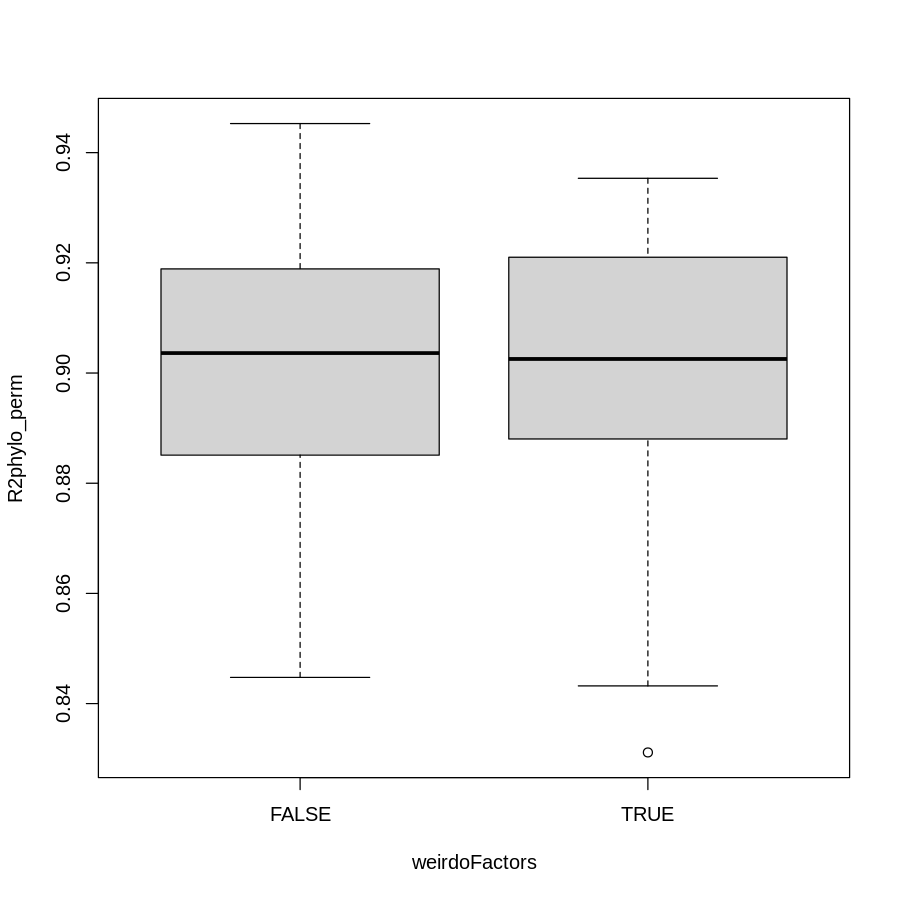

In [136]:
boxplot(R2phylo_perm~weirdoFactors)

In [113]:
1:100%in%colnames(testRes_envPC1PeOG_permMat)[weirdos][as.numeric(colnames(testRes_envPC1PeOG_permMat)[weirdos])<101]

[1] FALSE  TRUE FALSE FALSE  TRUE  TRUE FALSE FALSE  TRUE FALSE FALSE  TRUE
 [13] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE  TRUE FALSE FALSE FALSE
 [25] FALSE FALSE FALSE FALSE FALSE FALSE FALSE  TRUE FALSE  TRUE FALSE FALSE
 [37] FALSE FALSE  TRUE  TRUE  TRUE FALSE  TRUE FALSE FALSE FALSE FALSE FALSE
 [49]  TRUE FALSE FALSE FALSE FALSE FALSE  TRUE FALSE FALSE FALSE FALSE FALSE
 [61] FALSE  TRUE FALSE FALSE FALSE  TRUE FALSE  TRUE  TRUE FALSE  TRUE FALSE
 [73]  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE  TRUE FALSE  TRUE FALSE FALSE
 [85]  TRUE FALSE FALSE FALSE FALSE  TRUE  TRUE FALSE FALSE FALSE FALSE FALSE
 [97]  TRUE FALSE FALSE FALSE

In [68]:
envPC1_permMat = sapply(envPC1_perm,function(x) x[,2])

In [72]:
colnames(envPC1_permMat) = as.character(1:1000)

In [73]:
head(envPC1_permMat[,colnames(testRes_envPC1PeOG_permMat)[weirdos]])

104,112,114,119,12,120,123,128,130,131,⋯,97,970,971,979,980,981,982,989,990,997
-1.38089,1.27748,-0.05505,-0.33662,1.33645,0.22571,0.97791,1.24258,-0.34213,-1.16752,⋯,-1.44370,1.15568,1.00613,1.20029,-1.58717,-1.81960,-0.82253,1.07686,0.88567,-0.94156
-1.38505,1.26526,-0.06758,-0.24410,1.35263,0.12717,0.97074,1.25666,-0.33964,-1.25377,⋯,-1.52170,1.14279,0.99266,1.19194,-1.52736,-1.79404,-0.71024,1.09448,0.90483,-1.12206
-1.44370,1.39368,-0.20676,-0.28422,1.27748,0.21609,0.99266,1.31534,-0.51013,-1.01943,⋯,-1.62508,1.09051,1.09051,1.09570,-1.68439,-1.85042,-0.61143,1.09051,0.93877,-0.81211
-1.44370,1.36725,-0.20387,-0.25455,1.12069,0.21093,0.92891,1.31271,-0.28992,-1.02005,⋯,-1.65798,1.09248,1.09570,0.99538,-1.65887,-1.85570,-0.54287,1.03104,0.78644,-0.81211
-1.47068,1.42197,-0.22386,-0.31236,1.02230,0.22112,0.93877,1.33645,-0.53629,-1.15057,⋯,-1.53132,1.04798,1.09662,0.93605,-1.62771,-1.82137,-0.64790,1.05877,0.85509,-0.51013
-1.65798,1.24258,0.46482,-0.34213,0.39290,-1.06868,0.93605,1.31943,-0.78720,-0.84115,⋯,-1.94557,0.92737,1.17806,1.09662,-1.80899,-1.66241,-1.37467,1.09248,1.00613,-0.55611


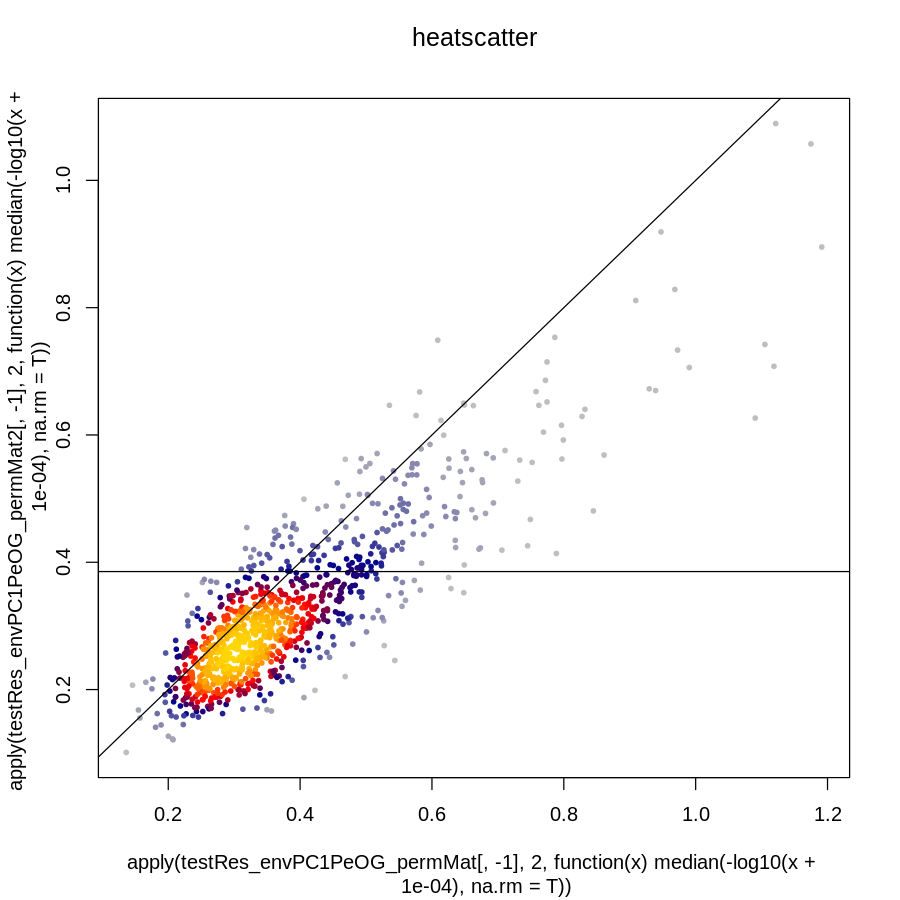

In [69]:
LSD::heatscatter(apply(testRes_envPC1PeOG_permMat[,-1],2,function(x) median(-log10(x+1e-4),na.rm = T)),
     apply(testRes_envPC1PeOG_permMat2[,-1],2,function(x) median(-log10(x+1e-4),na.rm = T)))
abline(a = 0,b =1)
abline(h = median(-log10(testRes_envPC1PeOG_permMat2[,1]+1e-4)))

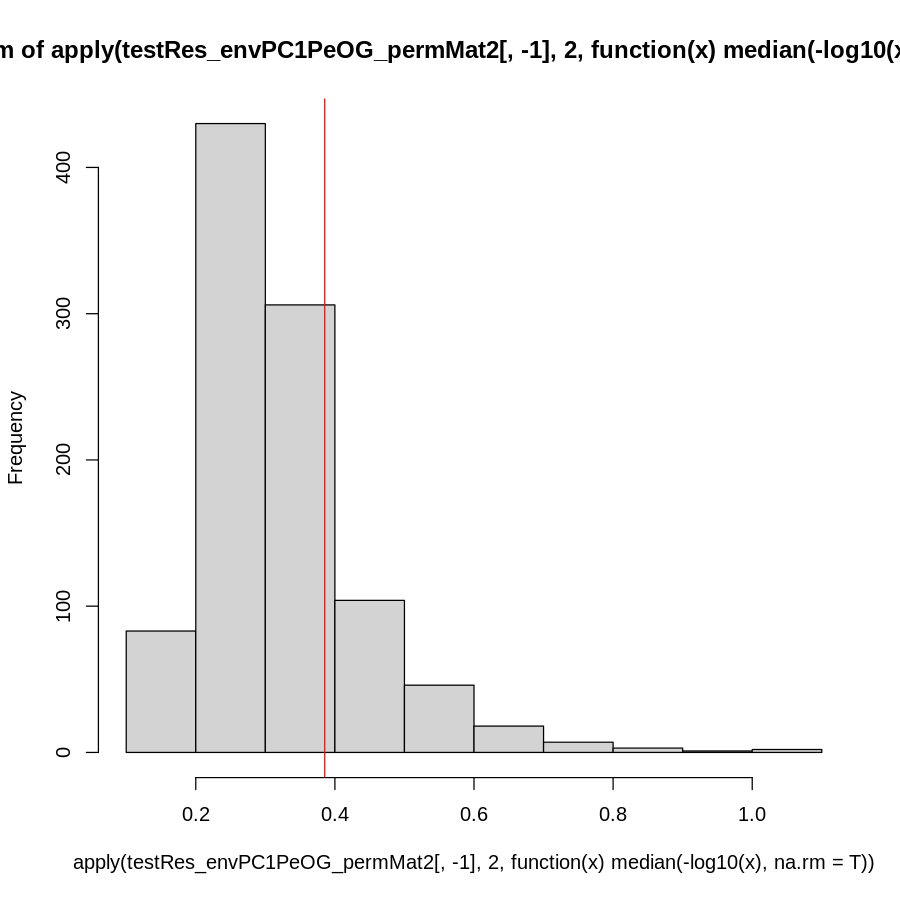

In [73]:
hist(apply(testRes_envPC1PeOG_permMat2[,-1],2,function(x) median(-log10(x),na.rm = T)))
abline(v = median(-log10(testRes_envPC1PeOG_permMat2[,1]+1e-4)),col = "red")

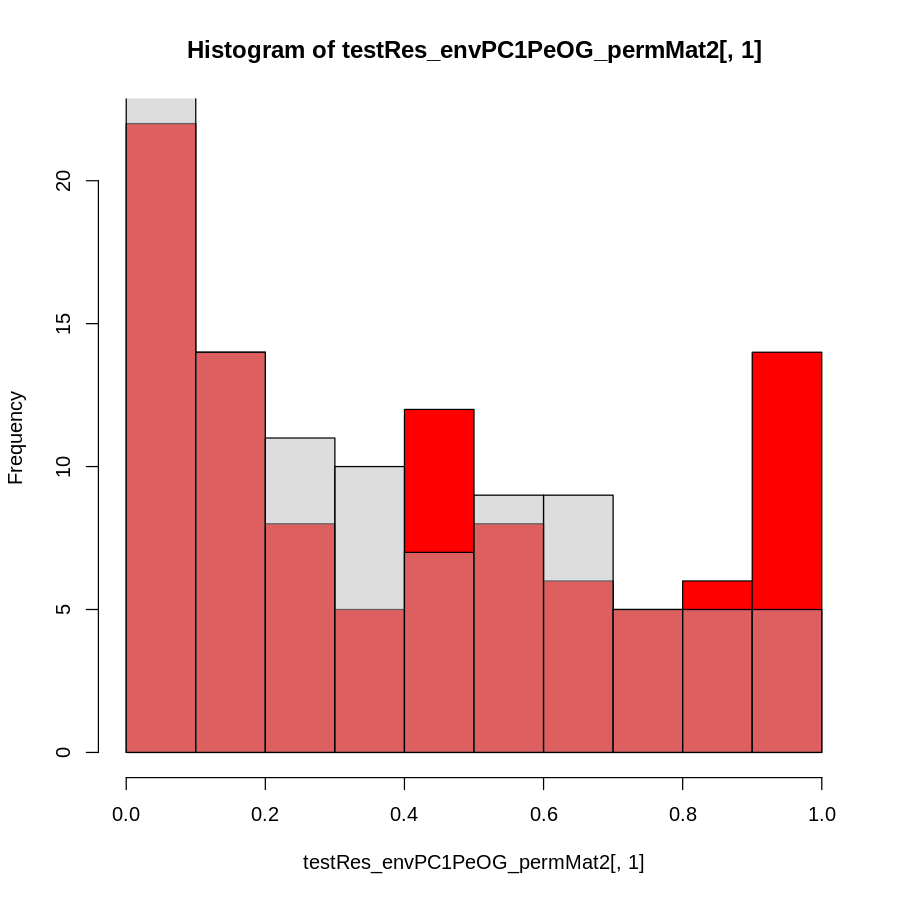

In [77]:
hist(testRes_envPC1PeOG_permMat2[,1],col = "red")
hist(testRes_envPC1PeOG_permMat2[,114],add = T,col = scales::alpha("grey",.5))

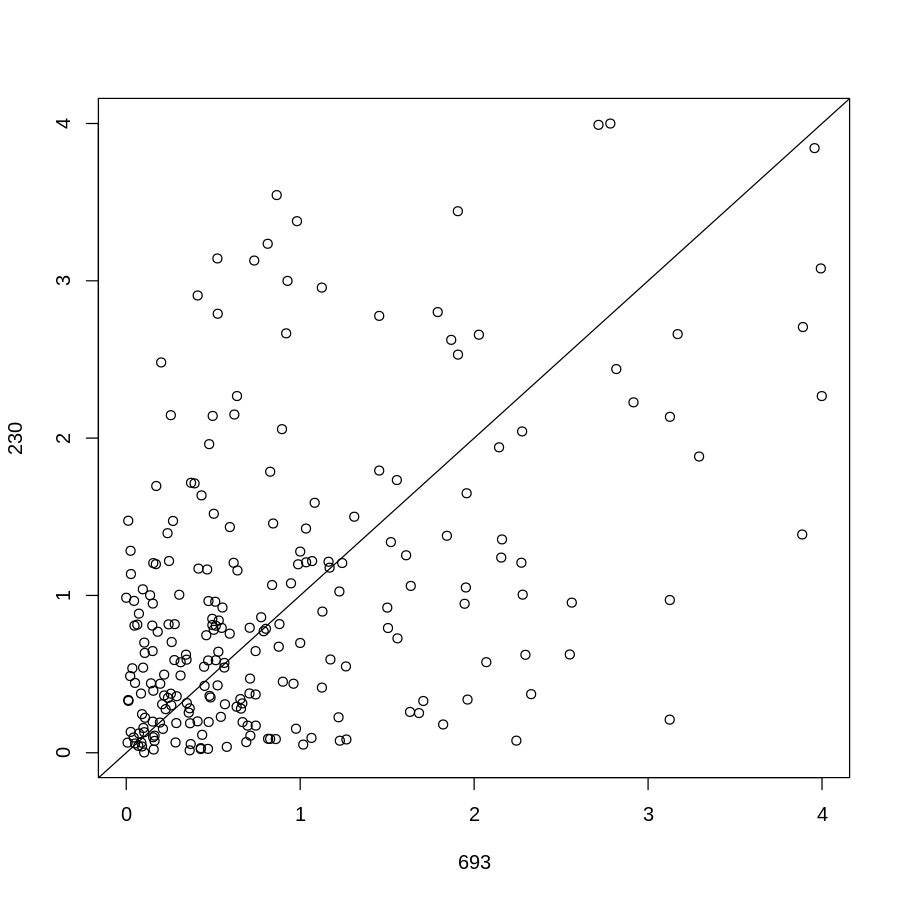

In [34]:
plot(-log10(testRes_envPC1PeOG_permMat[,sample(weirdos,2)]+1e-4))
abline(a = 0,b =1)

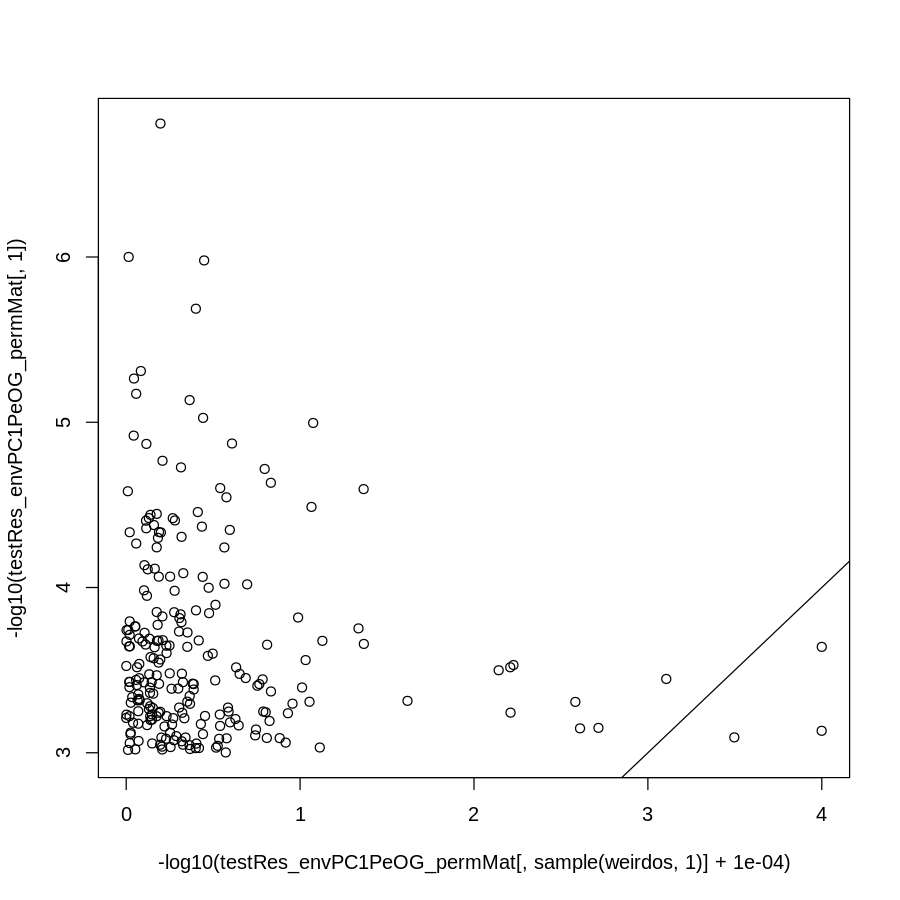

In [47]:
plot(-log10(testRes_envPC1PeOG_permMat[,sample(weirdos,1)]+1e-4),
    -log10(testRes_envPC1PeOG_permMat[,1]))
abline(a = 0,b =1)

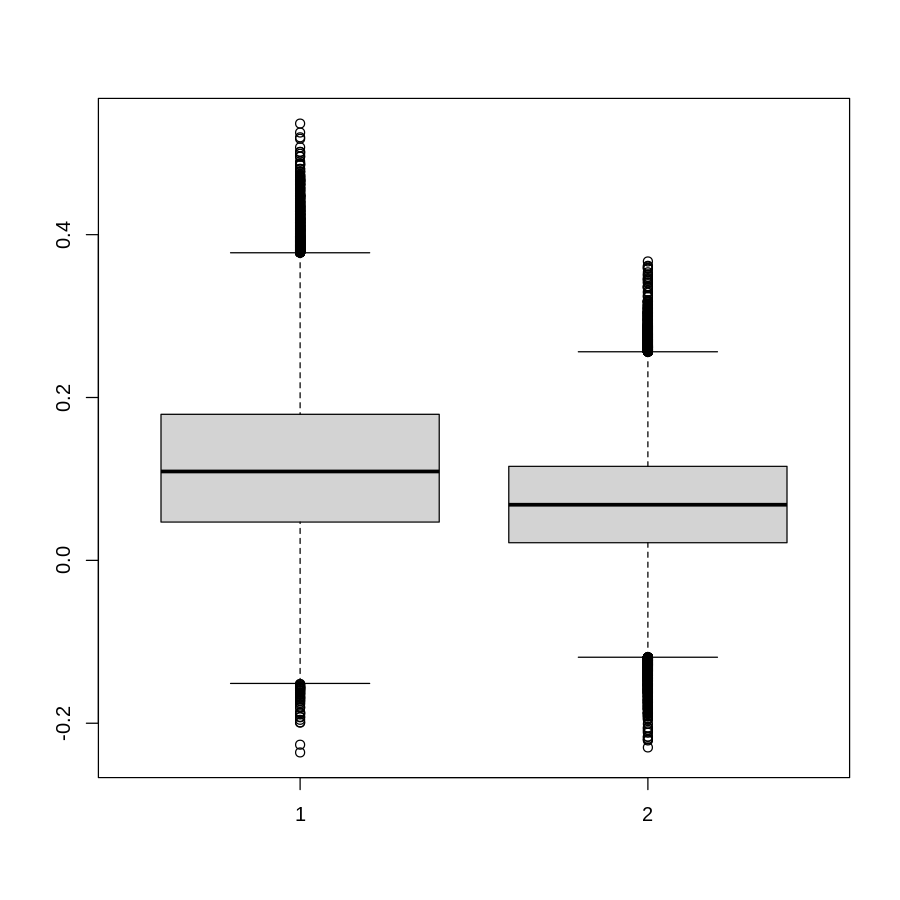

In [40]:
boxplot(cor(-log10(testRes_envPC1PeOG_permMat[,weirdos]+1e-4),method = "spearman")[upper.tri(cor(-log10(testRes_envPC1PeOG_permMat[,weirdos]+1e-4)))],
        cor(-log10(testRes_envPC1PeOG_permMat[,-weirdos]+1e-4),method = "spearman")[upper.tri(cor(-log10(testRes_envPC1PeOG_permMat[,-weirdos]+1e-4)))])

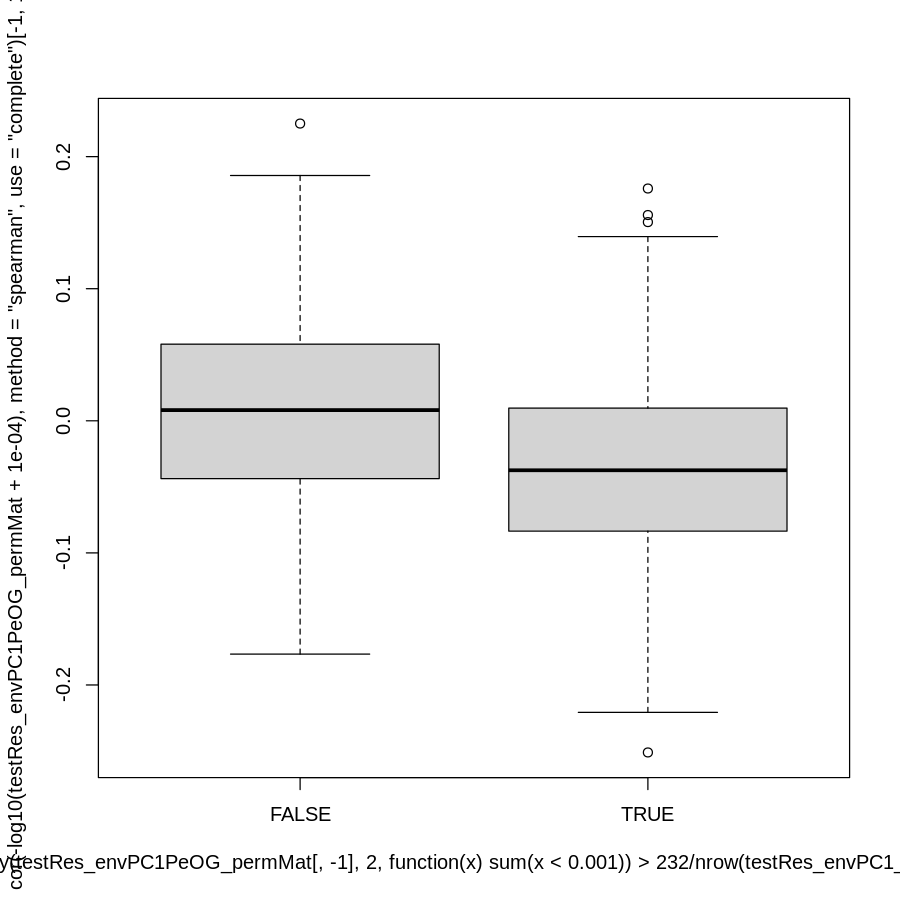

In [46]:
boxplot(cor(-log10(testRes_envPC1PeOG_permMat+1e-4),method = "spearman",use = "complete")[-1,1]~apply(testRes_envPC1PeOG_permMat[,-1],2,function(x) sum(x<0.001))>232/nrow(testRes_envPC1_v2)*232)

In [22]:
set.seed(123)
randOG = sample(testRes_envPC1_v2$OG,100)

In [23]:
rownames(testRes_envPC1_v2) = testRes_envPC1_v2$OG

In [24]:
testRes_envPC1PeOG_permList2 = mclapply(list.files("/workdir/sh2246/p_phyloGWAS/output/permulation/perOG_100random/",full.names = T),
                       function(x) read.table(x,header = T),mc.cores = 20)

testRes_envPC1PeOG_permMat2 = sapply(testRes_envPC1PeOG_permList2,function(x){
    tmp = x
    rownames(tmp) = tmp$OG
    tmp = tmp[randOG,]
    return(tmp[,5])
})

rownames(testRes_envPC1PeOG_permMat2) = randOG

testRes_envPC1PeOG_permMat2 = cbind(testRes_envPC1_v2[randOG,]$p,testRes_envPC1PeOG_permMat2)

In [25]:
head(testRes_envPC1PeOG_permMat2)

OG0004605,0.5354163,0.8507969,0.0959982,0.90528424,0.32154125,0.97781652,0.982196520,0.04321806,0.36834278,0.14053260,⋯,0.396761094,6.752252e-01,0.1830619,0.65864268,0.3922170,0.1801094,0.6321476,0.86376899,0.5430182,0.79515084
OG0003148,0.6380983,0.6388487,0.7062978,0.85252304,0.57721009,0.93763611,0.286706262,0.23287213,0.44237840,0.56267169,⋯,0.391218802,5.905149e-01,0.5498014,0.38718307,0.1687476,0.7674338,0.9462910,0.19056060,0.7175661,0.80959064
OG0005117,0.4116230,0.3320700,0.4307640,0.09804201,0.21106012,0.12764358,0.513737979,0.04784045,0.09120693,0.01801066,⋯,0.290379526,9.322069e-01,0.4752946,0.02302925,0.2645280,0.8803782,0.3009801,0.46668981,0.7371969,0.22120005
OG0014527,0.8010666,0.7036173,0.2342856,0.92581052,0.59100456,0.97462947,0.970491944,0.13245839,0.99179336,0.91108854,⋯,0.774512826,9.323213e-01,0.3001767,0.22974321,0.3383064,0.7242893,0.9623410,0.87828669,0.3878646,0.77802453
OG0006974,0.9284332,0.2651092,0.9093551,0.19461383,0.31138195,0.46309218,0.474858008,0.11963959,0.53788152,0.86838088,⋯,0.452674158,4.799418e-01,0.9908808,0.64153094,0.5652824,0.5627063,0.1392152,0.29673942,0.2903645,0.05082596
OG0009224,0.1703544,0.9560862,0.5383905,0.53750280,0.08839361,0.09122711,0.003825129,0.22210699,0.85544492,0.66681764,⋯,0.007870019,3.860829e-05,0.4712522,0.12950698,0.5304537,0.9954849,0.7282097,0.01991737,0.1377486,0.67434910


In [26]:
emp_p2 = apply(testRes_envPC1PeOG_permMat2,1,function(x) sum(x[-1]<x[1],na.rm = T))/ncol(testRes_envPC1PeOG_permMat2)
              

In [27]:
cor(emp_p2,testRes_envPC1PeOG_permMat2[,1],method = "spearman")

[1] 0.9436982

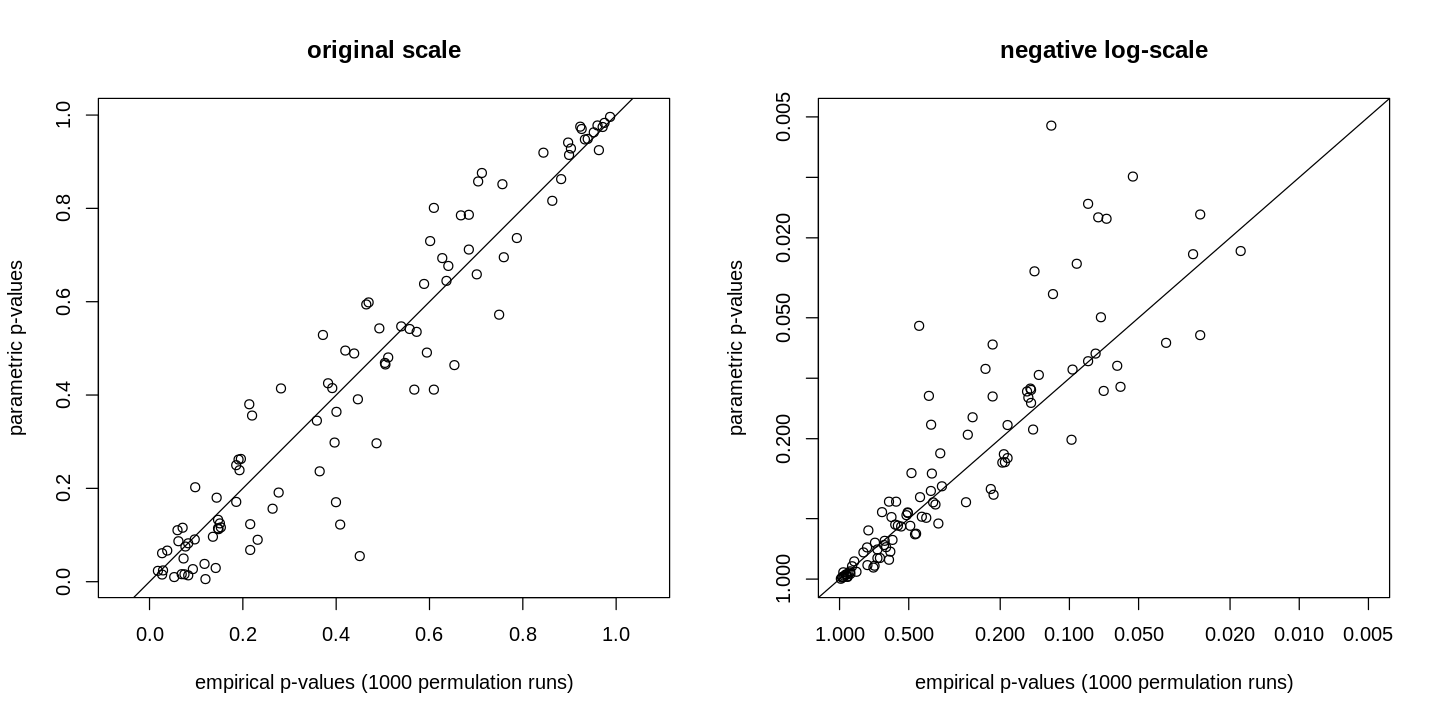

In [49]:
options(repr.plot.width = 12, repr.plot.height = 6)
par(mfrow = c(1,2))
plot(emp_p2,testRes_envPC1PeOG_permMat2[,1],asp =1,
     xlab = "empirical p-values (1000 permulation runs)",
     ylab = "parametric p-values",main = "original scale")
abline(a =0,b =1)

plot(emp_p2,testRes_envPC1PeOG_permMat2[,1],asp =1,log = 'xy',xlim = c(1,0.005),ylim = c(1,0.005),
     xlab = "empirical p-values (1000 permulation runs)",
     ylab = "parametric p-values",main = "negative log-scale")
abline(a =0,b =1)

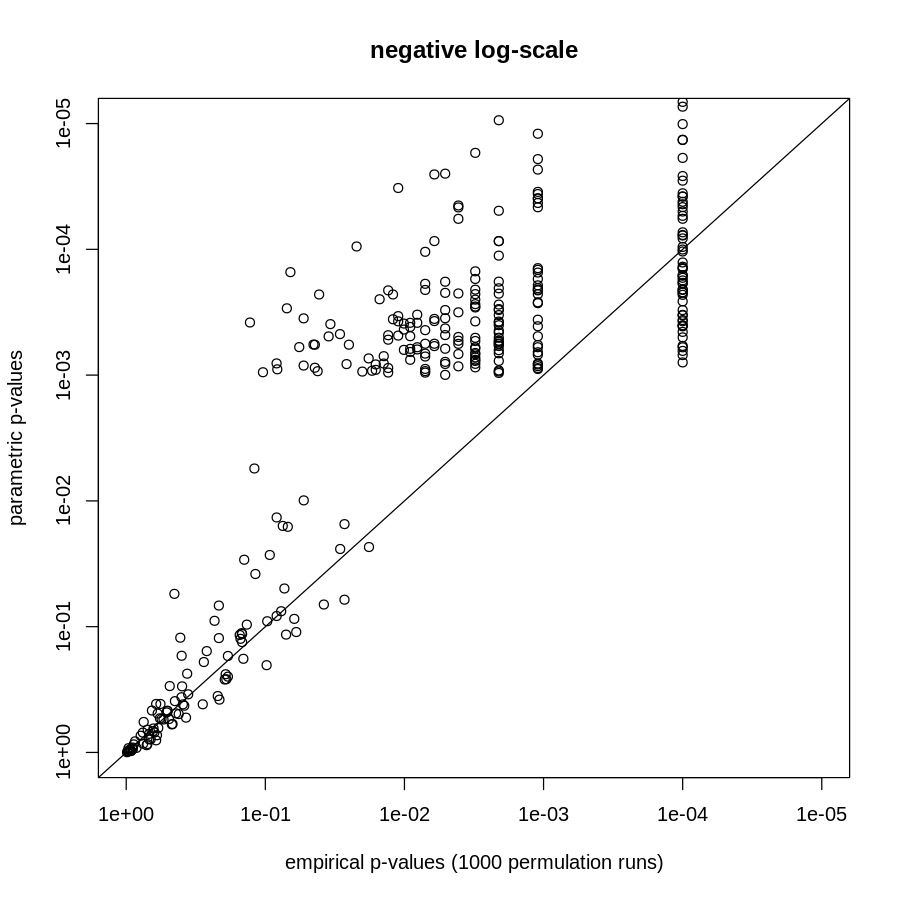

In [50]:
options(repr.plot.width = 7.5, repr.plot.height = 7.5)
plot(c(emp_p2,emp_p+1e-4),c(testRes_envPC1PeOG_permMat2[,1],testRes_envPC1PeOG_permMat[,1]),asp =1,log = 'xy',
     xlim = c(1,1e-5),ylim = c(1,1e-5),
     xlab = "empirical p-values (1000 permulation runs)",
     ylab = "parametric p-values",main = "negative log-scale")
abline(a =0,b =1)

In [269]:
apply(testRes_envPC1PeOG_permMat[,-1],2,function(x) sum(x<0.001))[c(113,557,890)]

[1]  8  5 23

In [270]:
head(sort(apply(testRes_envPC1PeOG_permMat[,-1],2,function(x) sum(x<0.001)),decreasing = T))

[1] 42 34 34 31 29 28

In [63]:
testRes_envPC1PeOG_permList3 = mclapply(list.files("/workdir/sh2246/p_phyloGWAS/output/permulation/perOG_100random_run2/",full.names = T),
                       function(x) read.table(x,header = T),mc.cores = 20)

testRes_envPC1PeOG_permMat3 = sapply(testRes_envPC1PeOG_permList3,function(x){
    tmp = x
    rownames(tmp) = tmp$OG
    tmp = tmp[randOG,]
    return(tmp[,5])
})

rownames(testRes_envPC1PeOG_permMat3) = randOG

testRes_envPC1PeOG_permMat3 = cbind(testRes_envPC1_v2[randOG,]$p,testRes_envPC1PeOG_permMat3)

In [64]:
which(list.files("/workdir/sh2246/p_phyloGWAS/output/permulation/perOG_100random/")=="ASREML_res_perm_2.txt")
which(list.files("/workdir/sh2246/p_phyloGWAS/output/permulation/perOG_100random_run2/")=="ASREML_res_perm_2.txt")

[1] 113

[1] 12

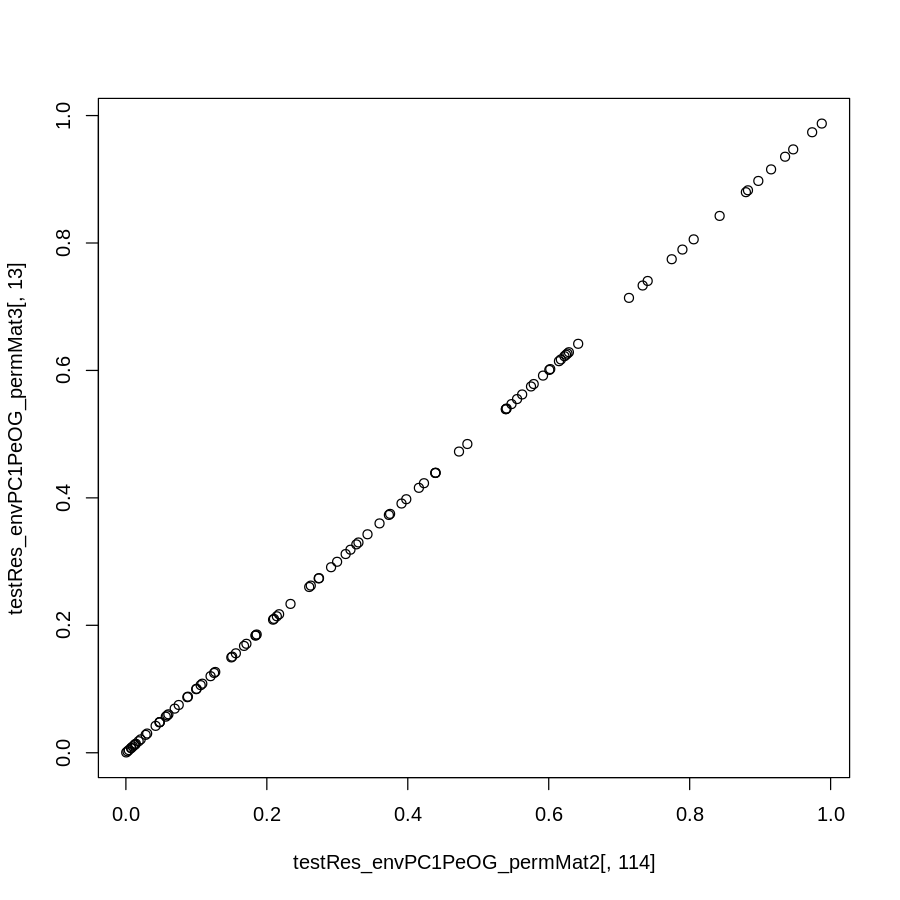

In [66]:
plot(testRes_envPC1PeOG_permMat2[,114],testRes_envPC1PeOG_permMat3[,13])

In [132]:
tmp1 = read.table("/workdir/sh2246/p_phyloGWAS/output/permulation/perOG_100random_run2/ASREML_res_perm_1.txt",header = T)
tmp2 = read.table("/workdir/sh2246/p_phyloGWAS/output/permulation/perOG_100random_run2/ASREML_res_perm_10.txt",header = T)

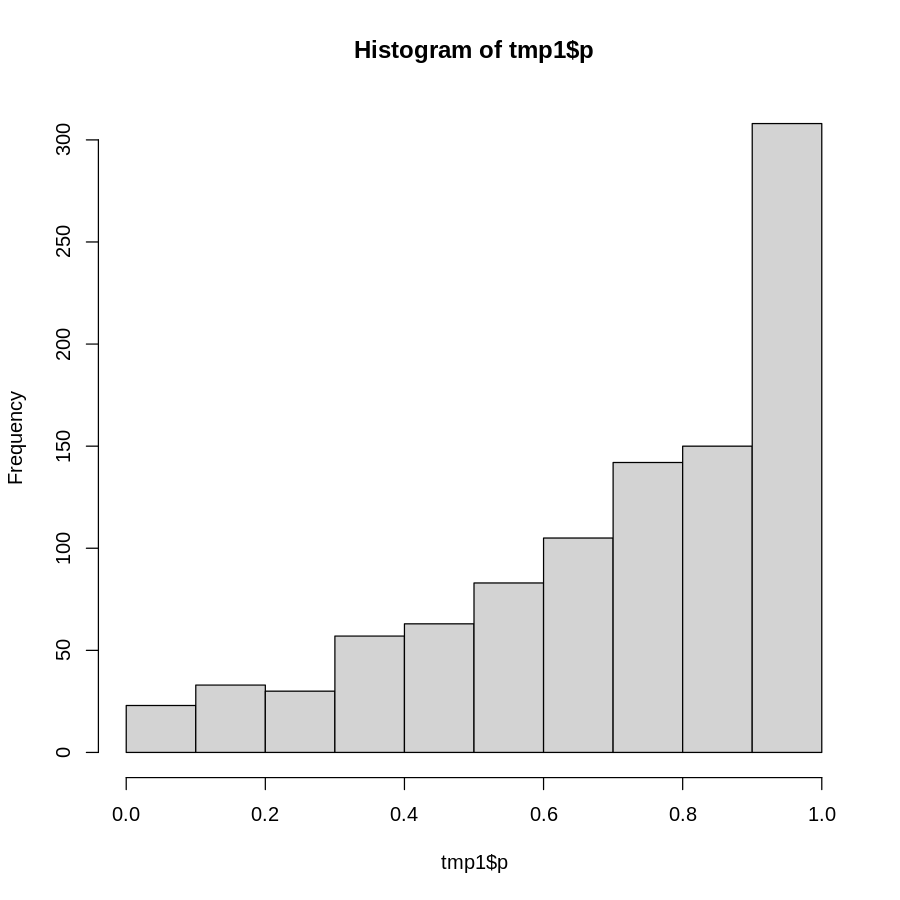

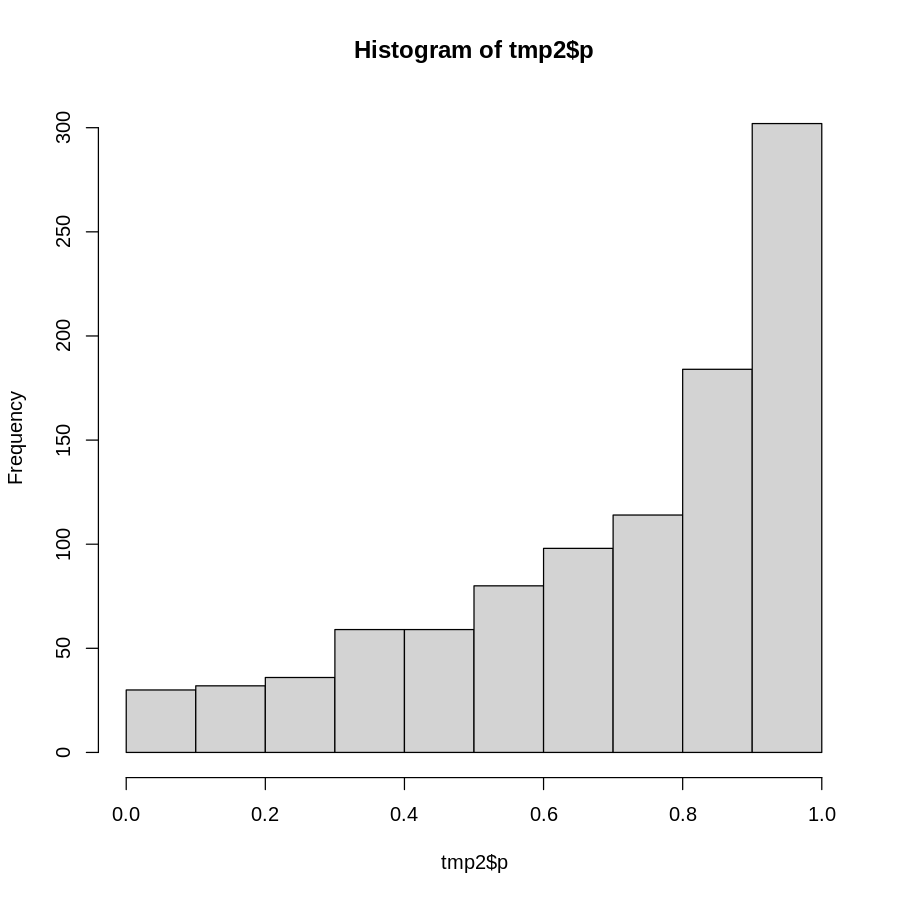

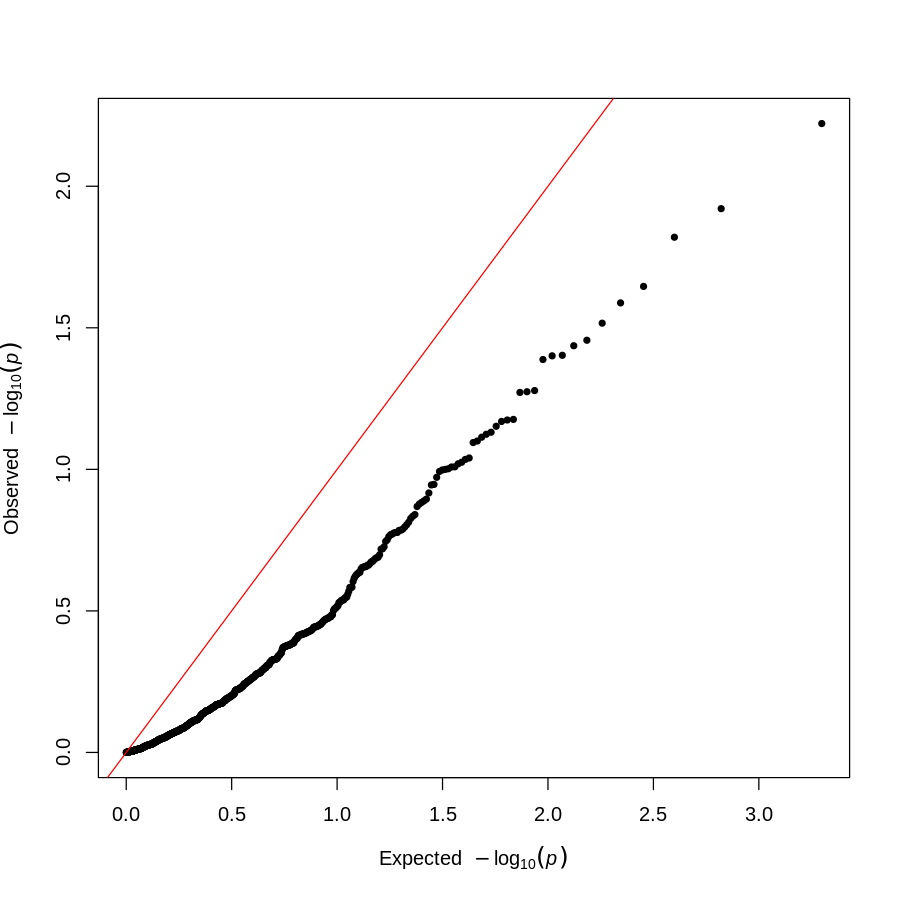

In [133]:
hist(tmp1$p)
hist(tmp2$p)
qq(tmp2$p)

In [191]:
test

OG                BIC_full             BIC_reduced 
            "OG0003466"     "-114.170684329046"     "-143.582460452373" 
                     LR                       p                 geneVAE 
     "3.74164080488475"     "0.587179569937954" "-0.000435446562958524" 
               phyloVAE                totalVar        partialCoeff_PAV 
    "0.765489240587196"      "1.00650056043877"    "-0.429429964610308" 
      partialCoeff_dNdS       partialCoeff_ESM2   partialCoeff_plantCad 
  "-0.0145868144627292"  "-0.00676521284329423"  "-0.00874826422514514" 
       partialCoeff_PMS            partialP_PAV           partialP_dNdS 
   "0.0815176580394551"    "0.0915328015211235"     "0.618246713324138" 
          partialP_ESM2       partialP_plantCad            partialP_PMS 
     "0.61701037128714"     "0.732961735564736"     "0.572651579721897"

In [295]:
# testRes_envPC1_permList = list()
asreml.options(maxit = 40,verbose = F)
for(i in 3:10){
    testRes_envPC1_permList[[i]] = mclapply(OG_list,function(x) try(fit_model_v4(x,testData_merged,phyloKMat,envPC1_perm[[i]]),silent = T),mc.cores = 35)
#     testRes_envPC1_permList[[i]] = t(simplify2array(testRes_envPC1_permList[[i]][sapply(testRes_envPC1_permList[[i]],length)==length(test)]))
#     testRes_envPC1_permList[[i]] = as.data.frame(testRes_envPC1_permList[[i]])
#     testRes_envPC1_permList[[i]] = merge(testRes_envPC1_permList[[i]],mappingFileMerged,by = "OG",all.x = T)
}


Warning message in mclapply(OG_list, function(x) try(fit_model_v4(x, testData_merged, :
“all scheduled cores encountered errors in user code”
Warning message in mclapply(OG_list, function(x) try(fit_model_v4(x, testData_merged, :
“scheduled cores 28, 12, 7, 22, 2, 35, 25, 29, 27, 18, 33, 32, 23, 3, 4, 31, 14, 13, 19, 15, 8, 30, 17, 6, 20, 11, 26, 34, 10, 21, 16, 9, 24, 5 encountered errors in user code, all values of the jobs will be affected”


ERROR: Error in rawToChar(bytes): embedded nul in string: '\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\0\

In [298]:
dir.create("/workdir/sh2246/p_phyloGWAS/output/permulation/")

In [300]:
for(i in 1:2){
    write.table(testRes_envPC1_permList[[i]],paste0("/workdir/sh2246/p_phyloGWAS/output/permulation/ASREML_res_perm_envPC1_",i,".txt"),
                quote = F,sep = "\t",row.names = F)
}

In [290]:
sort(sapply(testRes_envPC1_permList,function(x) min(as.numeric(x$p),na.rm = T)))

[1] 3.692552e-09 1.140543e-07 2.633050e-07 4.091581e-07 4.581963e-05
[6] 1.922752e-04 2.137366e-04 3.903426e-04

In [296]:
sapply(testRes_envPC1_permList,dim)

[[1]]
[1] 19134    18

[[2]]
[1] 19301    18

[[3]]
NULL

[[4]]
NULL

[[5]]
[1] 1080   18

[[6]]
[1] 551  18

[[7]]
[1] 543  18

[[8]]
[1] 547  18

In [297]:
head(testRes_envPC1_permList[[3]])

[[1]]
[1] "fatal error in wrapper code"
attr(,"class")
[1] "try-error"

[[2]]
[1] "fatal error in wrapper code"
attr(,"class")
[1] "try-error"

[[3]]
[1] "fatal error in wrapper code"
attr(,"class")
[1] "try-error"

[[4]]
[1] "fatal error in wrapper code"
attr(,"class")
[1] "try-error"

[[5]]
[1] "fatal error in wrapper code"
attr(,"class")
[1] "try-error"

[[6]]
[1] "fatal error in wrapper code"
attr(,"class")
[1] "try-error"


In [287]:
i = 2
# testRes_envPC1_permList[[i]] = mclapply(OG_list,function(x) try(fit_model_v4(x,testData_merged,phyloKMat,envPC1_perm[[i]]),
#                                                                                    silent = T),mc.cores = 40)
testRes_envPC1_permList[[i]] = t(simplify2array(testRes_envPC1_permList[[i]][sapply(testRes_envPC1_permList[[i]],length)==length(test)]))
testRes_envPC1_permList[[i]] = as.data.frame(testRes_envPC1_permList[[i]])

In [286]:
testRes_envPC1_permList[[2]][4]

[[1]]
                    OG               BIC_full            BIC_reduced 
           "OG0017607"     "377.889742245035"     "347.546495050926" 
                    LR                      p                geneVAE 
    "3.54498577406684"     "0.61659190959423" "0.000446290063518198" 
              phyloVAE               totalVar       partialCoeff_PAV 
   "0.618399492994571"      "1.0340613393315"    "0.273974457421647" 
     partialCoeff_dNdS      partialCoeff_ESM2  partialCoeff_plantCad 
  "0.0962368175231248"  "-0.0113500616320435"    "0.038451913259743" 
      partialCoeff_PMS           partialP_PAV          partialP_dNdS 
  "-0.279276565305073"     "0.68778512058537"    "0.415798229185245" 
         partialP_ESM2      partialP_plantCad           partialP_PMS 
   "0.429816709083991"    "0.311219648908654"    "0.289152703583928"

In [277]:
head(OG_list,100)

[1] "OG0000062" "OG0007875" "OG0032189" "OG0017607" "OG0010582" "OG0009855"
  [7] "OG0002725" "OG0031429" "OG0006066" "OG0022431" "OG0008850" "OG0022308"
 [13] "OG0022886" "OG0018140" "OG0005674" "OG0008718" "OG0023428" "OG0014942"
 [19] "OG0017036" "OG0015019" "OG0009037" "OG0008074" "OG0001832" "OG0003030"
 [25] "OG0020936" "OG0026674" "OG0010788" "OG0005203" "OG0012522" "OG0018333"
 [31] "OG0009293" "OG0012398" "OG0016410" "OG0014658" "OG0004643" "OG0007178"
 [37] "OG0018986" "OG0016085" "OG0018974" "OG0001396" "OG0018320" "OG0011037"
 [43] "OG0025603" "OG0003676" "OG0003840" "OG0011868" "OG0013712" "OG0003180"
 [49] "OG0025565" "OG0006281" "OG0006997" "OG0015857" "OG0001621" "OG0019206"
 [55] "OG0010286" "OG0010398" "OG0010096" "OG0021225" "OG0014733" "OG0005375"
 [61] "OG0013442" "OG0012546" "OG0000574" "OG0016602" "OG0007411" "OG0002920"
 [67] "OG0014582" "OG0018065" "OG0024672" "OG0010061" "OG0006357" "OG0010797"
 [73] "OG0005089" "OG0017724" "OG0014043" "OG0014139" "OG0012656" "OG0017945"
 [79] "OG0003953" "OG0003494" "OG0004010" "OG0012704" "OG0004104" "OG0016269"
 [85] "OG0006231" "OG0008682" "OG0015168" "OG0017790" "OG0003297" "OG0018893"
 [91] "OG0011310" "OG0003631" "OG0016009" "OG0018371" "OG0024755" "OG0010671"
 [97] "OG0010508" "OG0022447" "OG0014670" "OG0007240"

In [278]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,22990174,1227.9,47690478,2547.0,47690478,2547.0
Vcells,6448466578,49197.9,11417700466,87110.2,11417692335,87110.1


# GLM

In [36]:
test2 = fit_model_glm("OG0000977",data = testData_merged,"perm_envPC1")
test3 = fit_model_glm("OG0000977",data = testData_merged,"envPC_1")

ASReml Version 4.2 20/08/2025 22:18:03
          LogLik        Sigma2     DF     wall
 1     -1125.225     0.9560126   2287   22:18:03
ASReml Version 4.2 20/08/2025 22:18:03
          LogLik        Sigma2     DF     wall
 1     -1119.258     0.9616663   2292   22:18:03
ASReml Version 4.2 20/08/2025 22:18:16
          LogLik        Sigma2     DF     wall
 1     -1002.010     0.8583565   2287   22:18:16
ASReml Version 4.2 20/08/2025 22:18:16
          LogLik        Sigma2     DF     wall
 1     -1335.285      1.161157   2292   22:18:16


In [37]:
test2
test3

OG               BIC_full            BIC_reduced 
           "OG0000977"     "2261.10564619719"     "2240.94913470445" 
                    LR                      p       partialCoeff_PAV 
    "18.5381072944651"  "0.00234238888622063"    "-0.11432304807903" 
     partialCoeff_dNdS      partialCoeff_ESM2  partialCoeff_plantCad 
   "-0.08348003575205"   "0.0245447009809428"  "-0.0289464438922341" 
      partialCoeff_PMS           partialP_PAV          partialP_dNdS 
 "-0.0208790618657433"    "0.767891881300016" "4.19601939971592e-05" 
         partialP_ESM2      partialP_plantCad           partialP_PMS 
   "0.418684045166735"    "0.579675745165644"    "0.560227834372717"

OG               BIC_full            BIC_reduced 
           "OG0000977"     "2013.70784559259"     "2673.75586044548" 
                    LR                      p       partialCoeff_PAV 
    "698.742633640084" "9.1859253871901e-149"     "1.31490726819995" 
     partialCoeff_dNdS      partialCoeff_ESM2  partialCoeff_plantCad 
 "-0.0868805175873129" "-0.00635515683665861"   "0.0696187946931035" 
      partialCoeff_PMS           partialP_PAV          partialP_dNdS 
    "1.16327348201054"    "0.038373450472301"  "0.00251215731602039" 
         partialP_ESM2      partialP_plantCad           partialP_PMS 
   "0.392577466336131"    "0.370278786793858"                    "0"

In [38]:
# asreml.options(maxit = 40,verbose = F)
# testRes_envPC1_glm = mclapply(OG_list,function(x) try(fit_model_glm(x,testData_merged,"envPC_1"),
#                                                      silent = T),mc.cores = 10)
# testRes_envPC1_glm = t(simplify2array(testRes_envPC1_glm[sapply(testRes_envPC1_glm,length)==length(test2)]))
# testRes_envPC1_glm = as.data.frame(testRes_envPC1_glm)
# testRes_envPC1_glm = merge(testRes_envPC1_glm,mappingFileMerged,by = "OG",all.x = T)
# write.table(testRes_envPC1_glm,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1_glm_20250815.txt",quote = F,sep = "\t",row.names = F)
testRes_envPC1_glm = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1_glm_20250815.txt",header =T)

In [166]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC2_glm = mclapply(OG_list,function(x) try(fit_model_glm(x,testData_merged,"envPC2"),
                                                     silent = T),mc.cores = 10)
testRes_envPC2_glm = t(simplify2array(testRes_envPC2_glm[sapply(testRes_envPC2_glm,length)==length(test2)]))
testRes_envPC2_glm = as.data.frame(testRes_envPC2_glm)
testRes_envPC2_glm = merge(testRes_envPC2_glm,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_envPC2_glm,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC2_glm_20250815.txt",quote = F,sep = "\t",row.names = F)
testRes_envPC2_glm = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC2_glm_20250815.txt",header =T)

Warning message in file(file, "rt"):
“cannot open file '/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC2_glm_20250815.txt': No such file or directory”


ERROR: Error in file(file, "rt"): cannot open the connection


In [39]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC1_glm_perm = mclapply(OG_list,function(x) try(fit_model_glm(x,testData_merged,"perm_envPC1"),
                                                     silent = T),mc.cores = 20)
testRes_envPC1_glm_perm = t(simplify2array(testRes_envPC1_glm_perm[sapply(testRes_envPC1_glm_perm,length)==length(test2)]))
testRes_envPC1_glm_perm = as.data.frame(testRes_envPC1_glm_perm)
testRes_envPC1_glm_perm = merge(testRes_envPC1_glm_perm,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_envPC1_glm_perm,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1_glm_perm_20250815.txt",quote = F,sep = "\t",row.names = F)
testRes_envPC1_glm_perm = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1_glm_perm_20250815.txt",header =T)

In [40]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC2_glm_perm = mclapply(OG_list,function(x) try(fit_model_glm(x,testData_merged,"perm_envPC2"),
                                                     silent = T),mc.cores = 20)
testRes_envPC2_glm_perm = t(simplify2array(testRes_envPC2_glm_perm[sapply(testRes_envPC2_glm_perm,length)==length(test2)]))
testRes_envPC2_glm_perm = as.data.frame(testRes_envPC2_glm_perm)
testRes_envPC2_glm_perm = merge(testRes_envPC2_glm_perm,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_envPC2_glm_perm,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC2_glm_perm_20250815.txt",quote = F,sep = "\t",row.names = F)
testRes_envPC2_glm_perm = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC2_glm_perm_20250815.txt",header =T)

In [ ]:
# visualization

In [61]:
mergedPval_envPC1 = merge(data.frame(OG = OG_list),testRes_envPC1_glm[,c(1,5)],by = "OG",all.x = T)
mergedPval_envPC1 = merge(mergedPval_envPC1,testRes_envPC1_v2[,c(1,5)],by = "OG",all.x = T)
mergedPval_envPC1 = merge(mergedPval_envPC1,testRes_envPC1_glm_perm[,c(1,5)],by = "OG",all.x = T)
mergedPval_envPC1 = merge(mergedPval_envPC1,testRes_envPC1_perm[,c(1,5)],by = "OG",all.x = T)
colnames(mergedPval_envPC1) = c("OG","p_GLM","p_MLM","p_GLM_perm","p_MLM_perm")



Warning message in merge.data.frame(mergedPval_envPC1, testRes_envPC1_perm[, c(1, :
“column names ‘p.x’, ‘p.y’ are duplicated in the result”


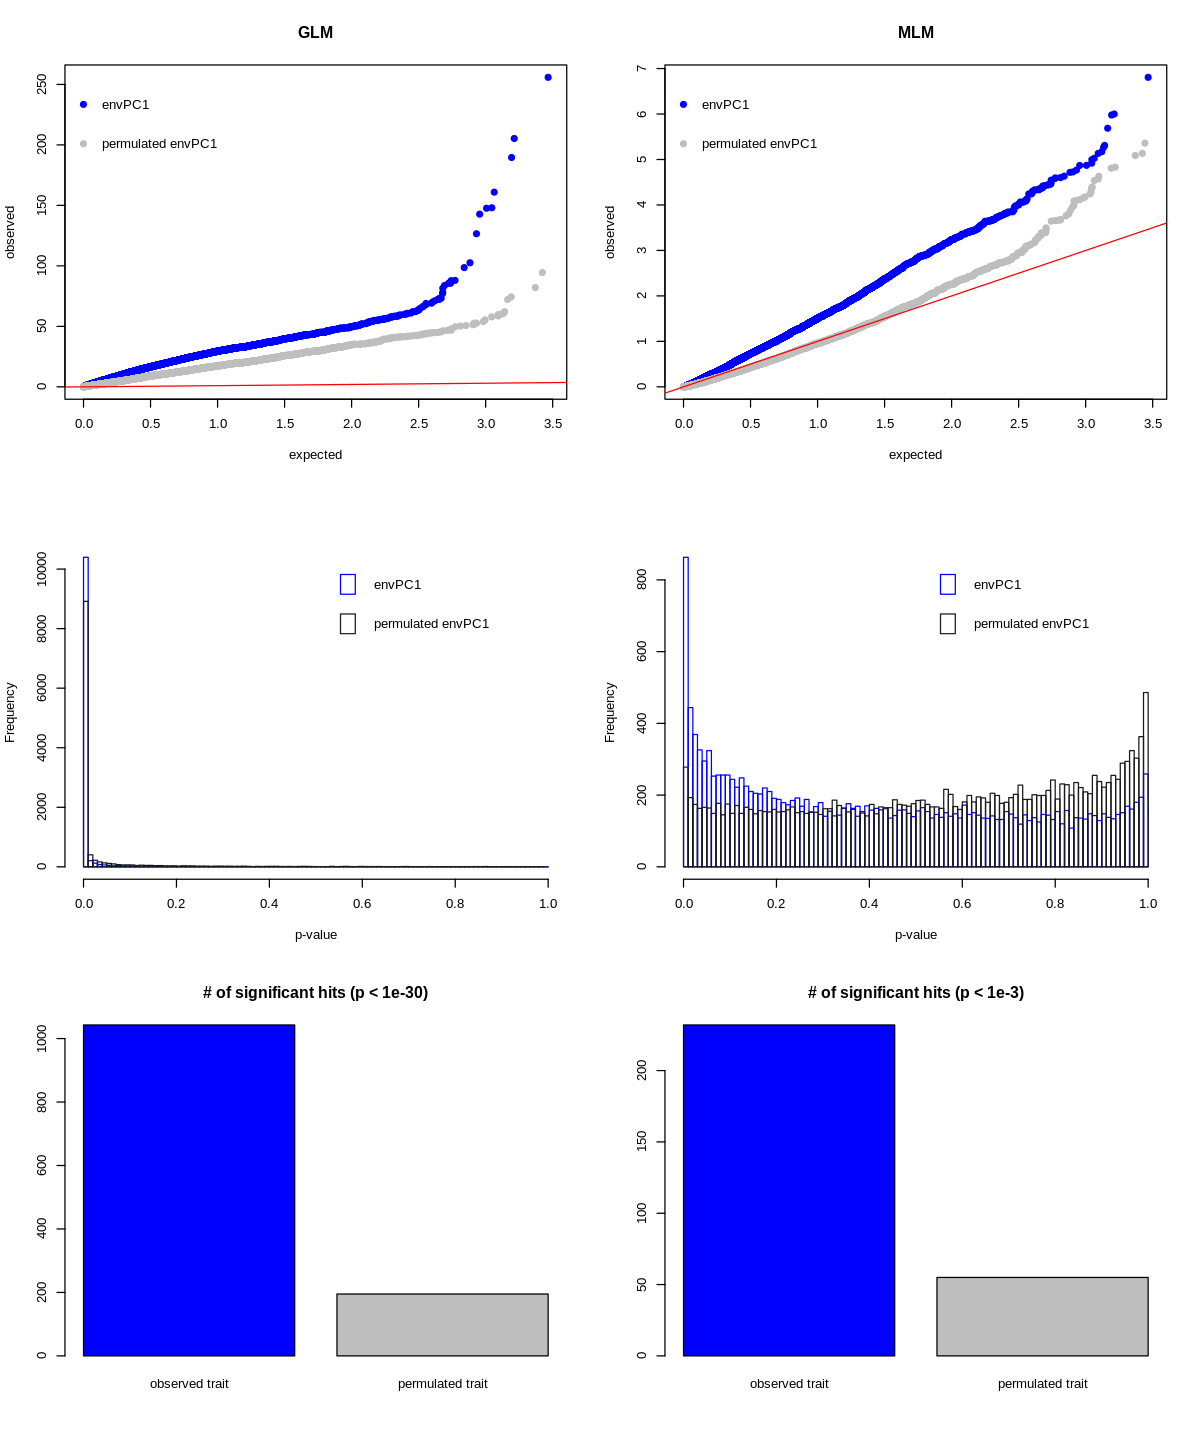

In [168]:
options(repr.plot.width = 10, repr.plot.height = 12)
par(mfrow = c(3,2))
set.seed(1234)
plot(sort(-log10(runif(0,1,n = nrow(testRes_envPC1_glm)))),
     sort(-log10(as.numeric(testRes_envPC1_glm$p))),
     pch = 19,xlab = "expected",ylab = "observed",col = "blue",main = "GLM")
points(sort(-log10(runif(0,1,n = nrow(testRes_envPC1_glm_perm)))),
       sort(-log10(as.numeric(testRes_envPC1_glm_perm$p))),pch = 19,col ="grey")
abline (a = 0,b= 1,col ="red")
# abline (h = -log10(quantile(testRes_envPC1_glm_perm$p,.01)),col ="red",lty = 2)
legend("topleft",legend = c("envPC1","permulated envPC1"),pch = 19, col = c("blue","grey"),bty = 'n')
set.seed(1234)
plot(sort(-log10(runif(0,1,n = nrow(testRes_envPC1_v2)))),
     sort(-log10(as.numeric(testRes_envPC1_v2$p))),
     pch = 19,xlab = "expected",ylab = "observed",col = "blue", main = "MLM")
points(sort(-log10(runif(0,1,n = nrow(testRes_envPC1_perm)))),
       sort(-log10(as.numeric(testRes_envPC1_perm$p))),pch = 19,col ="grey")
abline (a = 0,b= 1,col ="red")
# abline (h = -log10(quantile(testRes_envPC1_perm$p,.01)),col ="red",lty = 2)
legend("topleft",legend = c("envPC1","permulated envPC1"),pch = 19, col = c("blue","grey"),bty = 'n')

hist(testRes_envPC1_glm$p, border = alpha("blue",1),col = NA, xlab = "p-value",main = "",breaks = seq(0,1,0.01))
hist(testRes_envPC1_glm_perm$p, border = alpha("grey10",1),col = NA,breaks = seq(0,1,0.01),add = T)
legend("topright",legend = c("envPC1","permulated envPC1"),border = alpha(c("blue","grey10"),1),fill = NA,bty = 'n')
hist(testRes_envPC1_v2$p, border = alpha("blue",1),col = NA, xlab = "p-value",main = "",breaks = seq(0,1,0.01))
hist(testRes_envPC1_perm$p, border = alpha("grey10",1),col = NA,breaks = seq(0,1,0.01),add = T)
legend("topright",legend = c("envPC1","permulated envPC1"),border = alpha(c("blue","grey10"),1), fill =NA,bty = 'n')

barplot(c(sum(mergedPval_envPC1$p_GLM<1e-30,na.rm =T),sum(mergedPval_envPC1$p_GLM_perm<1e-30,na.rm =T)),
        col = c("blue","grey"),names.arg = c("observed trait","permulated trait"), 
        main = "# of significant hits (p < 1e-30)")
barplot(c(sum(mergedPval_envPC1$p_MLM<1e-3,na.rm =T),sum(mergedPval_envPC1$p_MLM_perm<1e-3,na.rm =T)),
        col = c("blue","grey"),names.arg = c("observed trait","permulated trait"),
        main = "# of significant hits (p < 1e-3)")

# hist(testRes_envPC1_glm$p, border = alpha("blue",1),col = NA, xlab = "p-value",main = "",breaks = seq(0,1,0.000001),xlim = c(0,.0001))
# hist(testRes_envPC1_glm_perm$p, border = alpha("grey10",1),col = NA,breaks = seq(0,1,0.000001),add = T)
# legend("topright",legend = c("envPC1","permulated envPC1"),border = alpha(c("blue","grey10"),1),fill = NA,bty = 'n')
# hist(testRes_envPC1_v2$p, border = alpha("blue",1),col = NA, xlab = "p-value",main = "",breaks = seq(0,1,0.0001),xlim = c(0,.01))
# hist(testRes_envPC1_perm$p, border = alpha("grey10",1),col = NA,breaks = seq(0,1,0.0001),add = T)
# legend("topright",legend = c("envPC1","permulated envPC1"),border = alpha(c("blue","grey10"),1), fill =NA,bty = 'n')

# hist(log10(testRes_envPC1_glm$p), border = alpha("blue",1), xlab = "p-value",main = "",breaks = seq(-260,0,1),
#      xlim = c(-100,0),ylim = c(0,7500),col = NA,xaxt = 'n')
# hist(log10(testRes_envPC1_glm_perm$p), border = alpha("grey10",1),col = NA,breaks = seq(-260,0,1),add = T)
# axis(1,at = seq(-100,0,10),labels = 10^seq(-100,0,10))
# legend("topleft",legend = c("envPC1","permulated envPC1"),border = alpha(c("blue","grey10"),1),fill = "NA",bty = 'n')
# hist(log10(testRes_envPC1_v2$p), border = alpha("blue",1), xlab = "p-value",main = "",breaks = seq(-8,0,.1),
#      xlim = c(-8,0),ylim = c(0,7500),col = NA,xaxt = 'n')
# hist(log10(testRes_envPC1_perm$p), border = alpha("grey10",1),col = NA,breaks = seq(-8,0,.1),add = T)
# axis(1,at = seq(-10,0,2),labels = 10^seq(-10,0,2))
# legend("topleft",legend = c("envPC1","permulated envPC1"),border = alpha(c("blue","grey10"),1),fill = "NA",bty = 'n')


In [62]:
dim(mergedPval_envPC1)

[1] 19621     5

In [162]:
FDR_mlm = c()
sigCount_mlm = c()
for(i in 10^seq(-5,0,1)){
    sigCount_mlm = c(sigCount_mlm,sum(mergedPval_envPC1$p_MLM<i,na.rm =T))
    FDR_mlm = c(FDR_mlm,sum(mergedPval_envPC1$p_MLM_perm<i,na.rm =T)/sum(mergedPval_envPC1$p_MLM<i,na.rm =T)*sum(!is.na(mergedPval_envPC1$p_MLM))/sum(!is.na(mergedPval_envPC1$p_MLM_perm)))
}

In [163]:
FDR_glm = c()
sigCount_glm = c()
for(i in 10^seq(-100,0,10)){
    sigCount_glm = c(sigCount_glm,sum(mergedPval_envPC1$p_GLM<i,na.rm =T))
    FDR_glm = c(FDR_glm,sum(mergedPval_envPC1$p_GLM_perm<i,na.rm =T)/sum(mergedPval_envPC1$p_GLM<i,na.rm =T)*sum(!is.na(mergedPval_envPC1$p_GLM))/sum(!is.na(mergedPval_envPC1$p_GLM_perm)))
}

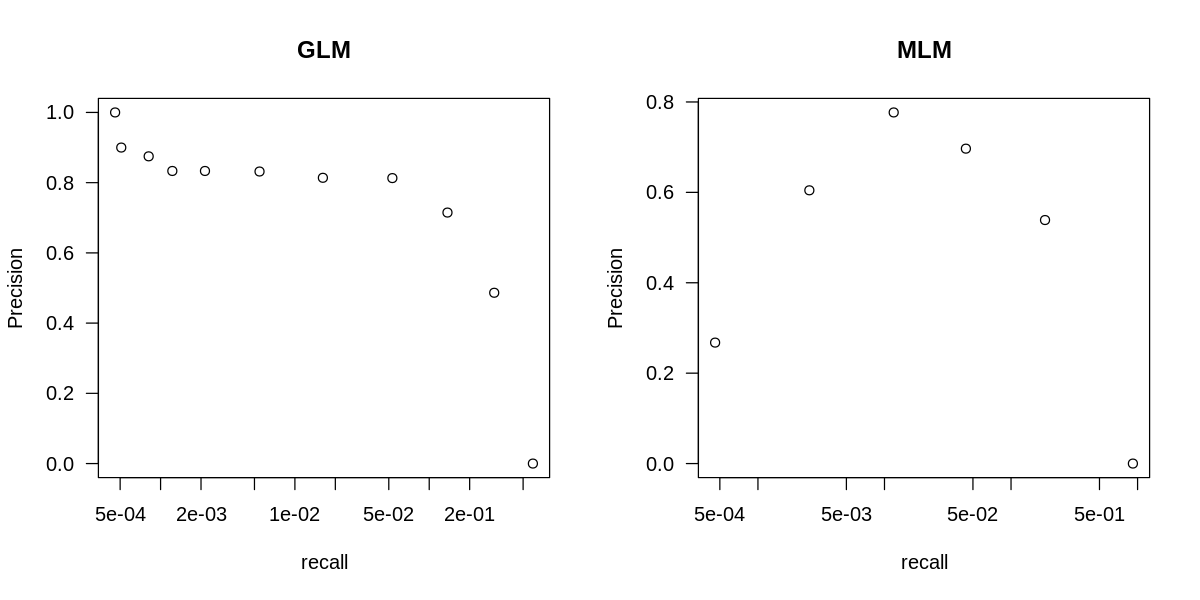

In [175]:
options(repr.plot.width = 10, repr.plot.height = 5)
par(mfrow =c(1,2),las =1)
plot(sigCount_glm/length(OG_list),1-FDR_glm,log= 'x',xlab = "recall",ylab = "Precision",main = "GLM")
# axis(2,at = 10^seq(-100,0,10),labels = 10^seq(-100,0,10))
# axis(4,at = 10^seq(-100,0,10),labels = sigCount_glm)
plot(sigCount_mlm/length(OG_list),1-FDR_mlm,log = 'x',xlab = "recall",ylab = "Precision",main = "MLM")
# axis(2,at = 10^seq(-5,0,1),labels = 10^seq(-5,0,1))
# axis(4,at = 10^seq(-5,0,1),labels = sigCount_mlm)



In [179]:
sum(p.adjust(testRes_envPC1_v2$p,method = "BH")<0.05)

[1] 101

In [147]:
cor(mergedPval_envPC1[,-1],use = "pairwise.complete.obs",method = "spearman")

,p_GLM,p_MLM,p_GLM_perm,p_MLM_perm
p_GLM,1.00000000,0.01589793,0.28836055,-0.02498783
p_MLM,0.01589793,1.00000000,-0.01502873,0.03234342
p_GLM_perm,0.28836055,-0.01502873,1.00000000,-0.01210495
p_MLM_perm,-0.02498783,0.03234342,-0.01210495,1.00000000


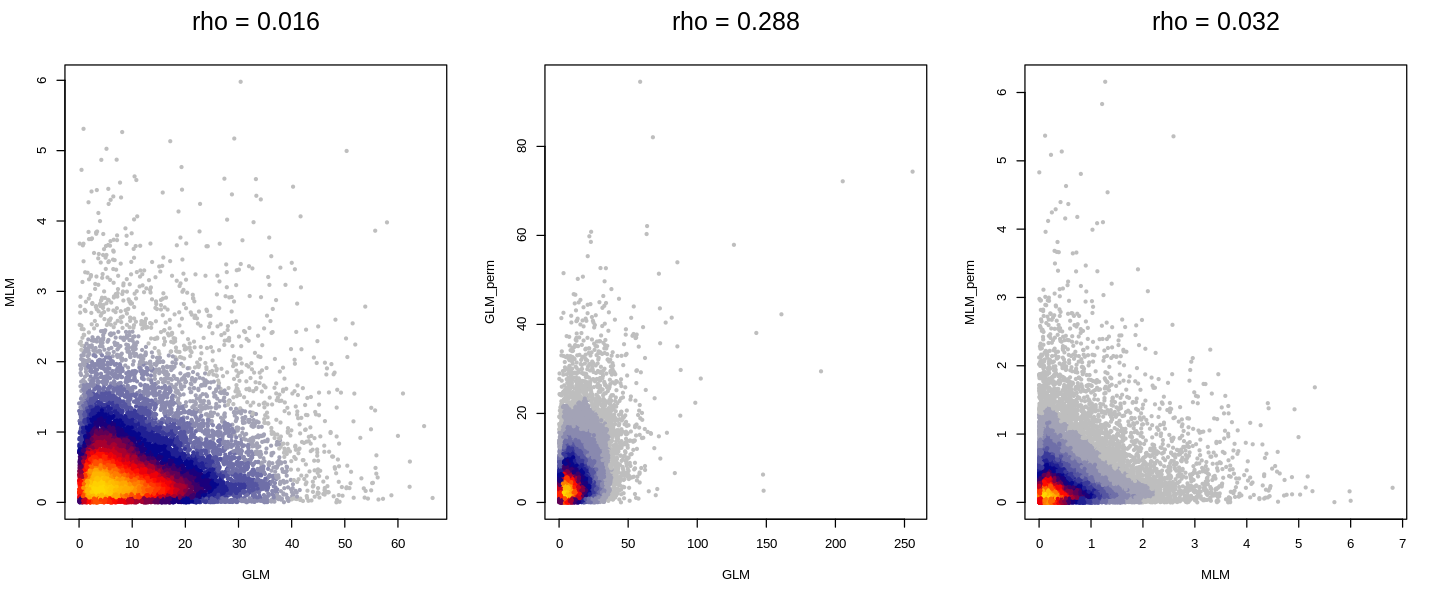

In [151]:
options(repr.plot.width = 12, repr.plot.height = 5)
par(mfrow = c(1,3))
# tmp = intersect(testRes_envPC1_glm$OG,testRes_envPC1_v2$OG)
with(mergedPval_envPC1,LSD::heatscatter(-log10(p_GLM),-log10(p_MLM),xlab = "GLM",ylab = "MLM",main = "rho = 0.016"))
with(mergedPval_envPC1,LSD::heatscatter(-log10(p_GLM),-log10(p_GLM_perm),xlab = "GLM",ylab = "GLM_perm",main = "rho = 0.288"))
with(mergedPval_envPC1,LSD::heatscatter(-log10(p_MLM),-log10(p_MLM_perm),xlab = "MLM",ylab = "MLM_perm",main = "rho = 0.032"))



In [144]:
testRes_envPC1_v2[which(-log10(testRes_envPC1_v2$p)>5),]

,OG,BIC_full,BIC_reduced,LR,p,geneVAE,phyloVAE,totalVar,partialCoeff_PAV,partialCoeff_dNdS,partialCoeff_ESM2,partialCoeff_plantCad,partialCoeff_PMS,partialP_PAV,partialP_dNdS,partialP_ESM2,partialP_plantCad,partialP_PMS,PvID,ZmID
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
564,OG0001454,52.966790,51.334399,32.42383,4.896683e-06,0.0020856540,0.8185412,1.093762,0.5119314,0.10882057,0.033831736,0.09880062,0.11322569,2.210145e-06,2.394381e-01,0.1396955573,1.898409e-02,0.2281015399,Pavag01G328400.1,Zm00001eb392880_T002
830,OG0001871,131.926007,140.877784,35.89014,9.990991e-07,0.0076210403,0.6972683,1.008077,NA,-0.09359287,-0.037515073,0.19151682,-0.41769706,NA,4.435347e-01,0.2107174007,1.816789e-05,0.0081253302,Pavag02G237000.1,Zm00001eb318020_T003
3761,OG0005670,66.648814,79.447631,39.90940,1.557523e-07,0.0149741464,0.7951242,1.068504,NA,-0.13270203,-0.004211581,0.06669813,-0.22779831,NA,2.524541e-06,0.0073053887,1.034701e-01,0.1281105847,Pavag02G232000.2,Zm00001eb317580_T006
4117,OG0006169,4.210294,1.553869,31.53560,7.341377e-06,0.0031832494,0.7684397,1.067905,-0.1367550,-0.09297433,-0.087397046,0.04269882,-0.54372119,6.911206e-05,2.168025e-03,0.0859750491,4.785607e-01,0.0489632841,Pavag08G123200.1,Zm00001eb135050_T001
4667,OG0006872,94.208835,92.577603,32.19396,5.438255e-06,0.0078948419,0.7893963,1.057239,-0.7954553,-0.25598371,-0.001489117,0.02899032,-0.06211258,2.443092e-02,2.245458e-01,0.2403395026,5.948173e-04,0.3583014426,Pavag05G001200.3,Zm00001eb163120_T003
7966,OG0010543,171.518859,179.086879,34.32144,2.054674e-06,0.0141260034,0.7635536,1.079752,NA,0.19510091,0.055314440,-0.01974602,-0.21235337,NA,2.409008e-04,0.0003128522,3.712805e-01,0.0518353945,Pavag01G319000.1,Zm00001eb393300_T001
14572,OG0017837,175.506641,173.749951,31.72848,6.723939e-06,0.0022492773,0.6197843,1.016784,-1.1377708,-0.33383670,-0.016194827,0.03975713,-0.11213719,3.098853e-02,1.169088e-01,0.5046219770,2.263522e-02,0.5979470228,Pavag04G331900.1,Zm00001eb259680_T008
16054,OG0019946,228.869173,231.415014,35.78428,1.049001e-06,0.0126240602,0.5846684,1.026264,-2.9318224,-0.53172353,-0.023553505,-0.14193850,-0.01979057,1.813729e-02,5.088362e-01,0.0345231721,9.510205e-03,0.6341166123,Pavag05G173700.1,Zm00001eb200420_T001
16867,OG0022474,193.959417,191.470580,30.99016,9.409258e-06,-0.0005516035,0.7345389,1.008185,2.5762267,-0.07803831,0.098805336,0.03217073,-2.46491315,7.885575e-01,3.012110e-02,0.0028480912,7.421050e-02,0.0001313719,Pavag09G089200.1,NA


In [175]:
testRes_envPC1_v2[testRes_envPC1_v2$OG%in%"OG0000977",]

OG,BIC_full,BIC_reduced,LR,p,geneVAE,phyloVAE,totalVar,partialCoeff_PAV,partialCoeff_dNdS,partialCoeff_ESM2,partialCoeff_plantCad,partialCoeff_PMS,partialP_PAV,partialP_dNdS,partialP_ESM2,partialP_plantCad,partialP_PMS,PvID,ZmID
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>


In [163]:
head(testRes_envPC1_glm[testRes_envPC1_glm$OG%in%tmp,])
head(testRes_envPC1_v2[testRes_envPC1_v2$OG%in%tmp,])


,OG,BIC_full,BIC_reduced,LR,p,partialCoeff_PAV,partialCoeff_dNdS,partialCoeff_ESM2,partialCoeff_plantCad,partialCoeff_PMS,partialP_PAV,partialP_dNdS,partialP_ESM2,partialP_plantCad,partialP_PMS,PvID,ZmID
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
5,OG0000164,796.8801,926.6249,163.72332,1.591663e-33,-2.20367550,-0.47323479,-0.06922184,-0.03123478,-0.20502743,1.606489e-02,0.000000000,0.1780815526,5.160231e-01,0.31776757,Pavag01G121200.1,Zm00001eb134090_T001
11,OG0000246,709.8677,720.2572,43.35471,3.131180e-08,-1.94989097,-0.22611766,-0.06488018,-0.58526582,-0.09623540,7.192048e-02,0.002696027,0.0426400663,1.280113e-06,0.49133427,Pavag05G225500.1,Zm00001eb127360_T001
17,OG0000306,880.1587,875.7494,29.40435,1.931419e-05,0.05744631,-0.08981556,-0.07615515,-0.15498612,-0.02245026,8.124533e-01,0.787903564,0.0001182436,1.113072e-04,0.95269087,Pavag02G045500.2,Zm00001eb205990_T002
19,OG0000314,851.2114,932.6019,115.63575,2.634453e-23,-0.75061716,0.06212329,-0.03574479,-0.35077157,-0.29721978,8.955317e-01,0.456006955,0.0001868771,0.000000e+00,0.09091356,PavagK222800.1,Zm00001eb164750_T001
20,OG0000319,859.7878,883.3024,57.43692,4.109768e-11,-2.59240698,-0.25275007,-0.04100989,0.24034383,0.04370961,4.333051e-01,0.209579624,0.8854267431,1.096893e-07,0.96708183,Pavag02G001400.1,Zm00001eb205000_T001
21,OG0000322,662.4449,714.7613,85.38339,6.255761e-17,0.10197169,-0.08627911,-0.06696449,-0.46525062,-0.38748232,1.649791e-13,0.001359852,0.0814044006,3.328674e-10,0.41973716,Pavag03G050900.1,Zm00001eb121580_T002


,OG,BIC_full,BIC_reduced,LR,p,geneVAE,phyloVAE,totalVar,partialCoeff_PAV,partialCoeff_dNdS,partialCoeff_ESM2,partialCoeff_plantCad,partialCoeff_PMS,partialP_PAV,partialP_dNdS,partialP_ESM2,partialP_plantCad,partialP_PMS,PvID,ZmID
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,OG0000164,69.41927,42.66650,7.225757,0.2043846,-0.0004261929,0.6649486,1.0712727,0.04200226,-0.03986103,0.009627101,0.005116204,0.01353871,0.1084321,0.06031772,0.6058126,0.8403946,0.8893458,Pavag01G121200.1,Zm00001eb134090_T001
2,OG0000246,251.88889,224.37904,5.455369,0.3628647,-0.0018828156,0.6449023,1.0014527,-0.46429542,-0.03138601,-0.081273999,-0.024773197,-0.12455994,0.1046337,0.97822532,0.2082836,0.9296722,0.4393540,Pavag05G225500.1,Zm00001eb127360_T001
4,OG0000306,144.47601,113.25993,2.597566,0.7617351,-0.0020085911,0.7479452,1.0536147,-0.14791631,-0.01999056,-0.014285743,-0.006346904,0.07142602,0.3067204,0.93956435,0.3326584,0.9706556,0.8025366,Pavag02G045500.2,Zm00001eb205990_T002
5,OG0000314,39.80568,12.35362,6.793274,0.2364744,0.0022842843,0.7496391,1.0250043,-0.63604068,-0.06372888,0.026467348,0.021692879,0.07456314,0.3396926,0.18249953,0.2951803,0.4097306,0.2878763,PavagK222800.1,Zm00001eb164750_T001
8,OG0000319,90.66082,60.59211,3.853578,0.5706840,0.0007772299,0.7434102,1.0404081,-0.78367838,-0.06511834,-0.010155265,0.003286542,-0.04629445,0.2549362,0.72727384,0.9133044,0.6973422,0.3018646,Pavag02G001400.1,Zm00001eb205000_T001
9,OG0000322,241.34432,212.66707,4.389671,0.4947794,-0.0029052378,0.5916169,0.9924324,0.53602822,0.06397074,-0.022434203,0.113142642,0.02562825,0.1642444,0.28731172,0.6902672,0.2673946,0.9374309,Pavag03G050900.1,Zm00001eb121580_T002


In [216]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC1_v3 = mclapply(OG_list,function(x) try(fit_model_v3(x,testData_merged,phyloKMat2,"envPC_1"),
                                                     silent = T),mc.cores = 10)
testRes_envPC1_v3 = t(simplify2array(testRes_envPC1_v3[sapply(testRes_envPC1_v3,length)==length(test)]))
testRes_envPC1_v3 = as.data.frame(testRes_envPC1_v3)
testRes_envPC1_v3 = merge(testRes_envPC1_v3,mappingFileMerged,by = "OG",all.x = T)
# write.table(testRes_envPC1_v3,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1_20250428.txt",quote = F,sep = "\t",row.names = F)
# testRes_envPC1_v3 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1_20250428.txt",header =T)

Warning message in mclapply(OG_list, function(x) try(fit_model_v3(x, testData_merged, :
“scheduled cores 4, 8, 7, 10, 6, 1, 5, 2, 9 encountered errors in user code, all values of the jobs will be affected”


In [218]:
dim(testRes_envPC1_v3)

[1] 70 20

In [52]:
OG_batch = split(OG_list,ceiling(seq_along(OG_list) / 100))

In [211]:
testRes_envPC1_v3 = c()
asreml.options(maxit = 40,verbose = F)
for (i in 1:length(OG_batch)){
    testRes_envPC1_tmp = mclapply(OG_batch[[i]],function(x) try(fit_model_v3(x,testData_merged,phyloKMat2,"envPC_1"),
                                                     silent = T),mc.cores = 6)
#     if (sum(sapply(testRes_envPC1_tmp,length)==length(test))==0) next
    testRes_envPC1_tmp = t(simplify2array(testRes_envPC1_tmp[sapply(testRes_envPC1_tmp,length)==length(test)]))
    testRes_envPC1_tmp = as.data.frame(testRes_envPC1_tmp)
    testRes_envPC1_tmp = merge(testRes_envPC1_tmp,mappingFileMerged,by = "OG",all.x = T)
    testRes_envPC1_v3 = rbind(testRes_envPC1_v3,testRes_envPC1_tmp)
}


1604.146  0.227335E-05    992   23:03:39
16      1603.096  0.228981E-05    992   23:03:39
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interr

ERROR: Error in fix.by(by.x, x): 'by' must specify a uniquely valid column


In [215]:
dim(testRes_envPC1_v3)

[1] 15 20

In [71]:
testRes_envPC1_tmp = mclapply(OG_batch[[2]],function(x) try(fit_model_v3(x,testData_merged,phyloKMat2,"envPC_1"),
                                                     silent = T),mc.cores = 6)

In [72]:
testRes_envPC1_tmp

[[1]]
[1] "Error in asreml(fixed = fullFM, random = ~vm(assemblyID, Kmat), ai.sing = F,  : \n  Error   : The estimation was aborted; too many exceptions.\n"
attr(,"class")
[1] "try-error"
attr(,"condition")
<simpleError in asreml(fixed = fullFM, random = ~vm(assemblyID, Kmat), ai.sing = F,     data = filtered_data): Error   : The estimation was aborted; too many exceptions.>

[[2]]
[1] "Error in asreml(fixed = reducedFM, random = ~vm(assemblyID, Kmat), ai.sing = F,  : \n  Error   : The estimation was aborted; too many exceptions.\n"
attr(,"class")
[1] "try-error"
attr(,"condition")
<simpleError in asreml(fixed = reducedFM, random = ~vm(assemblyID, Kmat), ai.sing = F,     data = filtered_data): Error   : The estimation was aborted; too many exceptions.>

[[3]]
NULL

[[4]]
NULL

[[5]]
[1] "Error in asreml(fixed = fullFM, random = ~vm(assemblyID, Kmat), ai.sing = F,  : \n  Error   : The estimation was aborted; too many exceptions.\n"
attr(,"class")
[1] "try-error"
attr(,"condition")
<simp

In [46]:
# write.table(testRes_envPC1_v3,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1_20250428.txt",quote = F,sep = "\t",row.names = F)
# testRes_envPC1_v3 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC1_20250428.txt",header =T)

Warning message in mclapply(OG_list, function(x) try(fit_model_v3(x, testData_merged, :
“all scheduled cores encountered errors in user code”


In [47]:
testRes_envPC1_v3[[7]]

[1] "fatal error in wrapper code"
attr(,"class")
[1] "try-error"

In [41]:
sum(sapply(testRes_envPC1_v3,length)==length(test))

[1] 1

In [ ]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC2_v3 = mclapply(OG_list,function(x) try(fit_model_v3(x,testData_merged,phyloKMat2,"envPC_2"),
                                                     silent = T),mc.cores = 10)
testRes_envPC2_v3 = t(simplify2array(testRes_envPC2_v3[sapply(testRes_envPC2_v3,length)==length(test)]))
testRes_envPC2_v3 = as.data.frame(testRes_envPC2_v3)
testRes_envPC2_v3 = merge(testRes_envPC2_v3,mappingFileMerged,by = "OG",all.x = T)
write.table(testRes_envPC2_v3,"/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC2_20250428.txt",quote = F,sep = "\t",row.names = F)
testRes_envPC2_v3 = read.table("/workdir/sh2246/p_phyloGWAS/output/ASREML_res_envPC2_20250428.txt",header =T)

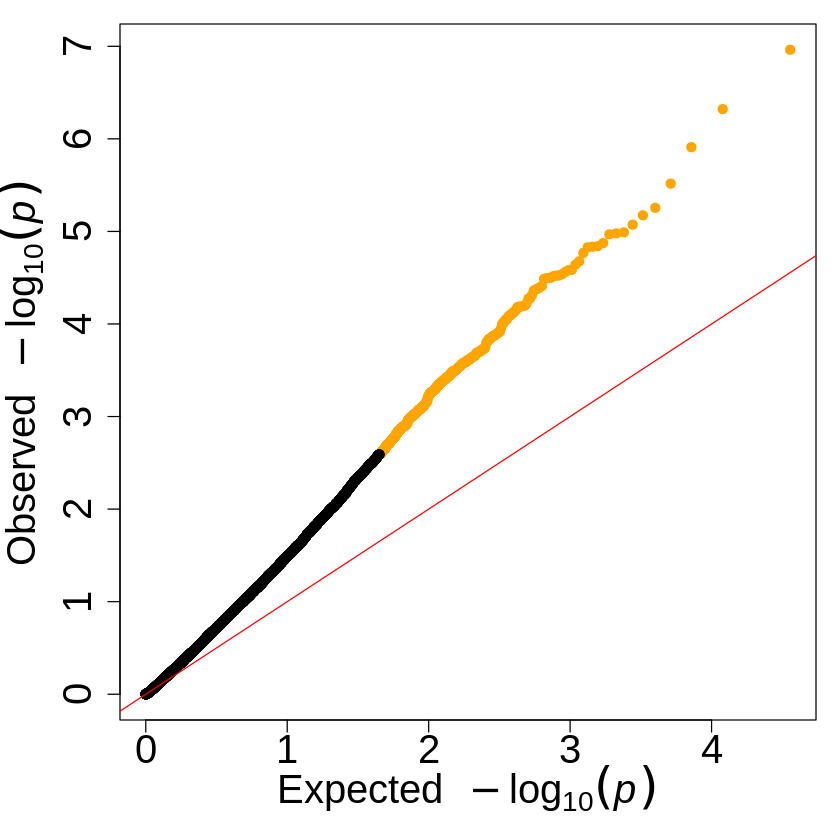

In [115]:
par(mar = c(5,5,1,1))
qq(as.numeric(testRes_envPC1_v2$p),col = ifelse(1:nrow(testRes_envPC1_v2)%in%1:400,"orange","black"),cex.axis = 2,
   cex = 1.5, cex.lab = 2)

In [81]:
envPC1_candidate = testRes_envPC1_v2$PvID[rank(testRes_envPC1_v2$p)<=400]

In [82]:
GODB <- readMappings("/workdir/sh2246/p_panAndOGASR/data/Pv_GOTable.txt",IDsep = ",")
background = intersect(names(GODB),mappingFile[,1])
# background = names(GODB)

tmp=factor(as.integer(background%in%envPC1_candidate))
names(tmp)=background
tgd1=new( "topGOdata", ontology="BP", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
resTopGO.classic=runTest(tgd1, algorithm = "classic", statistic = "Fisher")
resTopGO.weight01=runTest(tgd1, algorithm = "weight01", statistic = "Fisher")
GO_res_table=GenTable(tgd1,Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,orderBy = "Fisher.weight01",ranksOf="Fisher.classic",topNodes=length(resTopGO.classic@score),numChar=100)



Building most specific GOs .....

	( 1051 GO terms found. )


Build GO DAG topology ..........

	( 2530 GO terms and 5201 relations. )


Annotating nodes ...............

	( 6753 genes annotated to the GO terms. )


			 -- Classic Algorithm -- 

		 the algorithm is scoring 598 nontrivial nodes
		 parameters: 
			 test statistic: fisher


			 -- Weight01 Algorithm -- 

		 the algorithm is scoring 598 nontrivial nodes
		 parameters: 
			 test statistic: fisher


	 Level 15:	1 nodes to be scored	(0 eliminated genes)


	 Level 14:	2 nodes to be scored	(0 eliminated genes)


	 Level 13:	4 nodes to be scored	(6 eliminated genes)


	 Level 12:	10 nodes to be scored	(12 eliminated genes)


	 Level 11:	20 nodes to be scored	(55 eliminated genes)


	 Level 10:	38 nodes to be scored	(153 eliminated genes)


	 Level 9:	63 nodes to be scored	(1019 eliminated genes)


	 Level 8:	68 nodes to be scored	(1260 eliminated genes)


	 Level 7:	89 nodes to be scored	(1909 eliminated genes)


	 Level 6:	100

In [86]:
head(GO_res_table[order(GO_res_table$Fisher.classic),],20)

,GO.ID,Term,Annotated,Significant,Expected,Rank in Fisher.classic,Fisher.classic,Fisher.weight01
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
419,GO:0044265,cellular macromolecule catabolic process,147,11,3.64,1,0.00098,1.0000
1,GO:0006413,translational initiation,20,4,0.49,2,0.00128,0.0013
234,GO:0009057,macromolecule catabolic process,177,11,4.38,3,0.00429,1.0000
8,GO:0006511,ubiquitin-dependent protein catabolic process,97,7,2.40,4,0.00993,0.0281
324,GO:0019941,modification-dependent protein catabolic process,97,7,2.40,5,0.00993,1.0000
405,GO:0043632,modification-dependent macromolecule catabolic process,97,7,2.40,6,0.00993,1.0000
2,GO:0019321,pentose metabolic process,7,2,0.17,7,0.01176,0.0118
3,GO:0000723,telomere maintenance,8,2,0.20,8,0.01543,0.0154
4,GO:0016575,histone deacetylation,8,2,0.20,9,0.01543,0.0154


In [87]:
CHGene = read.csv("/workdir/sh2246/p_phyloGWAS/output/TableS5_Top_hits_OGspecific.csv")

In [89]:
length(unique(CHGene$OG))

[1] 757

In [90]:
intersect(unique(CHGene$OG),testRes_envPC1_v2$OG[rank(testRes_envPC1_v2$p)<=400])

[1] "OG0009066" "OG0011858" "OG0021725" "OG0013562" "OG0012126" "OG0001454"
 [7] "OG0009605" "OG0015283" "OG0008699" "OG0018088" "OG0008658" "OG0004353"
[13] "OG0014896" "OG0009030"

In [102]:
paste(mappingFileMerged[mappingFileMerged[,1]%in%intersect(unique(CHGene$OG),testRes_envPC1_v2$OG[rank(testRes_envPC1_v2$p)<=400]),3],collapse = ",")

[1] "Zm00001eb392880_T002,Zm00001eb182090_T001,Zm00001eb067040_T001,Zm00001eb054290_T002,Zm00001eb198320_T002,Zm00001eb144120_T002,Zm00001eb299980_T002,Zm00001eb213630_T001,Zm00001eb319460_T001,Zm00001eb107720_T003,Zm00001eb043100_T003,Zm00001eb332980_T001,Zm00001eb225000_T001,Zm00001eb107750_T002"

In [104]:
library(jsonlite)
envResponsiveGenes = read_json("/workdir/sh2246/p_phyloGWAS_archived/output/candidateGenes/consistentEnvResponsiveGenes.json")


Attaching package: ‘jsonlite’


The following object is masked from ‘package:purrr’:

    flatten




In [108]:
ovlp = intersect(intersect(unique(CHGene$OG),testRes_envPC1_v2$OG[rank(testRes_envPC1_v2$p)<=400]),Reduce(union,envResponsiveGenes[c(1,3)]))

In [109]:
mappingFileMerged[mappingFileMerged[,1]%in%ovlp,3]

[1] "Zm00001eb392880_T002" "Zm00001eb067040_T001" "Zm00001eb144120_T002"
[4] "Zm00001eb213630_T001" "Zm00001eb319460_T001"

In [91]:
source("/workdir/sh2246/p_geneModelEvaluation/src//S00_basicFunction.R")

In [99]:
cont_table(testRes_envPC1_v2$OG[rank(testRes_envPC1_v2$p)<=400],testRes_envPC1_v2$OG,unique(CHGene$OG))

14,386
649,16946


In [9]:
myX = data.table::fread("/workdir/sh2246/p_phyloGWAS/output/functionPredictionPerOG_20250504.txt",data.table = F)
rownames(myX) = myX[,1]
myX = as.matrix(myX[,-1])

In [10]:
subX = myX[,grep("OG0012126",colnames(myX))]
binX = subX
binX[,1:2] = subX[,1:2] < (-1.66)
binX[,c(3,5)] = subX[,c(3,5)] == 0
binX[,4] = subX[,4] > 1.66

In [11]:
pDf = data.frame(envPC1 = envDf[rownames(myX),]$envPC_1,LoF = as.factor(rowSums(binX)>0),
                 subtribe = metadata[rownames(myX),]$subtribe)

In [12]:
subIdx = apply(table(metadata[rownames(myX),]$subtribe,rowSums(binX)>0),1,function(x) sum(x)>20&all(x>3))
subIdx
pDf = pDf[pDf$subtribe %in% names(which(subIdx)),]

Alopecurinae    Andropogoninae     Anthephorinae    Anthistiriinae 
            FALSE              TRUE             FALSE              TRUE 
        Apludinae     Arthraxoninae Arthrostylidiinae    Arundinariinae 
             TRUE             FALSE             FALSE             FALSE 
         Aveninae        Bambusinae     Boivinellinae    Brachypodiinae 
            FALSE             FALSE             FALSE             FALSE 
         Brominae        Cenchrinae     Chionachninae   Chrysopogoninae 
            FALSE             FALSE             FALSE             FALSE 
     Coleanthinae      Dactylidinae   Dichantheliinae       Eleusininae 
            FALSE             FALSE             FALSE             FALSE 
   Eragrostidinae      Germainiinae         Guaduinae         Hordeinae 
            FALSE             FALSE             FALSE             FALSE 
   Hsuehochloinae       Ischaeminae          Loliinae       Melinidinae 
            FALSE             FALSE             FALSE             FALSE 
     Melocanninae         Molininae          Olyrinae       Orcuttiinae 
            FALSE             FALSE             FALSE             FALSE 
         Orininae          Oryzinae         Panicinae        Paspalinae 
            FALSE             FALSE             FALSE             FALSE 
           Poinae    Ratzeburgiinae      Rhytachninae    Rottboelliinae 
            FALSE             FALSE             FALSE             FALSE 
      Saccharinae         Sorghinae      Sporobolinae          Stipinae 
             TRUE             FALSE             FALSE             FALSE 
     Tripogoninae       Tripsacinae     Triraphidinae        Triticinae 
            FALSE             FALSE             FALSE             FALSE 
       Zizaniinae         Zoysiinae 
            FALSE             FALSE

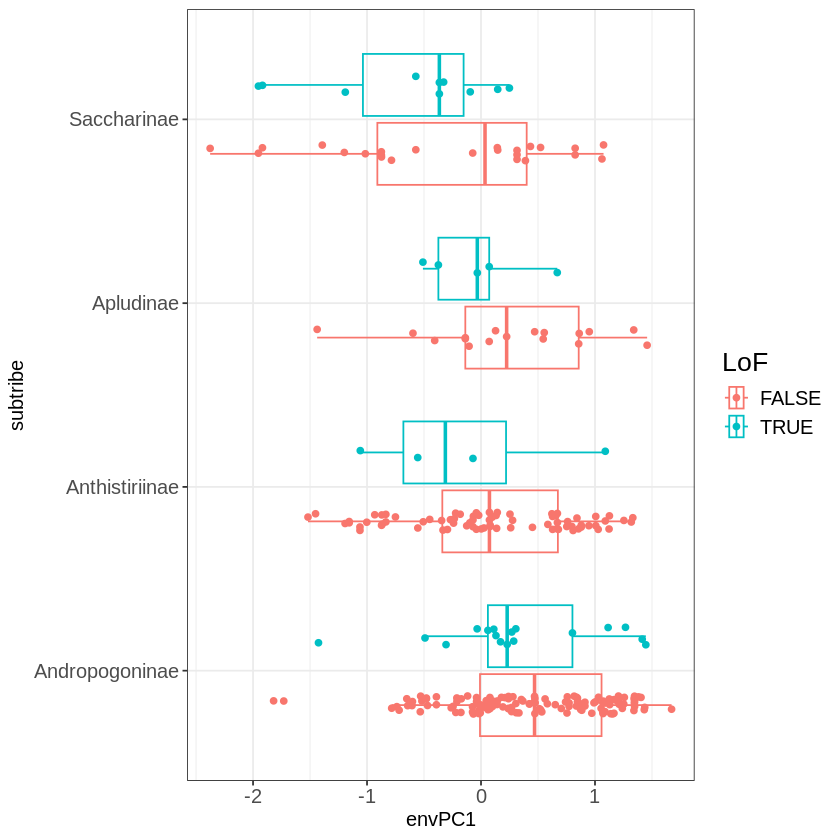

In [15]:
ggplot(pDf,aes(y=subtribe,x=envPC1,col = LoF))+
    geom_boxplot(outlier.shape = NA,fill=NA)+
    geom_jitter(aes(color = LoF),position = position_jitterdodge(jitter.width = 0.2, dodge.width = 0.75))+
    theme_bw()+
    theme(axis.text.y = element_text(size = 12),axis.text.x = element_text(size = 12),
          axis.title.y = element_text(size = 12),axis.title.x = element_text(size = 12),
          legend.title = element_text(size = 16),legend.text = element_text(size = 12))

In [133]:
sum(table(metadata$subtribe) > 20)

[1] 10

In [288]:
getParallelism = function(OG,myX,envDf,trait,metadata){
    subX = myX[,grep(OG,colnames(myX))]
    binX = subX
    binX[,1:2] = subX[,1:2] < (-1.645)
    binX[,c(3,5)] = subX[,c(3,5)] == 0
    binX[,4] = subX[,4] > 1.645

    pDf = data.frame(trait = envDf[rownames(myX),grep(trait,colnames(envDf))],LoF = as.factor(rowSums(binX)>0),
                     subtribe = metadata[rownames(myX),]$subtribe)

    subIdx = apply(table(metadata[rownames(myX),]$subtribe,rowSums(binX)>0),1,function(x) sum(x)>20&all(x>3))
    numPolySubTribe = sum(subIdx)
    if (numPolySubTribe<1) return(c(NA,NA,NA,numPolySubTribe))
    else {
        pDf = pDf[pDf$subtribe %in% names(which(subIdx)),]
        d = c()
        for (i in unique(pDf$subtribe)){
            subDf = subset(pDf,subtribe %in% i)
            d = c(d,mean(subDf[subDf[,2]==FALSE,1])-mean(subDf[subDf[,2]==TRUE,1]))
        }
#         cv = sqrt(var(d))/abs(mean(d))
        out = c(sum(d)/10,sum(d>0)/10,sum(d<0)/10,numPolySubTribe)
        return(out)
    }
}



In [289]:
plStat = t(simplify2array(mclapply(testRes_envPC1_v2$OG,function(x) getParallelism(x,myX,envDf,"envPC_1$",metadata),mc.cores = 20)))

plStat = as.data.frame(plStat)

plStat$p = testRes_envPC1_v2$p
plStat$group = with(testRes_envPC1_v2, ifelse(p > 0.001, "Non-significant",
                  ifelse(plStat[,1] > 0, "Significant Positive", "Significant Negative")))
plStat = na.omit(plStat)
plStat$plScore = plStat$V2
plStat$plScore[plStat$V1<0] = plStat$V3[plStat$V1<0]

Picking joint bandwidth of 0.024



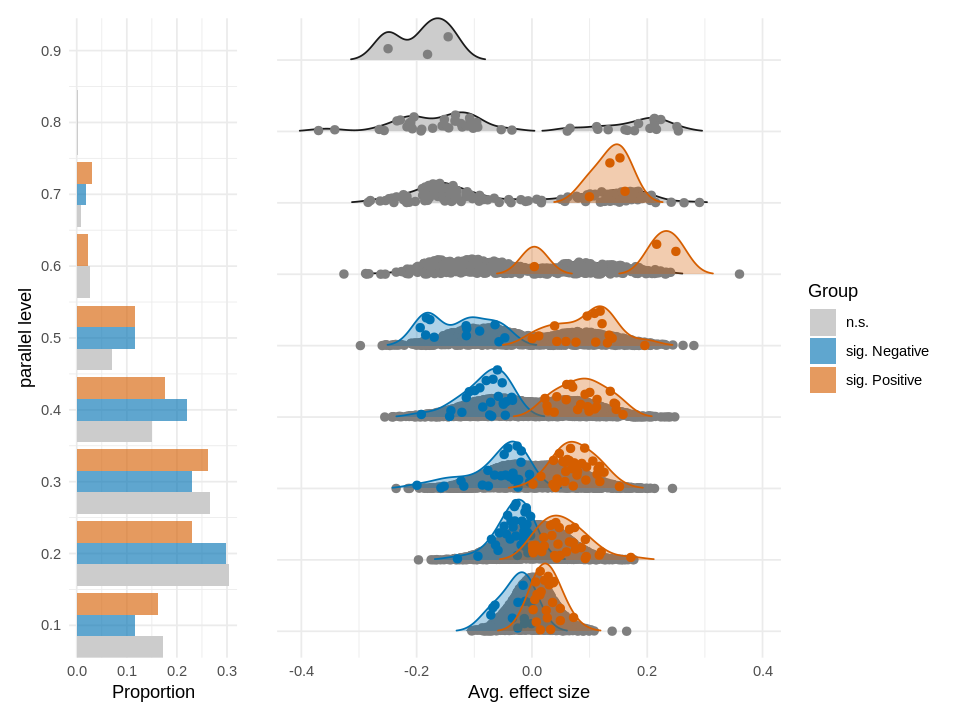

In [292]:
p1 = ggplot(plStat, aes(x = V1, y = as.factor(plScore), color = group, point_color = group, fill = group)) +
  geom_density_ridges(
    jittered_points = TRUE, scale = .95, rel_min_height = .01,
    point_size = 2) +
  scale_y_discrete(expand = c(0.045, 0.01),guide = "none") +
  scale_x_continuous(expand = c(0, 0)) +
  scale_fill_manual(values = c("grey80", "#0072B250","#D55E0050"), labels = c("n.s.","sig. Negative", "sig. Positive")) +
  scale_color_manual(values = c("grey10", "#0072B2","#D55E00"), guide = "none") +
  scale_discrete_manual("point_color", values = c("grey50", "#0072B2","#D55E00"), guide = "none") +
  coord_cartesian(clip = "off") +
  guides(fill = guide_legend(
    override.aes = list(
      fill = c("grey80", "#0072B2A0","#D55E00A0"),
      color = NA, point_color = NA)
    )
  )+ 
  labs(x = "Avg. effect size", y = "", fill = "Group")+
  theme_minimal()
p2 = ggplot(plStat, aes(x = plScore, fill = group)) +
  geom_bar(position = "dodge",aes(y = after_stat(prop))) +
  scale_fill_manual(values = c("grey80", "#0072B2A0","#D55E00A0")) +
  coord_flip()+
  scale_x_continuous(breaks = seq(0.1,.9,0.1),expand = c(0,0))+
  labs(x = "parallel level", y = "Proportion", fill = "Group") +
  theme_minimal()+
  theme(legend.position = "none")
options(repr.plot.width=8, repr.plot.height=6)
p2+p1 + plot_layout(widths = c(1, 3))

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


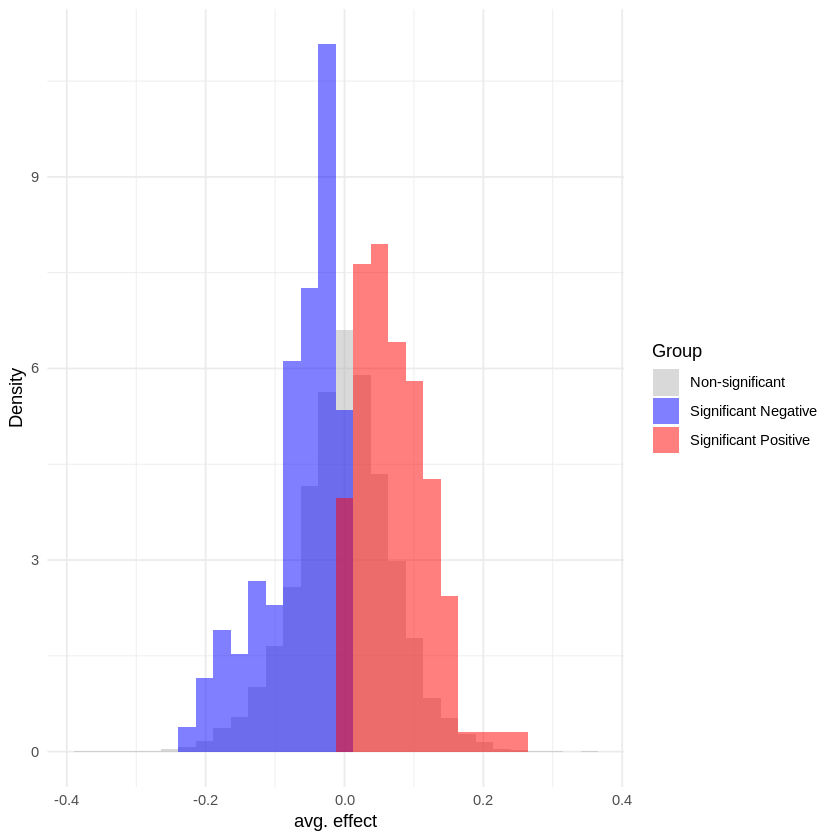

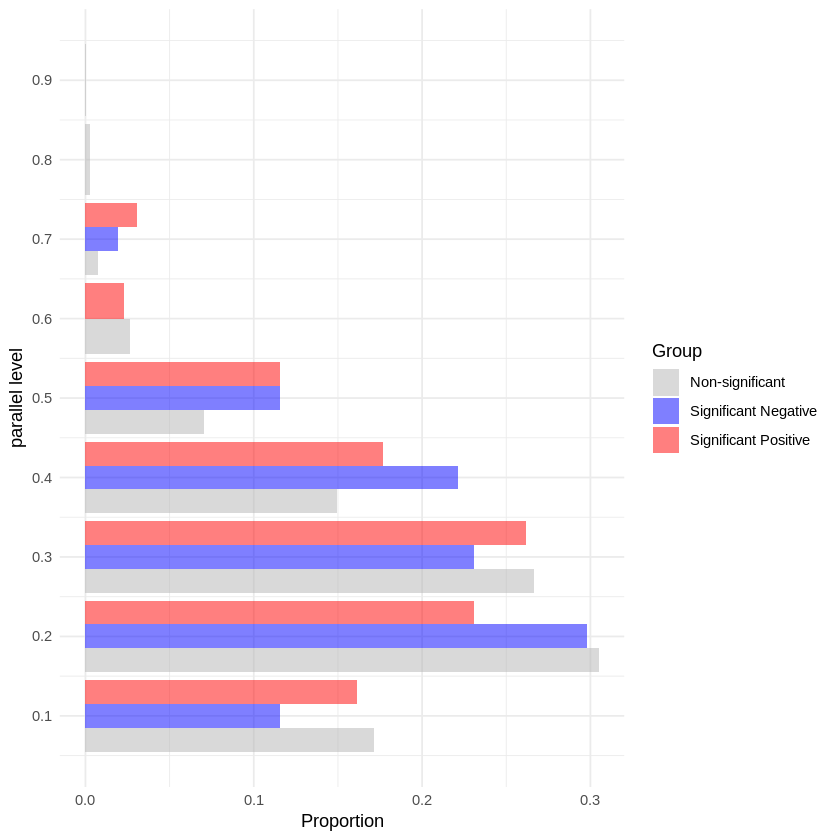

In [245]:
# Plot overlapping density
ggplot(plStat, aes(x = V1, fill = group)) +
  geom_histogram(aes(y=after_stat(density)),alpha = .5,position = "identity") +
  scale_fill_manual(values = c("grey70", "blue","red")) +
  labs(x = "avg. effect", y = "Density", fill = "Group") +
  theme_minimal()

ggplot(plStat, aes(x = plScore, fill = group)) +
  geom_bar(alpha = 0.5,position = "dodge",aes(y = after_stat(prop))) +
  scale_fill_manual(values = c("grey70", "blue", "red" )) +
  coord_flip()+
  scale_x_continuous(breaks = seq(0,1,0.1))+
  labs(x = "parallel level", y = "Proportion", fill = "Group") +
  theme_minimal()

In [31]:
d = c()
for (i in unique(pDf$subtribe)){
    subDf = subset(pDf,subtribe %in% i)
    d = c(d,mean(subDf[subDf[,2]==FALSE,1])-mean(subDf[subDf[,2]==TRUE,1]))
}
sqrt(var(d))/mean(d)

[1] 0.3642312

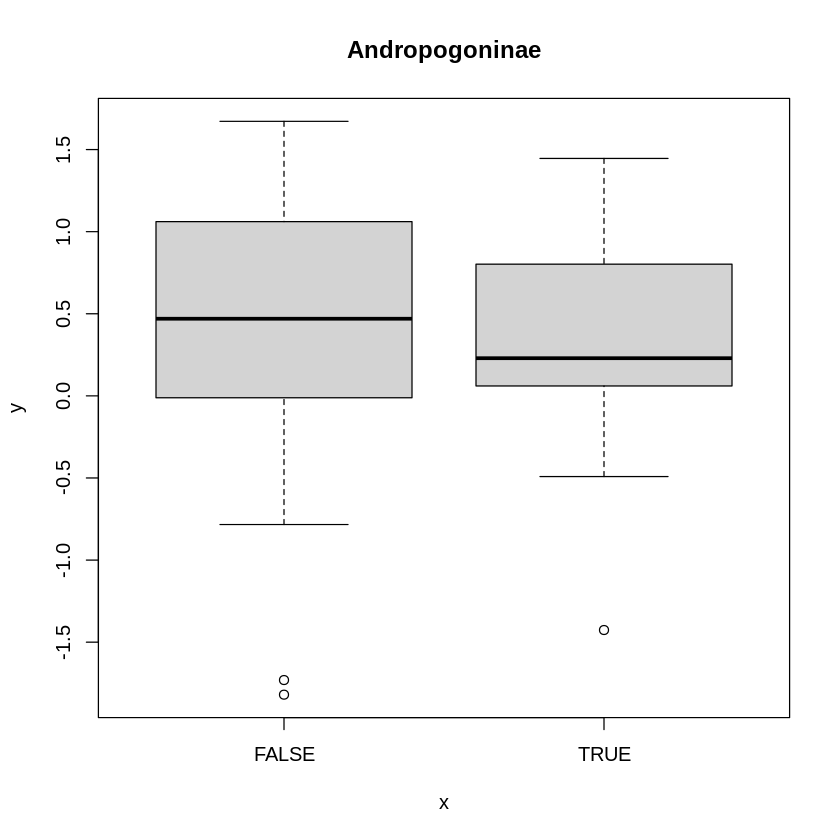

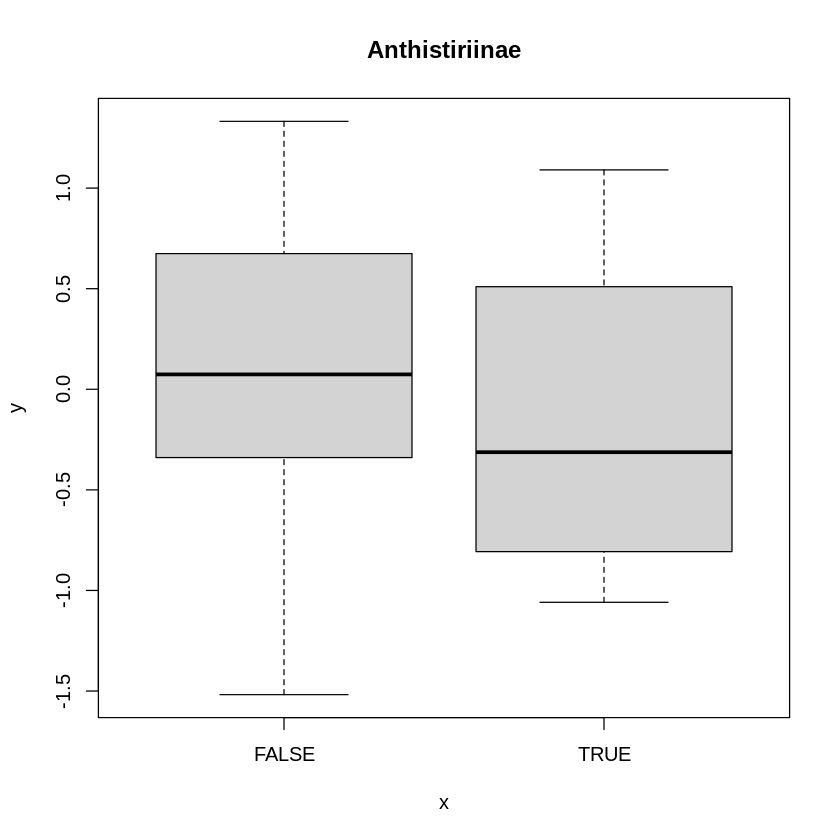

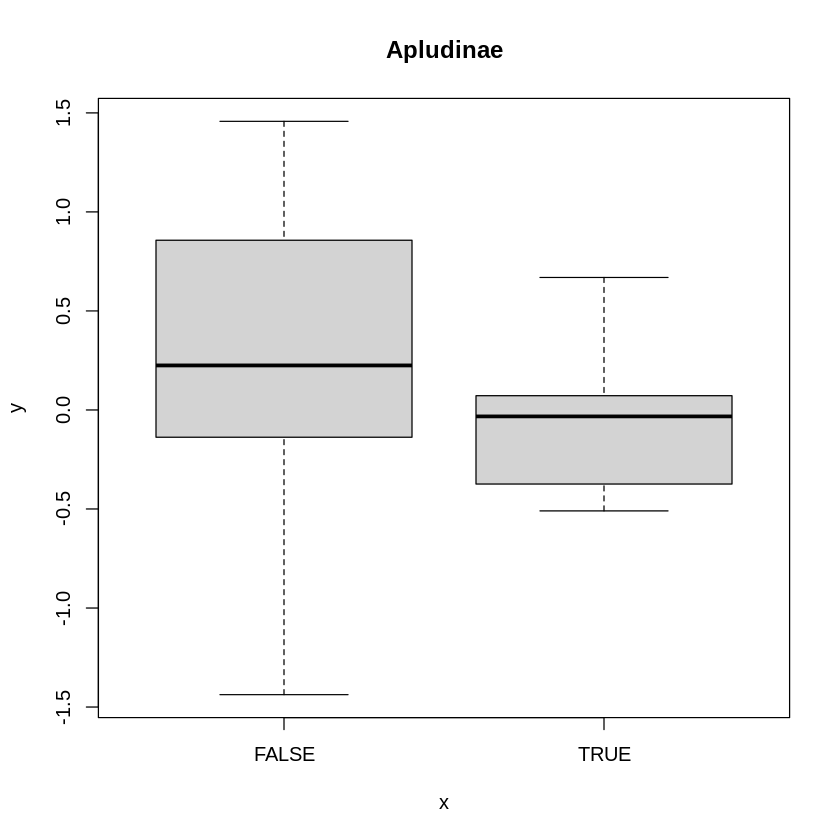

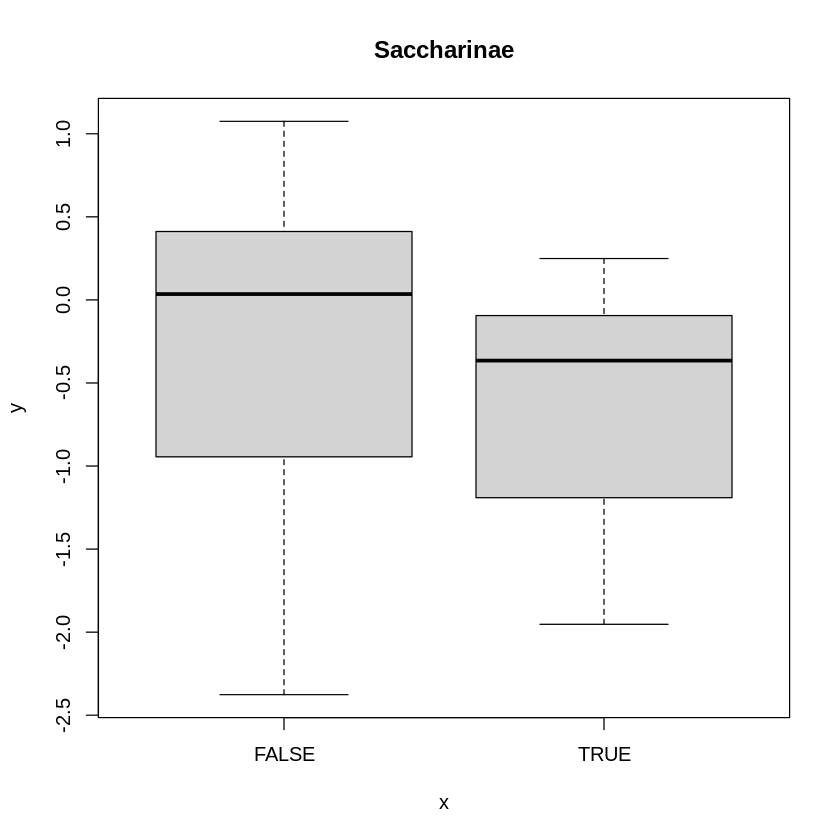

In [186]:
for(i in names(which(table(metadata$subtribe)>20))){
    idx = metadata[rownames(myX),]$subtribe%in%i
    lof = as.factor(rowSums(binX)[idx]>0)
    if(length(table(lof))<2|any(table(lof)<3)) next
    plot(lof,envDf[rownames(myX),][idx,]$envPC_1,main = i)
}


In [187]:
table(metadata[rownames(myX),]$subtribe,rowSums(binX)>0)

                   
                    FALSE TRUE
  Alopecurinae          2    0
  Andropogoninae      132   17
  Anthephorinae         2    0
  Anthistiriinae       75    4
  Apludinae            17    5
  Arthraxoninae         7    3
  Arthrostylidiinae     1    0
  Arundinariinae       10    0
  Aveninae             24    0
  Bambusinae            4    0
  Boivinellinae         6    2
  Brachypodiinae        0    7
  Brominae              1    1
  Cenchrinae            4    8
  Chionachninae         2    0
  Chrysopogoninae      15    1
  Coleanthinae          1    0
  Dactylidinae          2    0
  Dichantheliinae       1    0
  Eleusininae          11    1
  Eragrostidinae        4    0
  Germainiinae          5    0
  Guaduinae             2    0
  Hordeinae             4   10
  Hsuehochloinae        1    0
  Ischaeminae          22    1
  Loliinae              5    0
  Melinidinae           3    0
  Melocanninae          2    0
  Molininae             4    0
  Olyrinae         

In [166]:
rownames(metadata)

[1] "10wheat_assembly_jagger"              
  [2] "10wheat_assembly_lancer"              
  [3] "10wheat_assembly_stanley"             
  [4] "A17"                                  
  [5] "A42"                                  
  [6] "AANG_UGA4"                            
  [7] "Ab-Traiperm_572-DRAFT-PanAnd-1.0"     
  [8] "Ac-Pasquet1232-DRAFT-PanAnd-1.0"      
  [9] "Adlay_draft_genome_1.0"               
 [10] "Aegilops_cylindrica"                  
 [11] "aegilops_longissima_6782_assembly"    
 [12] "Aegilops_markgrafii"                  
 [13] "aegilops_sharonensis_1644_assembly"   
 [14] "aegilops_speltoides_cv_tivon"         
 [15] "Aegilops_triuncialis"                 
 [16] "Aet_v5.0"                             
 [17] "Ag-CAM1351-DRAFT-PanAnd-1.0"          
 [18] "Alloteropsis_cimicina"                
 [19] "Alomy_genome_v1"                      
 [20] "AN20T004"                             
 [21] "AN20T007"                             
 [22] "AN20T009"                             
 [23] "AN20T010"                             
 [24] "AN20T011"                             
 [25] "AN20T012"                             
 [26] "AN20T014"                             
 [27] "AN20T015"                             
 [28] "AN20T018"                             
 [29] "AN20T019"                             
 [30] "AN20T020"                             
 [31] "AN20T021"                             
 [32] "AN20T022"                             
 [33] "AN20T023"                             
 [34] "AN20T024"                             
 [35] "AN20T025"                             
 [36] "AN20T026"                             
 [37] "AN20T035"                             
 [38] "AN20T036"                             
 [39] "AN20T039"                             
 [40] "AN20T041"                             
 [41] "AN20T168"                             
 [42] "AN20T169"                             
 [43] "AN20T170"                             
 [44] "AN20T172"                             
 [45] "AN20T174"                             
 [46] "AN20T175"                             
 [47] "AN20T176"                             
 [48] "AN20T177"                             
 [49] "AN20T179"                             
 [50] "AN20T183"                             
 [51] "AN20T184"                             
 [52] "AN20T185"                             
 [53] "AN20T190"                             
 [54] "AN20T191"                             
 [55] "AN20T192"                             
 [56] "AN20T193"                             
 [57] "AN20T195"                             
 [58] "AN20T196"                             
 [59] "AN20TSCR000199"                       
 [60] "AN20TSCR000212"                       
 [61] "AN20TSCR000218"                       
 [62] "AN21TNTL0074"                         
 [63] "AN21TNTL0075"                         
 [64] "AN21TNTL0076"                         
 [65] "AN21TNTL0077"                         
 [66] "AN21TNTL0079"                         
 [67] "AN21TNTL0083"                         
 [68] "AN21TNTL0085"                         
 [69] "AN21TNTL0087"                         
 [70] "AN21TNTL0089"                         
 [71] "AN21TNTL0090"                         
 [72] "AN21TNTL0091"                         
 [73] "AN21TNTL0092"                         
 [74] "AN21TNTL0093"                         
 [75] "AN21TNTL0094"                         
 [76] "AN21TNTL0095"                         
 [77] "AN21TNTL0096"                         
 [78] "AN21TNTL0097"                         
 [79] "AN21TNTL0098"                         
 [80] "AN21TNTL0099"                         
 [81] "AN21TNTL0100"                         
 [82] "AN21TNTL0101"                         
 [83] "AN21TNTL0102"                         
 [84] "AN21TNTL0104"                         
 [85] "AN21TNTL0105"                         
 [86] "AN21TNTL0106"                         
 [87] "AN21TNTL0107"                         


In [4]:
sum(testRes_envPC1_v2$partialCoeff_plantCad==0)

[1] 0